# CEMA FGA Metrics

## Imports and Parameters

In [8]:
#Imports
import chipwhisperer as cw
import sys
from Crypto.Cipher import AES
from chipwhisperer.common.utils import util
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import trange
from tqdm import tnrange
from scipy.stats import ttest_ind
# from scipy.stats import _moment
import scipy

import sys
sys.path.insert(1,'../../SCApeGoat-main/')

from WPI_SCA_LIBRARY.CWScope import *
from WPI_SCA_LIBRARY.LeakageModels import *
%run "../function/CEMA_functions.ipynb"
%run "../function/AES_model.ipynb"
#Global Variables
N = 1000000
no_samples =10400
clk_spd = 5E6
vcc_in = 1.0

In [2]:
#get keys experiments
emsca = FileParent("CEMA",".\\",True)
ptc_5k = emsca.get_experiment('pt_keys_5k_rambus')
ptc_5x10k = emsca.get_experiment('pt_keys_5kx10_rambus')

In [481]:
emsca.experiments

{'testing_cema_grid': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5bd278e0>,
 'pt_keys': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a50200df0>,
 'testing_cema_grid_32_32': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5ee14ee0>,
 'testing_cema_grid_10_10': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5ee15210>,
 'testing_cema_grid_10_10_45k': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5ee16dd0>,
 'testing_cema_grid_32_32_nofilter': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5ee15b40>,
 'testing_cema_grid_10_10_1_25mm': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5c59a4a0>,
 'testing_cema_grid_50_50_1_25mm': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5afef550>,
 'testing_cema_grid_10_10_1_25mm_10k': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5ac55960>,
 'testing_cema_grid_10_10_1_25mm_10k-1': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5de1b4c0>,
 'testing_cema_grid_10_10_1_25mm_10k20250124_1428': <WPI_SCA_LIBRARY.FileFormat.Experiment at 0x24a5de1a9b0>,
 

In [3]:
# test = emsca.get_experiment('fpga_cema_1_2mm_10000_5x5_40x_impl_1_avg')
# test_t = emsca.add_experiment('fpga_cema_1_2mm_10000_5x5_40x_impl_1_avg_t')

#impl_1 actual implementation averaged 'fpga_cema_1_2mm_1000_5x5_40x_impl_1'
#default impl --> 'fpga_cema_1_2mm_10000_10x10_40x_default_avg'
#impl_3 --> 'fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg'
impl_1_f = emsca.get_experiment('fpga_cema_1_2mm_10000_5x5_40x_impl_1_avg')
impl_1_a = emsca.get_experiment('fpga_cema_1_2mm_10000_5x5_40x_impl_1_avg_reduced')
impl_1_t =emsca.get_experiment('fpga_cema_1_2mm_10000_5x5_40x_impl_1_avg_t')

impl_d_f =emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_default_avg')
impl_d_a =emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_default_avg_reduced')
impl_d_t =emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_default_avg_reduced_t')

impl_3_f =emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg')
impl_3_a =emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced')
impl_3_t =emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced_t')

uc_f =emsca.get_experiment('uc_cema_1_2mm_10000_10x10_30x_avg')
uc_a =emsca.get_experiment('uc_cema_1_2mm_10000_10x10_30x_avg_a')
uc_t =emsca.get_experiment('uc_cema_1_2mm_10000_10x10_30x_avg_t')



# test_avg = emsca.get_experiment('fpga_cema_1_2mm_10000_5x5ave_40x_impl_1_avg')
# test_t = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced_t')

In [532]:
#generate matrix for gaussian mixture model 
num_trace_to_save = 100
# len(traces)
# t5 = []
for i in range(11):
    for j in range(11):
        print(f"{i},{j}")
        t0 = uc_t.get_dataset( f"random_{i}_{j}").read_data(0,num_trace_to_save)
        if (i ==0 )&( j==0):
              t5 = t0[:,5613:6063]
        else :
            t5 = np.concatenate((t5,t0[:,5613:6063]),axis=0)
np.savetxt('data_100_121_uc.csv', t5, delimiter=',') 

0,0
0,1
0,2
0,3
0,4
0,5
0,6
0,7
0,8
0,9
0,10
1,0
1,1
1,2
1,3
1,4
1,5
1,6
1,7
1,8
1,9
1,10
2,0
2,1
2,2
2,3
2,4
2,5
2,6
2,7
2,8
2,9
2,10
3,0
3,1
3,2
3,3
3,4
3,5
3,6
3,7
3,8
3,9
3,10
4,0
4,1
4,2
4,3
4,4
4,5
4,6
4,7
4,8
4,9
4,10
5,0
5,1
5,2
5,3
5,4
5,5
5,6
5,7
5,8
5,9
5,10
6,0
6,1
6,2
6,3
6,4
6,5
6,6
6,7
6,8
6,9
6,10
7,0
7,1
7,2
7,3
7,4
7,5
7,6
7,7
7,8
7,9
7,10
8,0
8,1
8,2
8,3
8,4
8,5
8,6
8,7
8,8
8,9
8,10
9,0
9,1
9,2
9,3
9,4
9,5
9,6
9,7
9,8
9,9
9,10
10,0
10,1
10,2
10,3
10,4
10,5
10,6
10,7
10,8
10,9
10,10


In [531]:
len(t0[:,5613:6063][0])

450

In [469]:
# test.name
print(len(impl_d_t.get_dataset("random_0_0").read_all()))

impl_1_t.dataset

1000


{'fixed_0_0': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c6ad0>,
 'random_0_0': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c6950>,
 'fixed_0_1': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c68c0>,
 'random_0_1': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c6c20>,
 'fixed_0_2': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c6c50>,
 'random_0_2': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c7b80>,
 'fixed_0_3': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c7430>,
 'random_0_3': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c7fd0>,
 'fixed_0_4': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c7730>,
 'random_0_4': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c7670>,
 'fixed_0_5': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c6c80>,
 'random_0_5': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c7b50>,
 'fixed_0_6': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c75b0>,
 'random_0_6': <WPI_SCA_LIBRARY.FileFormat.Dataset at 0x24a592c74f0>,
 'fixed_0_7': <WPI_SCA_LIBR

In [90]:
test_to_avg(impl_1_f, impl_1_a)


  0%|          | 0/11 [00:00<?, ?it/s]

Processing grid position (0, 0)



  9%|▉         | 1/11 [00:00<00:08,  1.14it/s]

Processing grid position (0, 1)



 18%|█▊        | 2/11 [00:01<00:08,  1.12it/s]

...


 82%|████████▏ | 9/11 [00:08<00:01,  1.10it/s]

Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:08<00:00,  1.11it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:09<00:00,  1.11it/s]


In [88]:
test_to_downsample(impl_d_f,impl_d_t)


  0%|          | 0/11 [00:00<?, ?it/s]

Processing grid position (0, 0)



  9%|▉         | 1/11 [00:01<00:11,  1.15s/it]

Processing grid position (0, 1)



 18%|█▊        | 2/11 [00:02<00:10,  1.19s/it]

...


 82%|████████▏ | 9/11 [00:11<00:02,  1.23s/it]

Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:12<00:01,  1.20s/it]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:13<00:00,  1.22s/it]


In [10]:
def test_to_randomsample(test, test_avg, n_samples=30, grid_size=11):

    for i in range(grid_size):
        for j in trange(grid_size):
            print(f"Processing grid position ({i}, {j})")

            # Retrieve traces for the current grid position
            rand = test.get_dataset(f"random_{i}_{j}").read_all()
            fix = test.get_dataset(f"fixed_{i}_{j}").read_all()
            
            # Randomly sample exactly n_samples traces
            fix_idx = np.random.choice(fix.shape[0], size=n_samples, replace=False)
            rand_idx = np.random.choice(rand.shape[0], size=n_samples, replace=False)

            f = fix[fix_idx]
            r = rand[rand_idx]
            
            test_avg.add_dataset(f"fixed_{i}_{j}", f, datatype="float32")
            test_avg.add_dataset(f"random_{i}_{j}", r, datatype="float32")

In [21]:
# uc_200_t = emsca.add_experiment('uc_cema_1_2mm_10000_10x10_30x_avg_t_200')


In [22]:
test_to_randomsample(uc_t, uc_100_t, n_samples=100, grid_size=11)


  0%|          | 0/11 [00:00<?, ?it/s]

Processing grid position (0, 0)



  9%|▉         | 1/11 [00:01<00:14,  1.42s/it]

Processing grid position (0, 1)



 18%|█▊        | 2/11 [00:03<00:13,  1.52s/it]

...


 82%|████████▏ | 9/11 [00:12<00:02,  1.36s/it]

Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:13<00:01,  1.34s/it]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:14<00:00,  1.36s/it]


## Metrics

In [29]:
N_traces = 1000
n_steps = 10
rotation_n =3
target_byte = 13
rnd = 6
model_cpa =2
MI_type="HD"#"HD"
config= "impl_1"



Calculating T-Test: 100%|██████████| 100/100 [00:00<00:00, 987.33it/s]


Calculating T-Test: 100%|██████████| 100/100 [00:00<00:00, 847.14it/s]


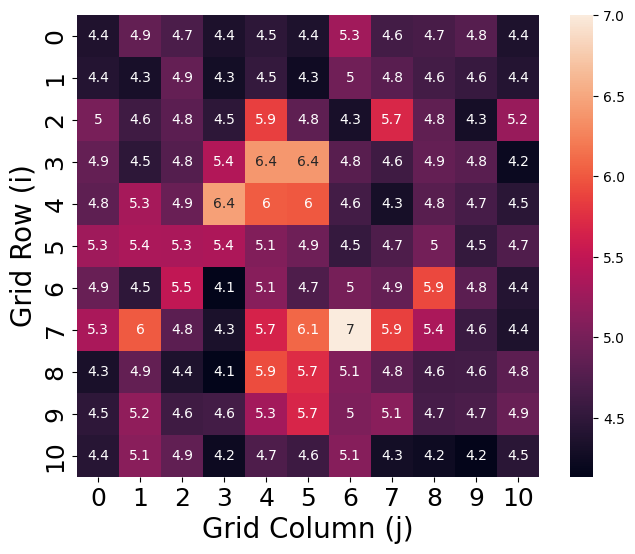

In [23]:
#computes TVLA and plots in a heatmap
# plt.ioff()
config= "impl_d"

t,fig = plot_t_statistic_heatmap(uc_100_t, grid_size=10+1,rotation_n=3, fntsz=18)

# save_mat(t,f"final_data//{config}_t_heatmap.mat")

# # plt.ion()


# fig.savefig(f"final_data//{config}_t_heatmap.png",format="png",bbox_inches="tight")

In [24]:
save_mat(t,f"final_data//uc_100_t_heatmap.mat")


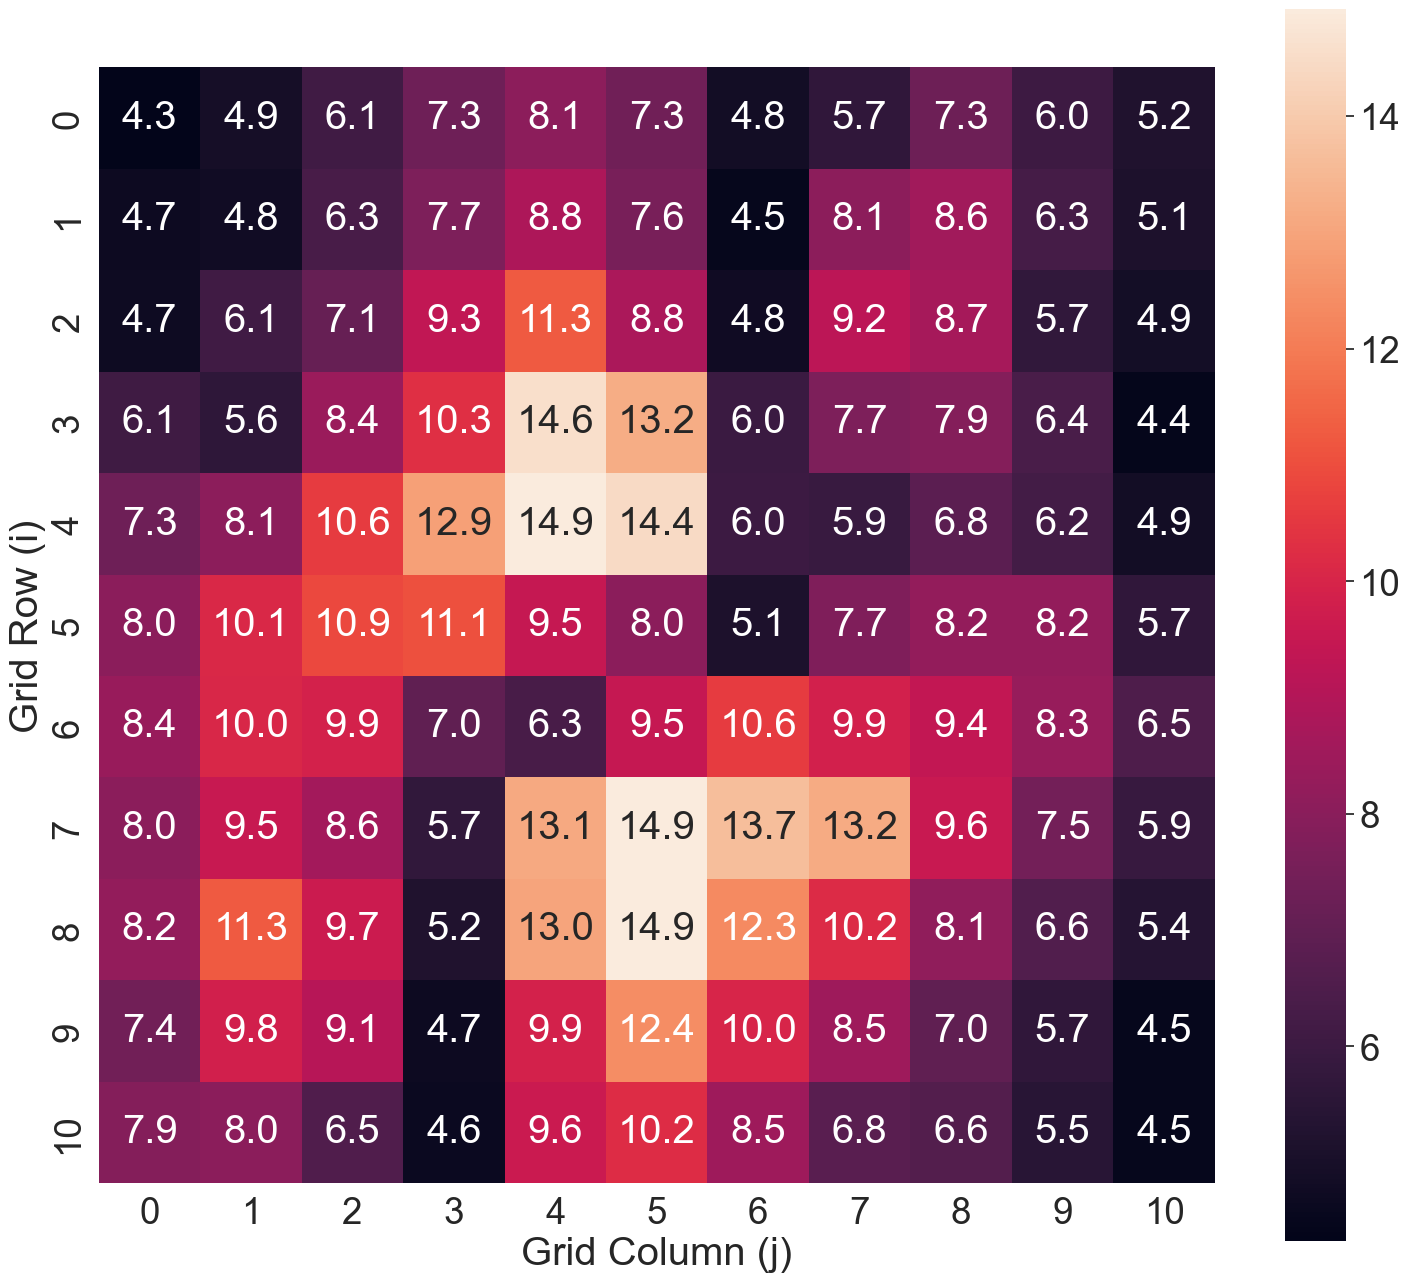

In [36]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
import numpy as np
sns.set_theme()  # or sns.set()
config= "uc"
sns.set_context("notebook", font_scale=2.4)
data = loadmat(f"final_data//{config}_t_heatmap.mat")
MI = data['matrix']
# 3:49
plt.figure(figsize=(18, 16))
# sns.heatmap(MI, annot=True, fmt=".2f", cbar=True, square=True)
ax = sns.heatmap(MI, annot=True, fmt=".1f", cbar=True, square=True)
# --- Access the colorbar ---
# cbar = ax.collections[0].colorbar
# ax.collections[0].set_clim(0.0, 0.41)
# # --- 2. Set ticks manually ---
# ticks = np.linspace(0.0, 0.4, 5)   # 7 ticks from 0 to 3
# cbar.set_ticks(ticks)
# --- 3. Format tick labels ---
# cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.xlabel("Grid Column (j)")
plt.ylabel("Grid Row (i)")
fig= plt.gcf()
plt.show()

 18%|█▊        | 2/11 [00:00<00:00, 14.03it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)



 36%|███▋      | 4/11 [00:00<00:00, 13.42it/s]

Processing grid position (0, 3)
Processing grid position (0, 4)
Processing grid position (0, 5)


 73%|███████▎  | 8/11 [00:00<00:00, 13.39it/s]

...


 73%|███████▎  | 8/11 [00:00<00:00, 13.96it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 13.19it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 13.56it/s]


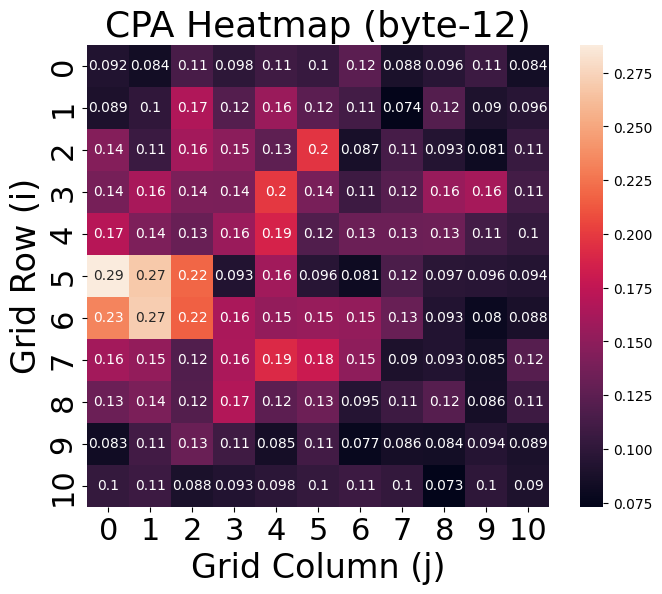

In [445]:
CEMA,fig = plot_CEMA_heatmap_models(impl_1_a,ptc_5k,N_traces,grid_size=n_steps+1,rotation_n=rotation_n,lower_b=35, model =model_cpa, r1=rnd, r2=rnd+1,target_byte=12)


 18%|█▊        | 2/11 [00:00<00:00, 14.24it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)



 36%|███▋      | 4/11 [00:00<00:00, 13.14it/s]

Processing grid position (0, 3)
Processing grid position (0, 4)
Processing grid position (0, 5)


 73%|███████▎  | 8/11 [00:00<00:00, 14.47it/s]

...


 73%|███████▎  | 8/11 [00:00<00:00, 11.32it/s]

Processing grid position (10, 7)
Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 11.37it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 11.71it/s]


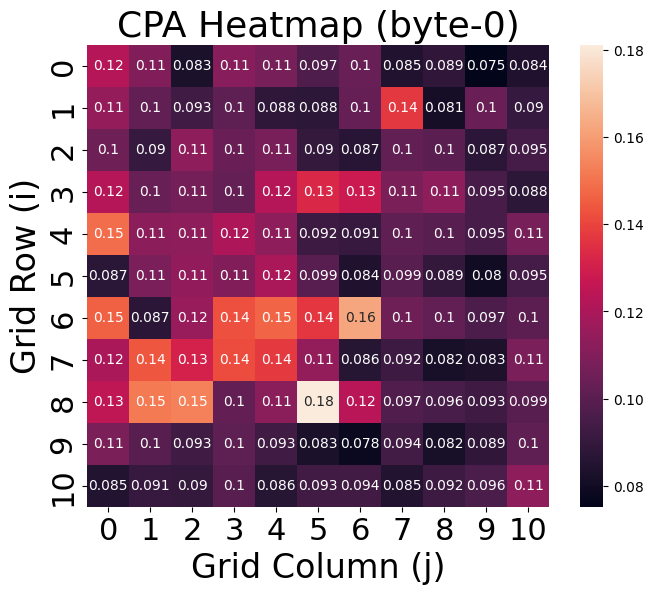

  9%|▉         | 1/11 [00:00<00:01,  9.19it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)


 27%|██▋       | 3/11 [00:00<00:00,  9.36it/s]

Processing grid position (0, 2)
Processing grid position (0, 3)
Processing grid position (0, 4)


 64%|██████▎   | 7/11 [00:00<00:00, 11.84it/s]

...

Processing grid position (10, 6)
Processing grid position (10, 7)



 73%|███████▎  | 8/11 [00:00<00:00, 15.86it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)


100%|██████████| 11/11 [00:00<00:00, 15.65it/s]

Processing grid position (10, 10)


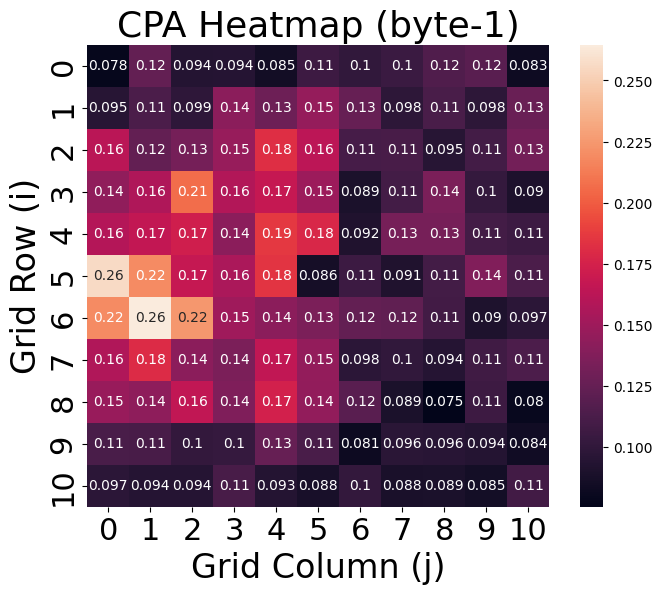

 18%|█▊        | 2/11 [00:00<00:00, 15.99it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 15.21it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


100%|██████████| 11/11 [00:00<00:00, 15.95it/s]


...

Processing grid position (10, 0)
Processing grid position (10, 1)
Processing grid position (10, 2)
Processing grid position (10, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 16.71it/s]

Processing grid position (10, 4)
Processing grid position (10, 5)
Processing grid position (10, 6)
Processing grid position (10, 7)


100%|██████████| 11/11 [00:00<00:00, 16.39it/s]


Processing grid position (10, 8)
Processing grid position (10, 9)
Processing grid position (10, 10)


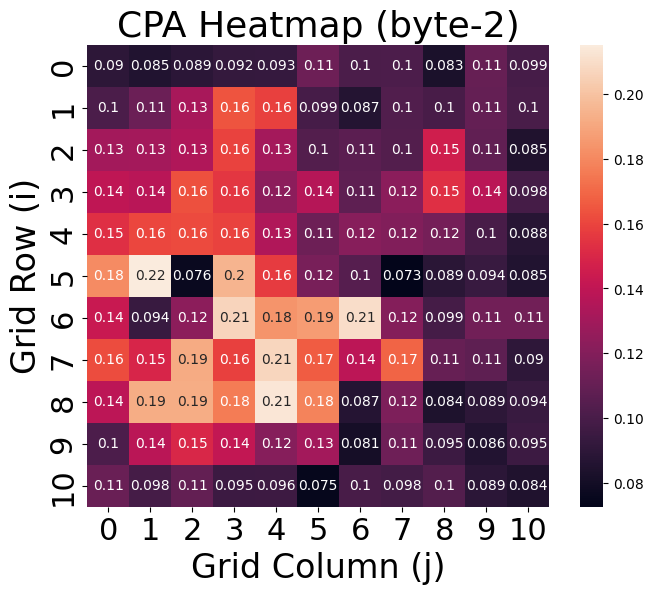

 18%|█▊        | 2/11 [00:00<00:00, 15.89it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 14.78it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)


 91%|█████████ | 10/11 [00:00<00:00, 15.70it/s]

...


 73%|███████▎  | 8/11 [00:00<00:00, 16.44it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 15.36it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 15.72it/s]


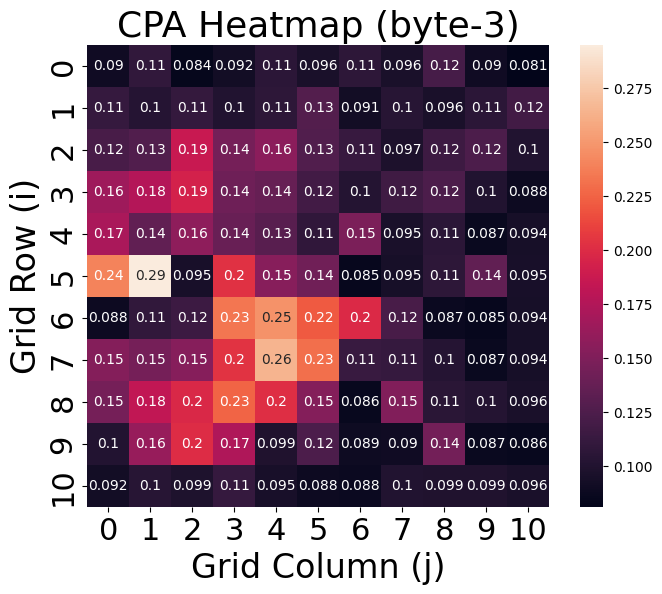

 18%|█▊        | 2/11 [00:00<00:00, 15.95it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 17.21it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


 91%|█████████ | 10/11 [00:00<00:00, 16.01it/s]

...

Processing grid position (10, 5)
Processing grid position (10, 6)
Processing grid position (10, 7)



 73%|███████▎  | 8/11 [00:00<00:00, 15.96it/s]

Processing grid position (10, 8)


100%|██████████| 11/11 [00:00<00:00, 15.52it/s]

Processing grid position (10, 9)
Processing grid position (10, 10)


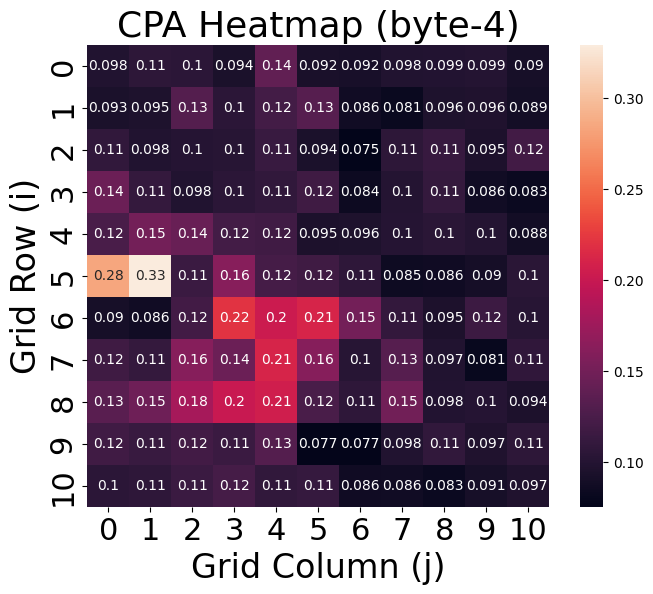

 18%|█▊        | 2/11 [00:00<00:00, 16.12it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 17.17it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


100%|██████████| 11/11 [00:00<00:00, 16.89it/s]


...


 73%|███████▎  | 8/11 [00:00<00:00, 16.33it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 16.08it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 16.24it/s]


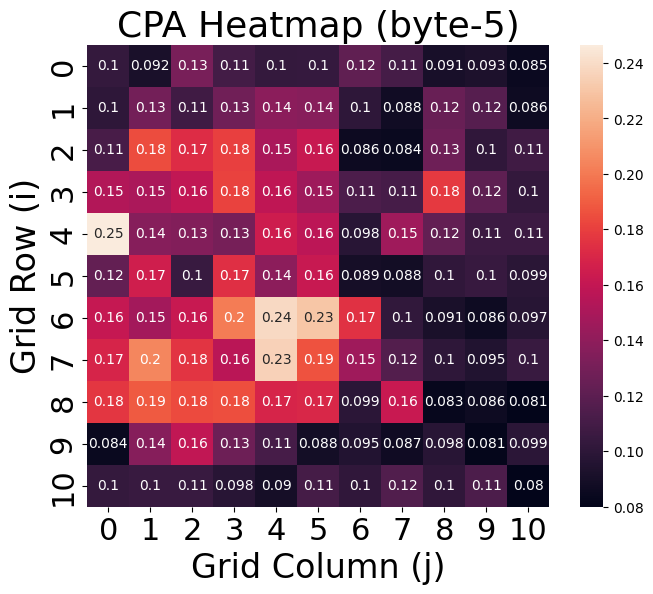

 18%|█▊        | 2/11 [00:00<00:00, 15.60it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 16.06it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


100%|██████████| 11/11 [00:00<00:00, 16.11it/s]


...

Processing grid position (10, 6)
Processing grid position (10, 7)



 73%|███████▎  | 8/11 [00:00<00:00, 16.45it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)


100%|██████████| 11/11 [00:00<00:00, 16.47it/s]

Processing grid position (10, 10)


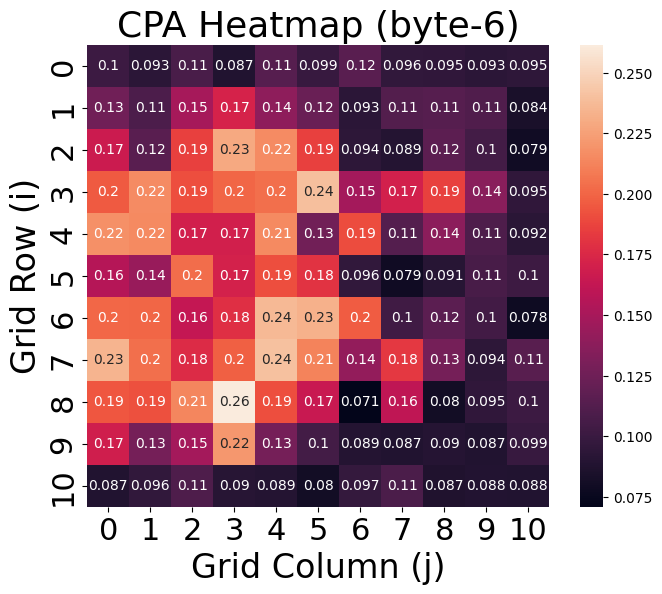

 18%|█▊        | 2/11 [00:00<00:00, 14.08it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 16.20it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


 91%|█████████ | 10/11 [00:00<00:00, 16.17it/s]

...

 55%|█████▍    | 6/11 [00:00<00:00, 16.33it/s]

Processing grid position (10, 4)
Processing grid position (10, 5)
Processing grid position (10, 6)
Processing grid position (10, 7)


 91%|█████████ | 10/11 [00:00<00:00, 16.48it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)
Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 16.48it/s]


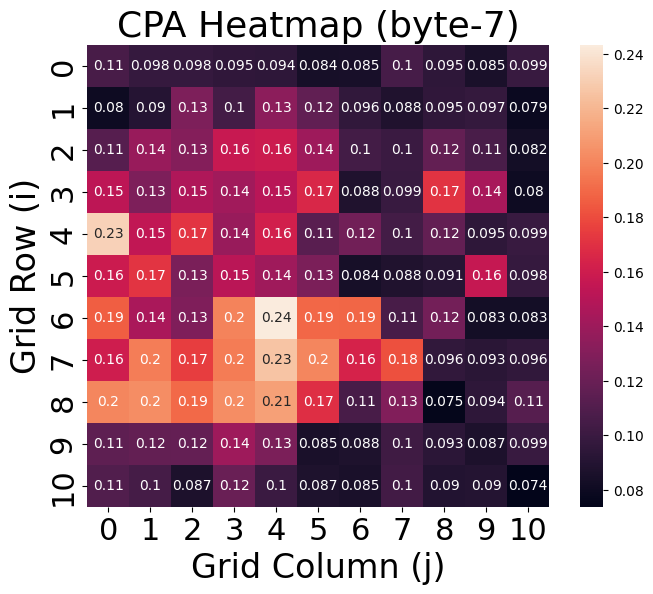

 18%|█▊        | 2/11 [00:00<00:00, 15.67it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 15.90it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


100%|██████████| 11/11 [00:00<00:00, 16.47it/s]


...


 73%|███████▎  | 8/11 [00:00<00:00, 15.40it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 15.21it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 15.42it/s]


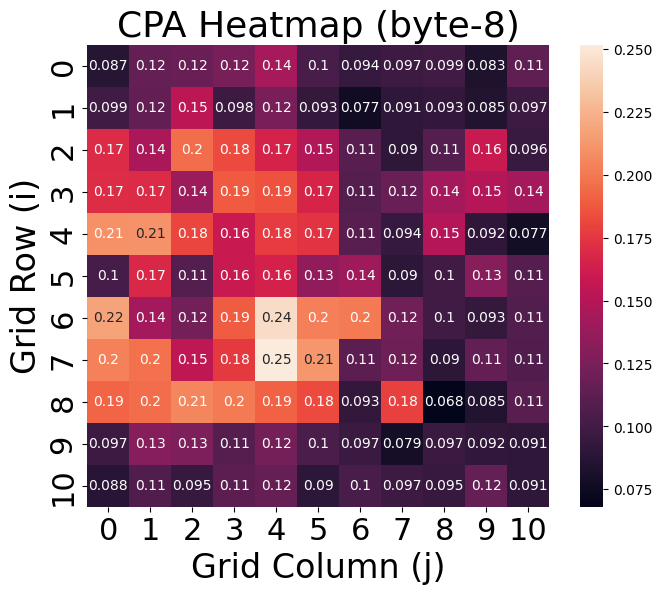

 18%|█▊        | 2/11 [00:00<00:00, 17.48it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 16.84it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


100%|██████████| 11/11 [00:00<00:00, 16.47it/s]

...


 73%|███████▎  | 8/11 [00:00<00:00, 16.40it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 15.70it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 15.83it/s]


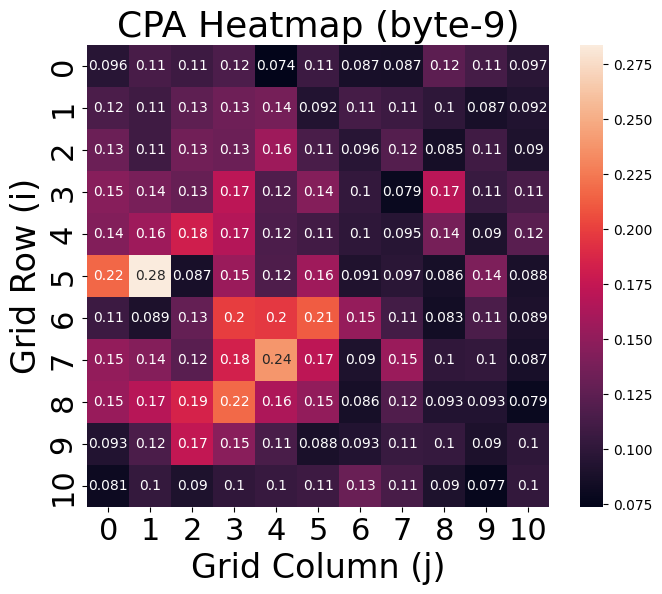

 18%|█▊        | 2/11 [00:00<00:00, 15.94it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 16.13it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


 91%|█████████ | 10/11 [00:00<00:00, 16.91it/s]

...


 73%|███████▎  | 8/11 [00:00<00:00, 14.98it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 15.45it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 14.40it/s]


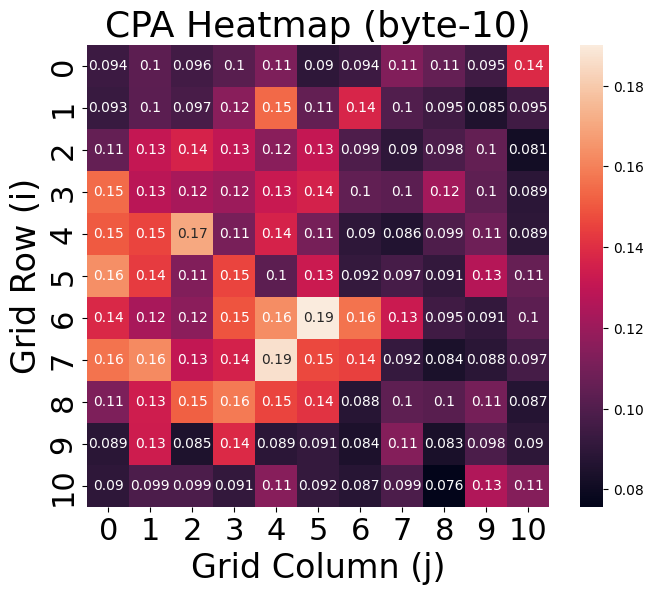

 18%|█▊        | 2/11 [00:00<00:00, 16.09it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 13.37it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)



 73%|███████▎  | 8/11 [00:00<00:00, 12.78it/s]

...

 55%|█████▍    | 6/11 [00:00<00:00, 15.55it/s]

Processing grid position (10, 4)
Processing grid position (10, 5)
Processing grid position (10, 6)
Processing grid position (10, 7)


 91%|█████████ | 10/11 [00:00<00:00, 15.57it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)
Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 15.84it/s]


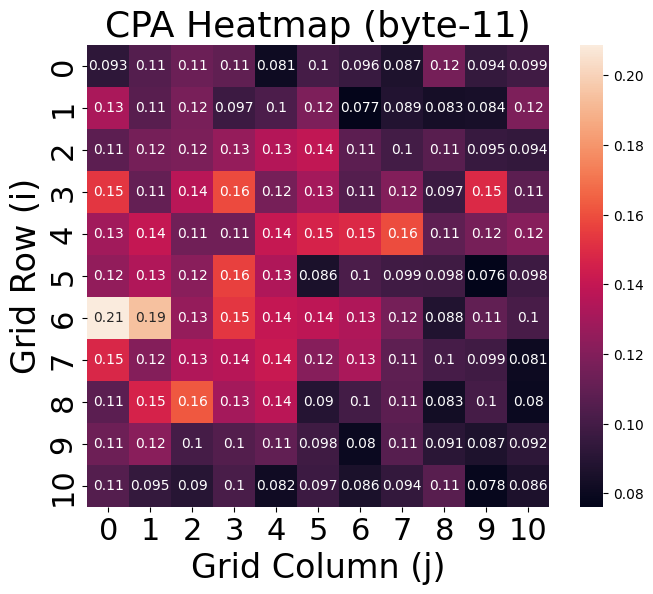

 18%|█▊        | 2/11 [00:00<00:00, 16.04it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 15.09it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


 91%|█████████ | 10/11 [00:00<00:00, 15.35it/s]

...


 73%|███████▎  | 8/11 [00:00<00:00, 15.80it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 16.18it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 15.74it/s]


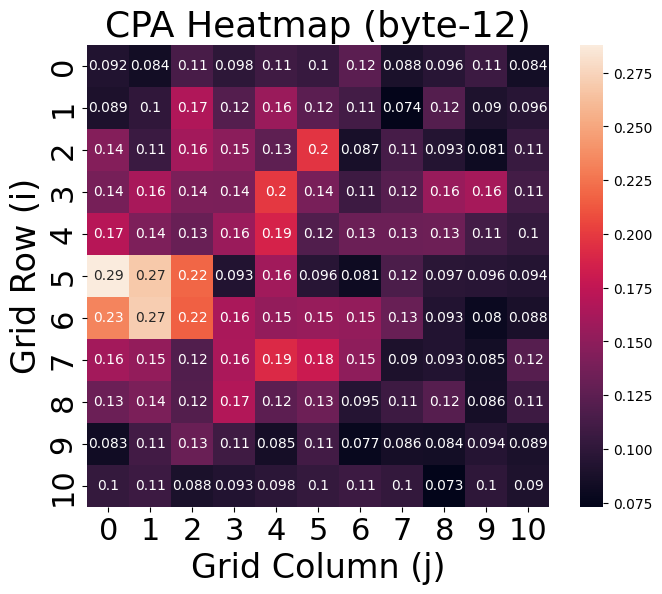

 18%|█▊        | 2/11 [00:00<00:00, 15.99it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)


 55%|█████▍    | 6/11 [00:00<00:00, 16.32it/s]

Processing grid position (0, 3)
Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)


 91%|█████████ | 10/11 [00:00<00:00, 15.90it/s]

...

Processing grid position (10, 3)
Processing grid position (10, 4)
Processing grid position (10, 5)



 73%|███████▎  | 8/11 [00:00<00:00, 15.35it/s]

Processing grid position (10, 6)
Processing grid position (10, 7)
Processing grid position (10, 8)
Processing grid position (10, 9)


100%|██████████| 11/11 [00:00<00:00, 15.12it/s]


Processing grid position (10, 10)


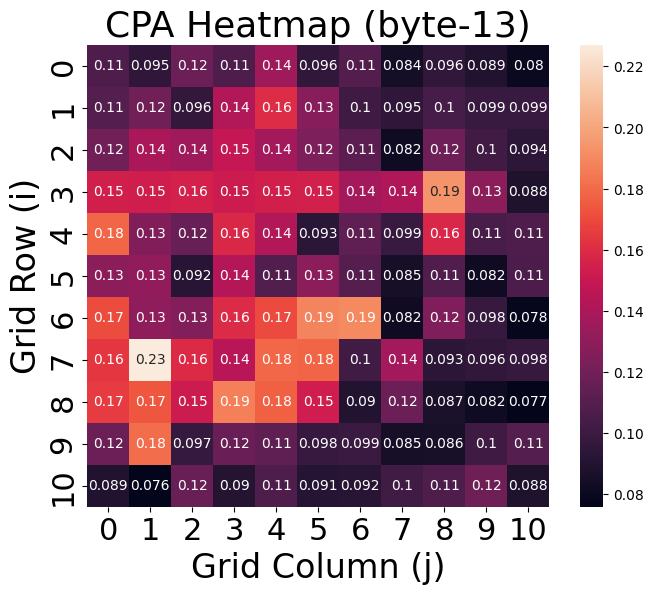

 18%|█▊        | 2/11 [00:00<00:00, 16.13it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 16.30it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


100%|██████████| 11/11 [00:00<00:00, 16.27it/s]


...

Processing grid position (10, 6)
Processing grid position (10, 7)



 73%|███████▎  | 8/11 [00:00<00:00, 16.15it/s]

Processing grid position (10, 8)
Processing grid position (10, 9)


100%|██████████| 11/11 [00:00<00:00, 16.06it/s]

Processing grid position (10, 10)


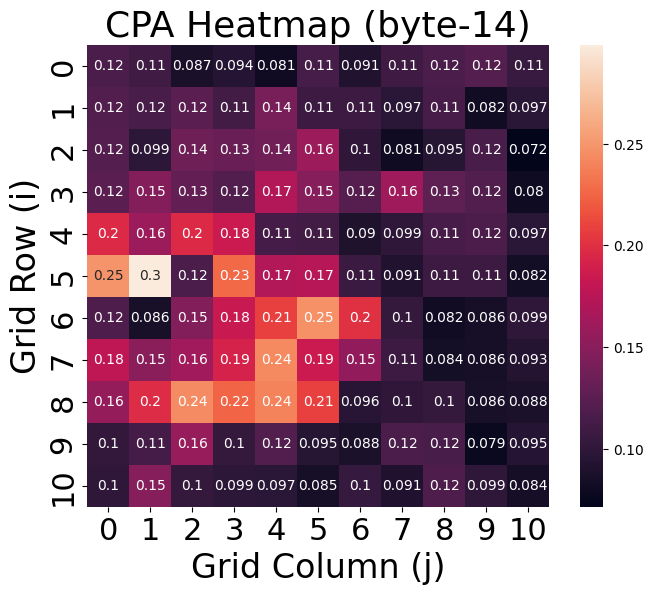

 18%|█▊        | 2/11 [00:00<00:00, 17.22it/s]

Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)


 55%|█████▍    | 6/11 [00:00<00:00, 17.00it/s]

Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)


100%|██████████| 11/11 [00:00<00:00, 16.81it/s]


...


 73%|███████▎  | 8/11 [00:00<00:00, 14.86it/s]

Processing grid position (10, 7)
Processing grid position (10, 8)
Processing grid position (10, 9)



 91%|█████████ | 10/11 [00:00<00:00, 15.59it/s]

Processing grid position (10, 10)


100%|██████████| 11/11 [00:00<00:00, 15.49it/s]


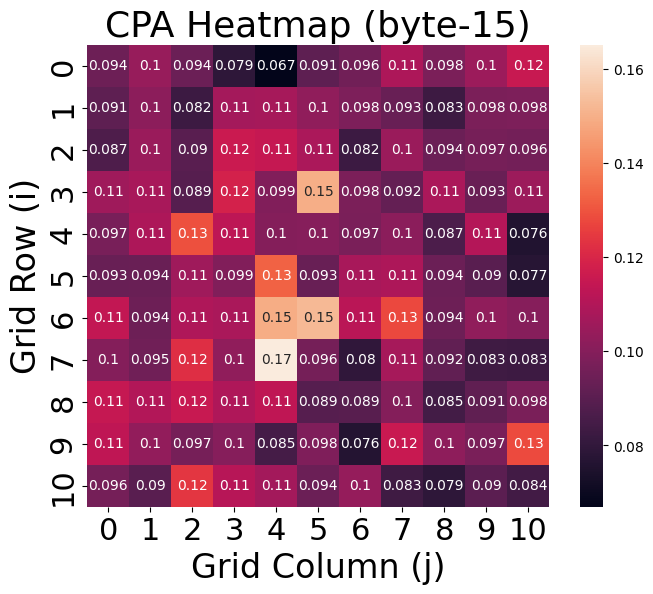

In [433]:
#computes CEMA and plots in a heatmap
for byte_i in range(0,16):

    CEMA,fig = plot_CEMA_heatmap_models(impl_1_a,ptc_5k,N_traces,grid_size=n_steps+1,rotation_n=rotation_n,lower_b=35, model =model_cpa, r1=rnd, r2=rnd+1,target_byte=byte_i)
# fig.savefig(f"final_data//{config}_{target_byte}_{rnd}_CPA_heatmap.png",format="png",bbox_inches="tight")
# save_mat(CEMA,f"final_data//{config}_{target_byte}_{rnd}_CPA_heatmap.mat")


AES model generated
labels created


  0%|          | 0/11 [00:00<?, ?it/s]

running modified code for experiments



  9%|▉         | 1/11 [00:11<01:59, 11.97s/it]

running modified code for experiments


...


 82%|████████▏ | 9/11 [01:57<00:25, 12.92s/it]

running modified code for experiments



 91%|█████████ | 10/11 [02:10<00:12, 12.93s/it]

running modified code for experiments



100%|██████████| 11/11 [26:52<00:00, 146.59s/it]


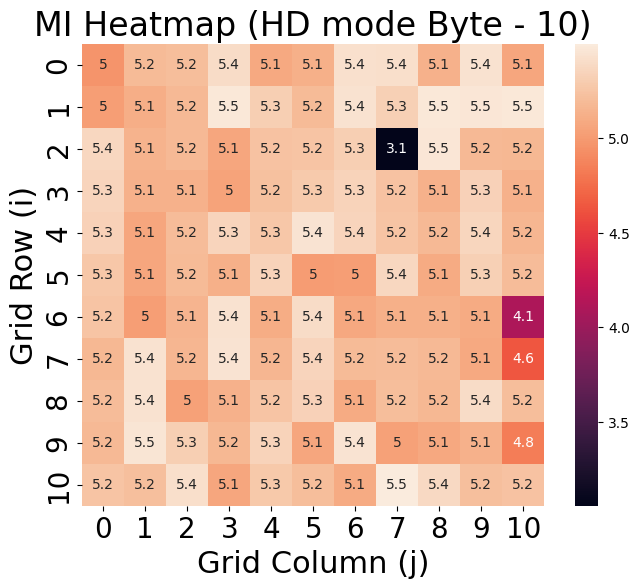

In [613]:
MI,snr_r,fig = plot_MI_heatmap(impl_3_t,ptc_5k,1000,grid_size =11,MI_type="BYTE",target_byte=10,multiplier=1,num_columns=440,rotation_n=3,nystrom=False,m_l=1000,r1=6,r2=7 )
# fig.savefig(f"final_data//{config}_{target_byte}_{rnd}_MI_heatmap.png",format="png",bbox_inches="tight")
# save_mat(MI,f"final_data//{config}_{target_byte}_{rnd}_MI_heatmap.mat")

In [233]:
MI_1 = MI - np.min(MI)

In [215]:
MI

array([[3.11635399, 3.12560368, 3.11927605, 3.1118679 , 3.13334942,
        3.12716007, 3.12108707, 3.11624146, 3.11694431, 3.11357594,
        3.09446144],
       [3.10833454, 3.11747742, 3.10093117, 3.09953594, 3.07207966,
        3.11084652, 3.12594318, 3.12094975, 3.12299824, 3.11662674,
        3.09688377],
       [3.09756565, 3.03972721, 3.00032282, 2.9829092 , 2.95899296,
        3.02020693, 3.11944103, 3.11961937, 3.11932468, 3.12444115,
        3.09771824],
       [2.90978193, 2.90998268, 2.92438126, 2.91909504, 2.90813494,
        2.99780941, 3.11069107, 3.10544205, 3.07531929, 3.10902023,
        3.08594608],
       [3.16330528, 2.85042   , 3.00207901, 3.03068733, 3.02880907,
        3.1060524 , 3.10363007, 3.09915257, 3.05315399, 3.08256721,
        3.04750443],
       [3.09004688, 3.08385563, 3.12769318, 3.13664532, 3.12692833,
        3.11322403, 2.97576714, 2.95745516, 2.96890211, 3.02503729,
        2.96625328],
       [2.94891977, 2.95022058, 2.99728012, 3.01753378, 2.

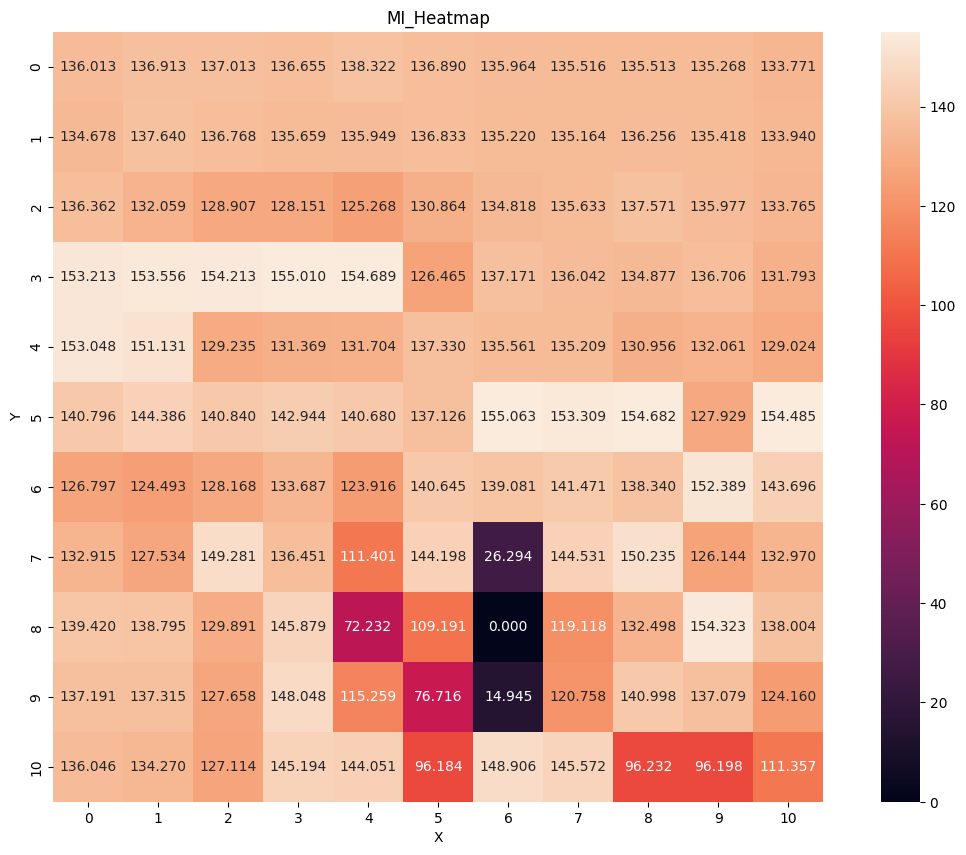

In [235]:
plt.figure(figsize=(15, 10))
# sns.heatmap(1000*MI_1, annot=anno, fmt=".3f", cbar=cba, square=squar)

sns.heatmap(100*MI_1, annot=True ,fmt=".3f", cbar=True , square=True )
# sns.heatmap(10000*MI_1, annot=True , cbar=True , square=True )

# Adding labels and title
plt.title('MI_Heatmap')
plt.xlabel("X")
plt.ylabel("Y")

# Show the plot
plt.show()

In [27]:
save_mat(t,f"final_data//{config}_t_heatmap.mat")
# save_mat(CEMA,f"{config}_{target_byte}_{rnd}_CPA_heatmap.mat")
# save_mat(MI,f"{config}_{target_byte}_{rnd}_MI_heatmap.mat")
# # save_mat(t,f"{config}_t_heatmap")
# # save_mat(t,f"{config}_t_heatmap")
# save_fig(t,f"{config}_t_heatmap")
# save_fig(CEMA,f"{config}_{target_byte}_{rnd}_CPA_heatmap")
# save_fig(MI,f"{config}_{target_byte}_{rnd}_MI_heatmap")

In [ ]:
SNR,SNR_db,min_n = plot_SNR_min_heatmap(test,ptc_5k,N_traces,grid_size=6,rotation_n=2,MAX=True)

In [ ]:
SNR,SNR_db,min_n = plot_SNR_min_heatmap(test,pt,N_traces,grid_size=6,rotation_n=2,MAX=False)


🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:09<00:00, 106.14it/s]

0
Shape of maxcpa_matrix: (100, 256)


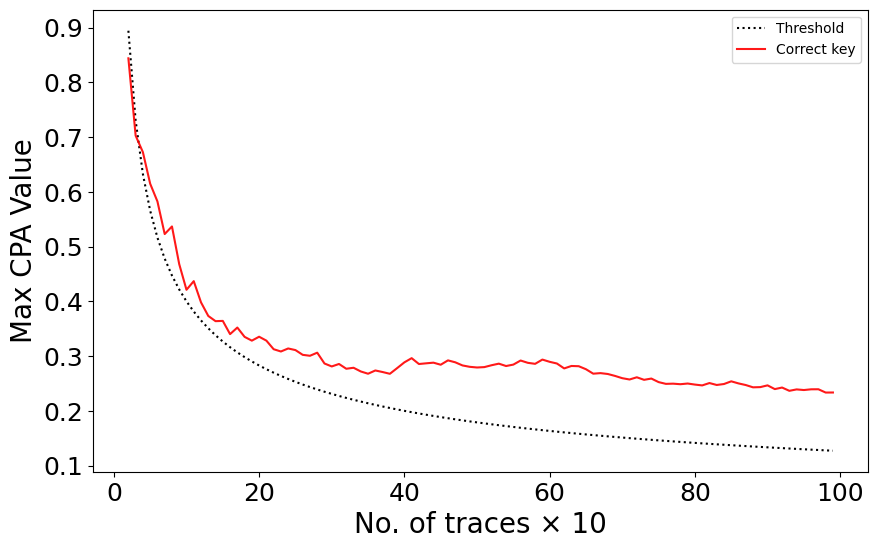

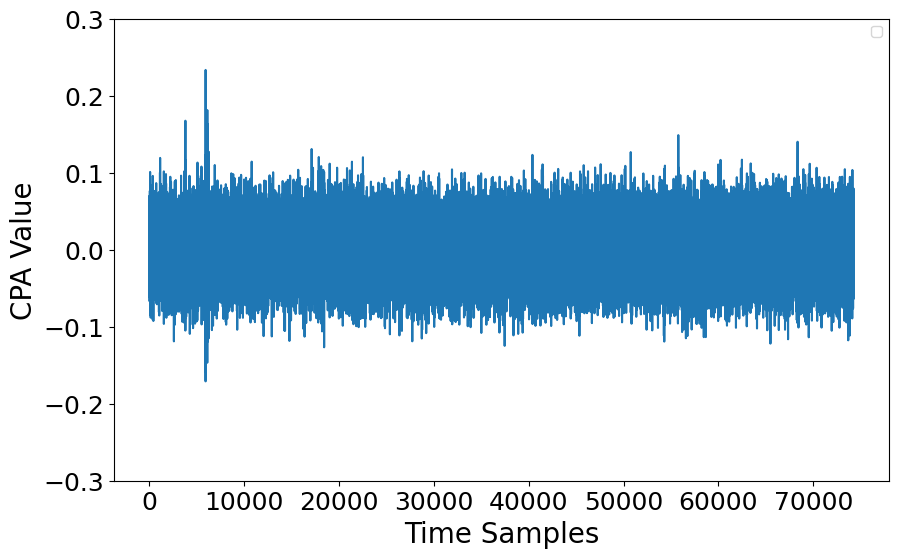

✅ CPA crosses threshold permanently at index 2 (≈ 40 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 105.28it/s]

0
Shape of maxcpa_matrix: (100, 256)


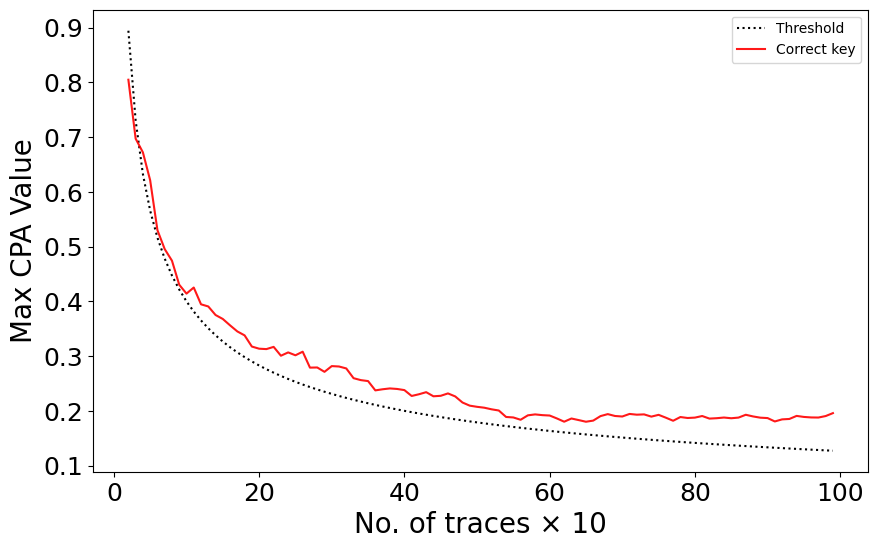

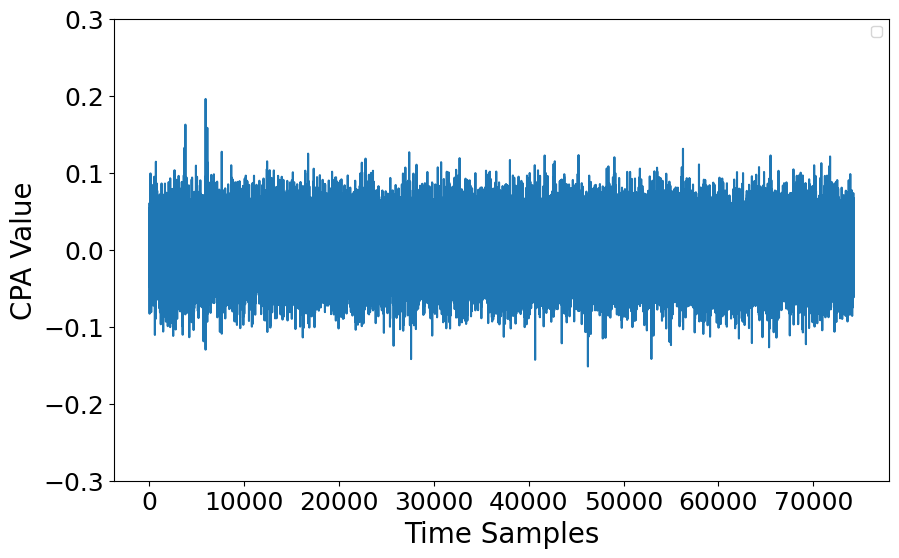

✅ CPA crosses threshold permanently at index 2 (≈ 40 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:09<00:00, 105.54it/s]

0
Shape of maxcpa_matrix: (100, 256)


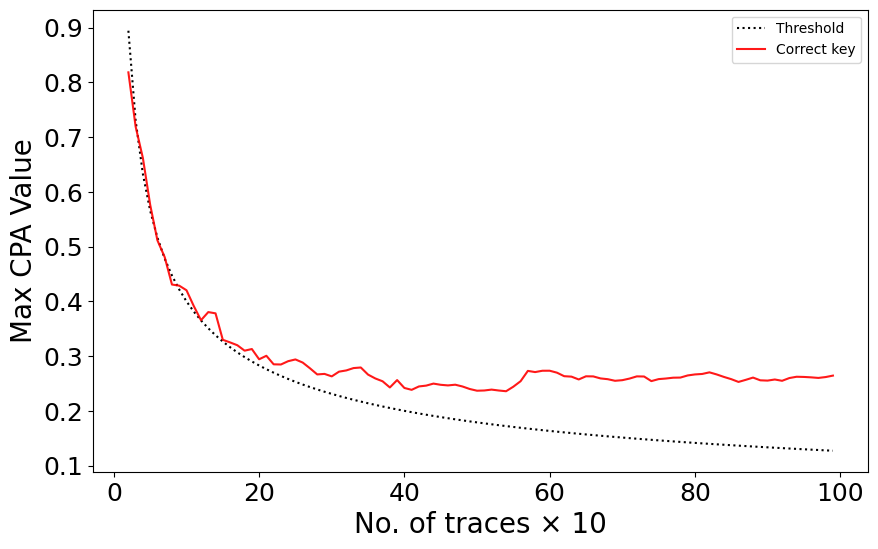

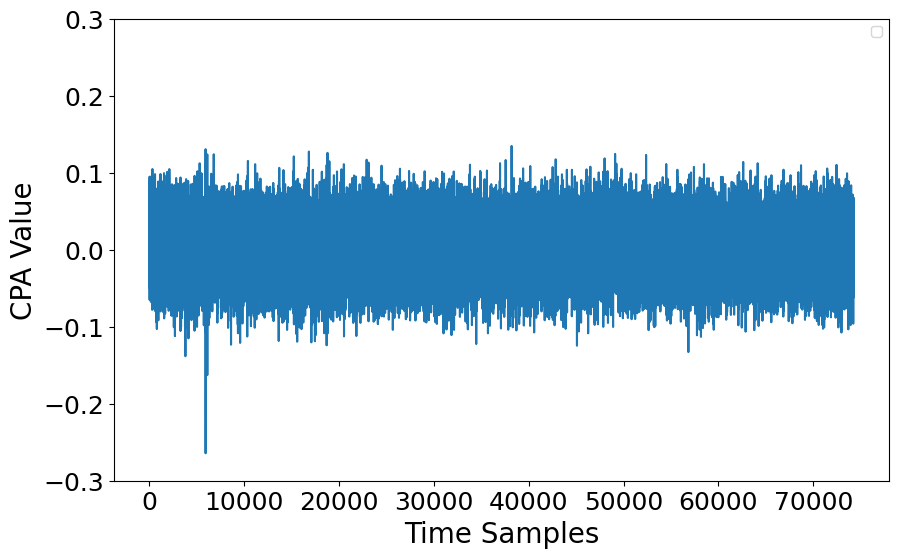

✅ CPA crosses threshold permanently at index 7 (≈ 90 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:09<00:00, 101.50it/s]

1
Shape of maxcpa_matrix: (100, 256)


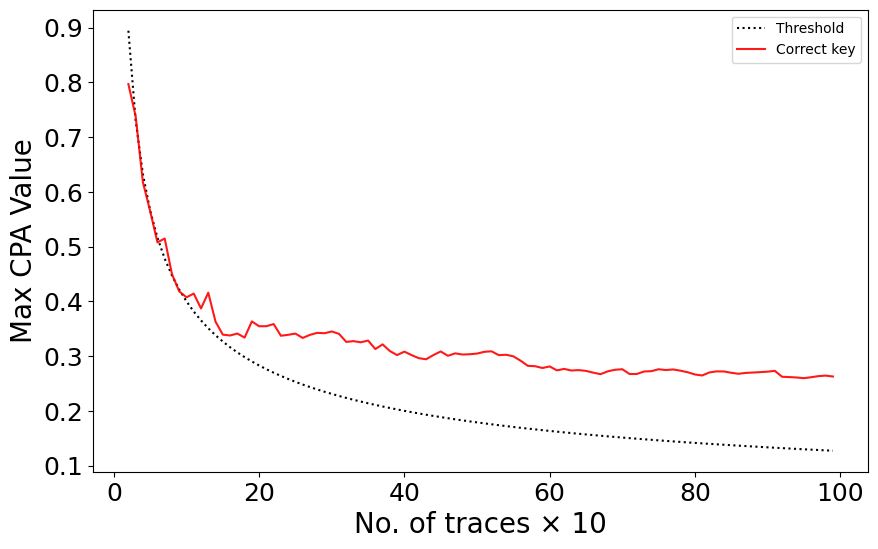

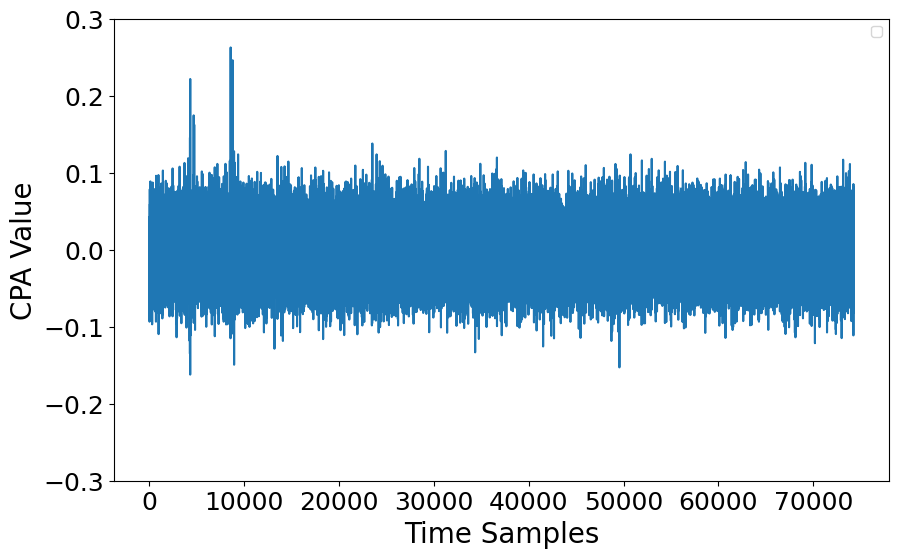

✅ CPA crosses threshold permanently at index 8 (≈ 100 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 105.51it/s]

1
Shape of maxcpa_matrix: (100, 256)


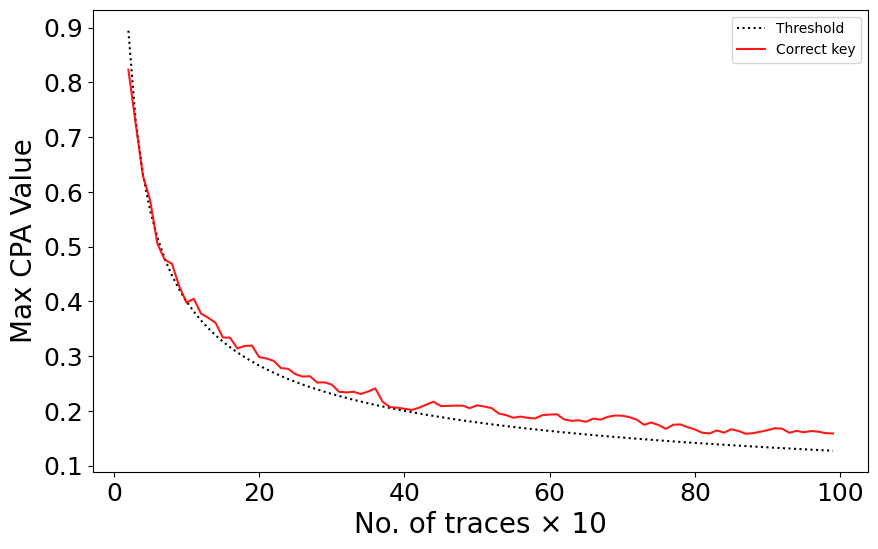

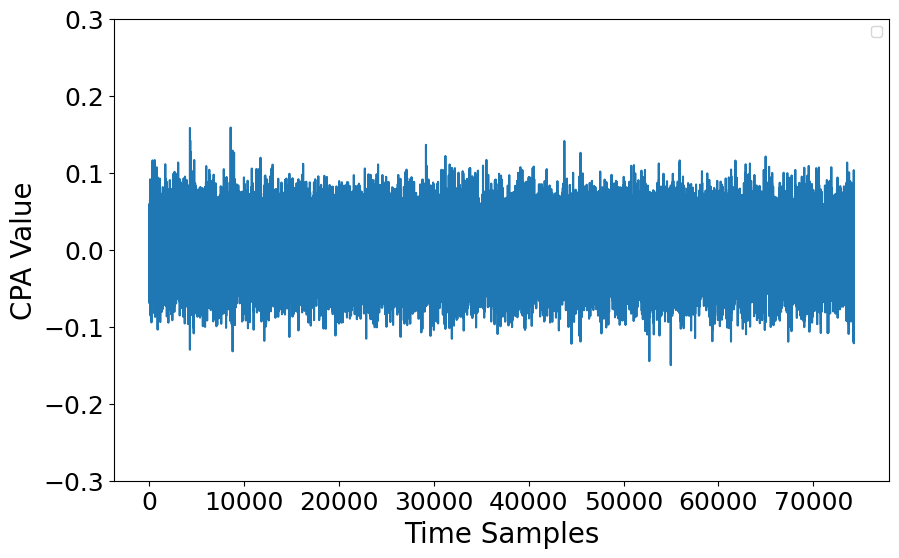

✅ CPA crosses threshold permanently at index 9 (≈ 110 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:09<00:00, 106.57it/s]

1
Shape of maxcpa_matrix: (100, 256)


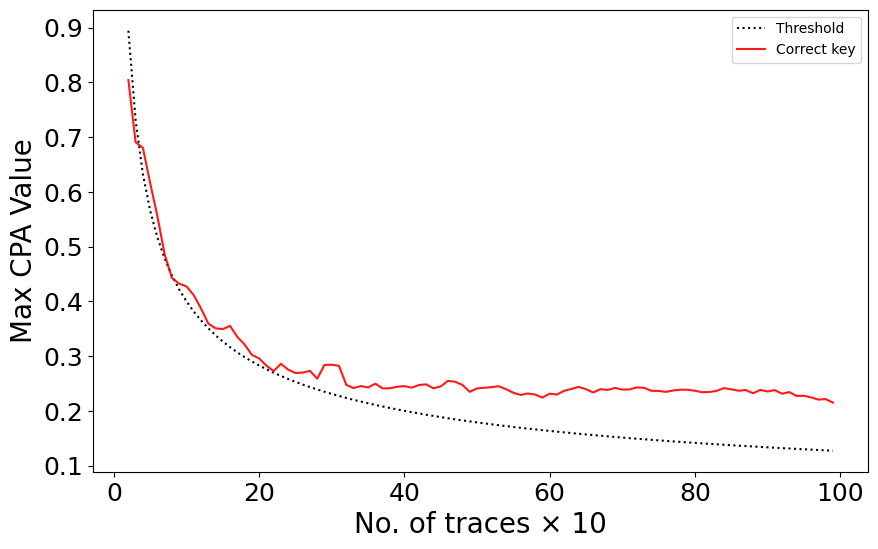

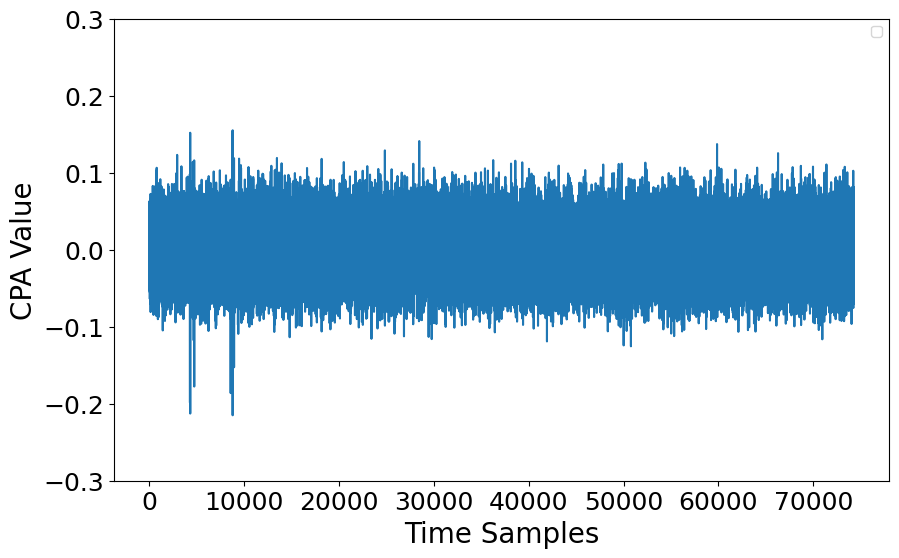

✅ CPA crosses threshold permanently at index 7 (≈ 90 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:09<00:00, 104.87it/s]


2
Shape of maxcpa_matrix: (100, 256)


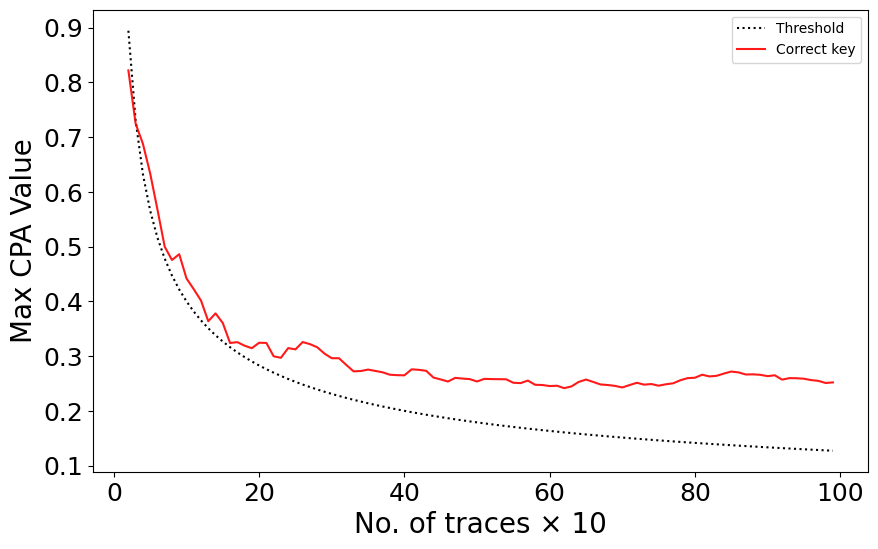

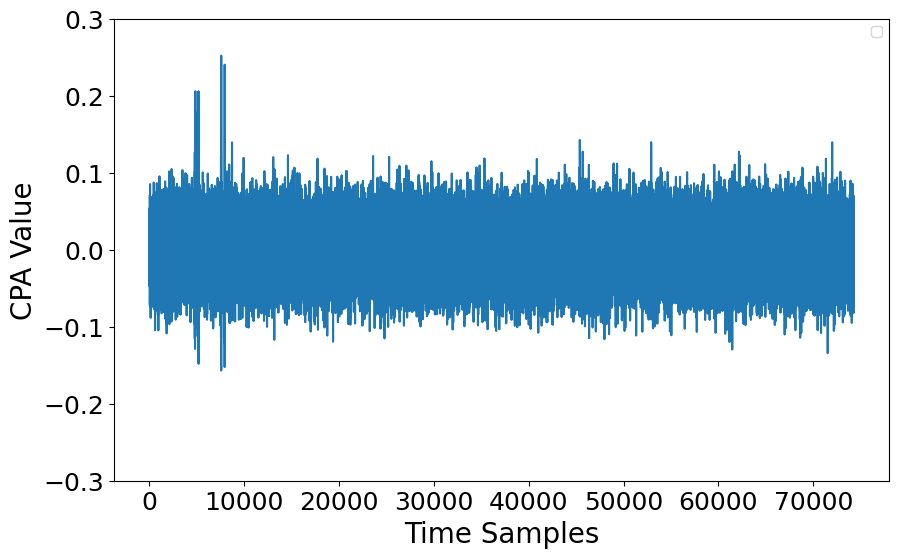

✅ CPA crosses threshold permanently at index 2 (≈ 40 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 102.54it/s]

2
Shape of maxcpa_matrix: (100, 256)


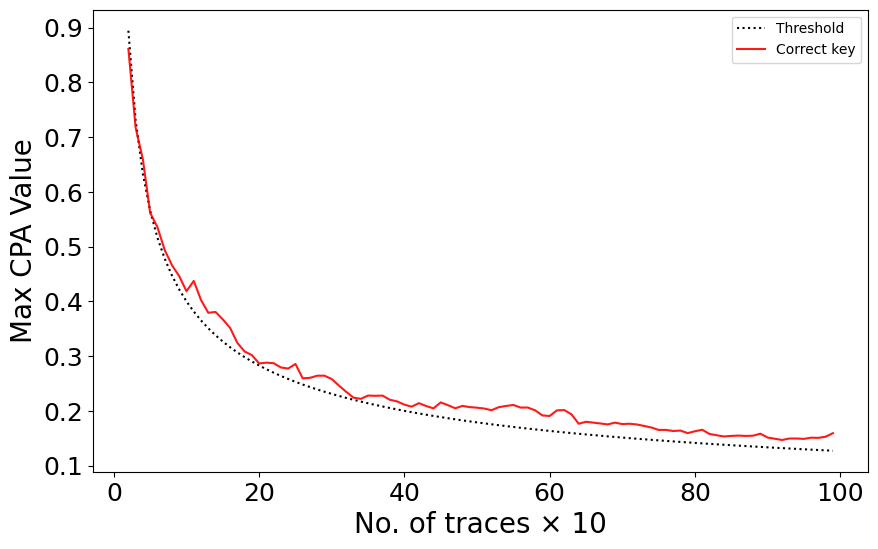

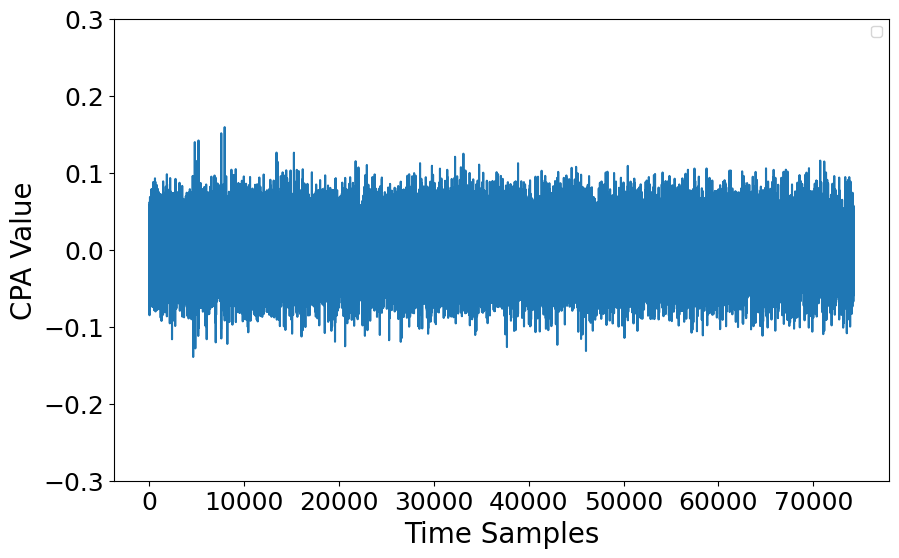

✅ CPA crosses threshold permanently at index 4 (≈ 60 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:09<00:00, 105.16it/s]

2
Shape of maxcpa_matrix: (100, 256)


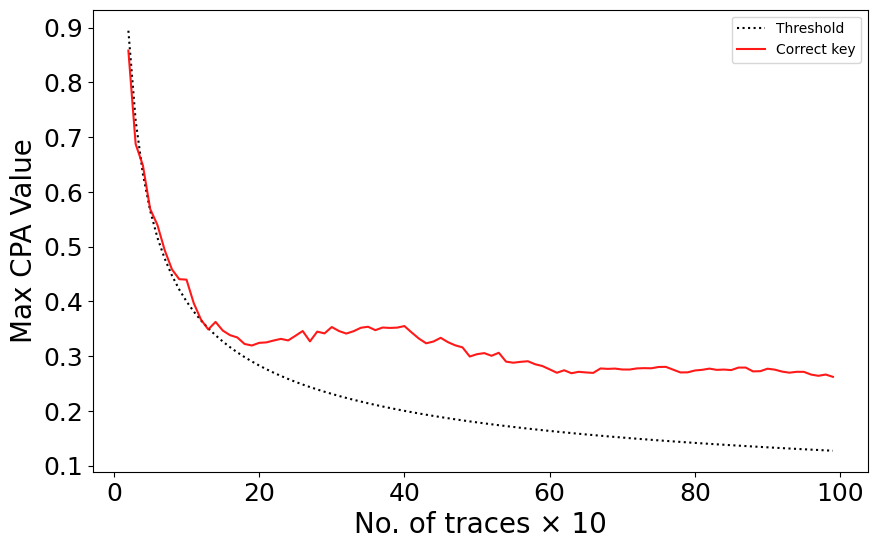

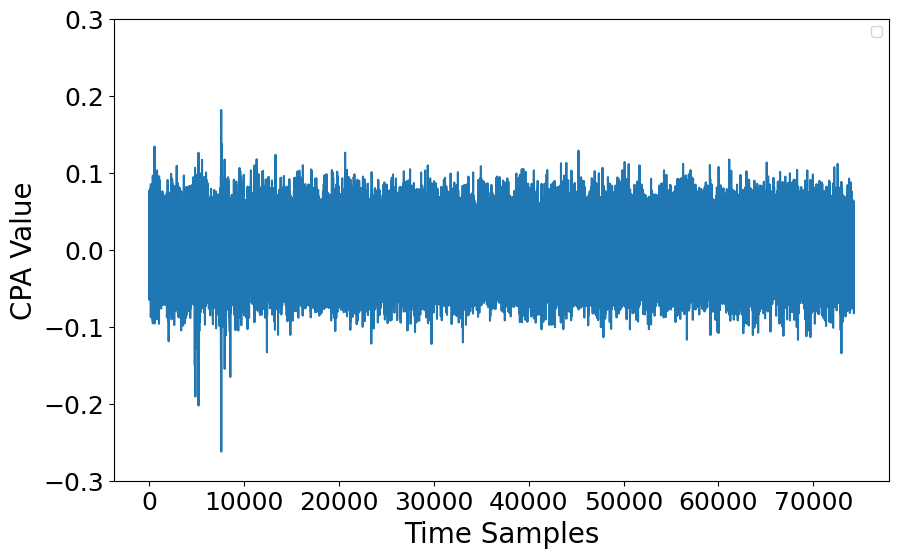

✅ CPA crosses threshold permanently at index 12 (≈ 140 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:09<00:00, 100.11it/s]

3
Shape of maxcpa_matrix: (100, 256)


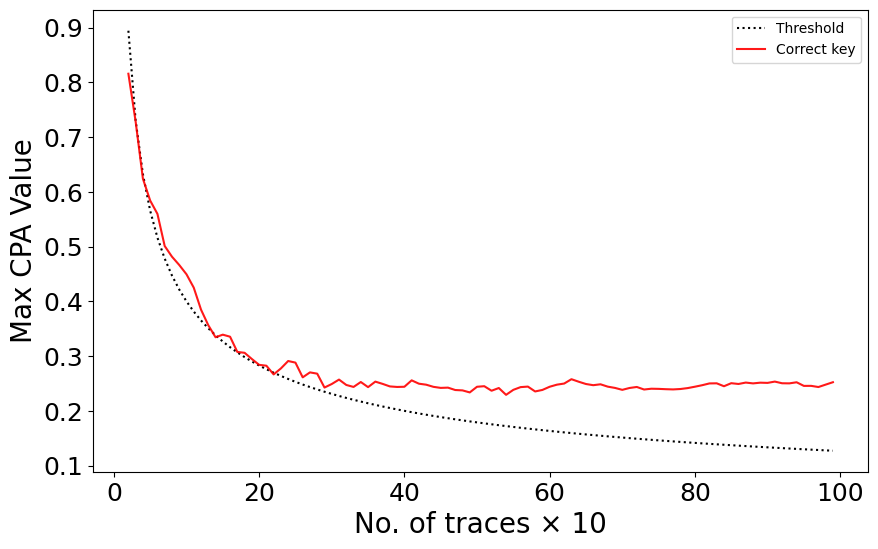

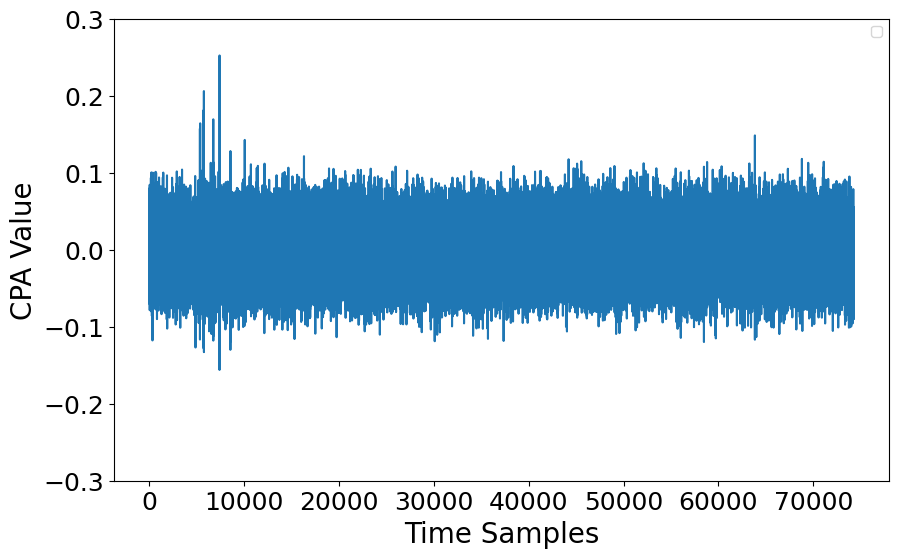

✅ CPA crosses threshold permanently at index 21 (≈ 230 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 100.52it/s]

3
Shape of maxcpa_matrix: (100, 256)


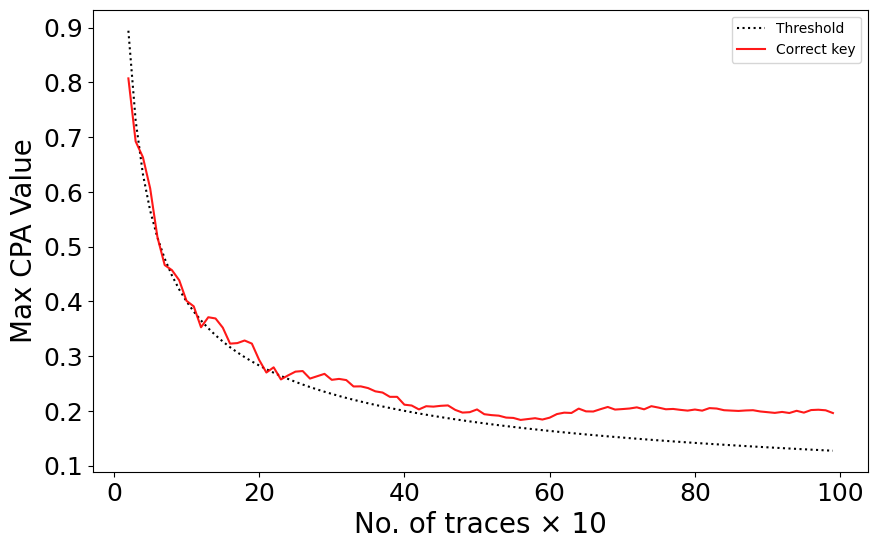

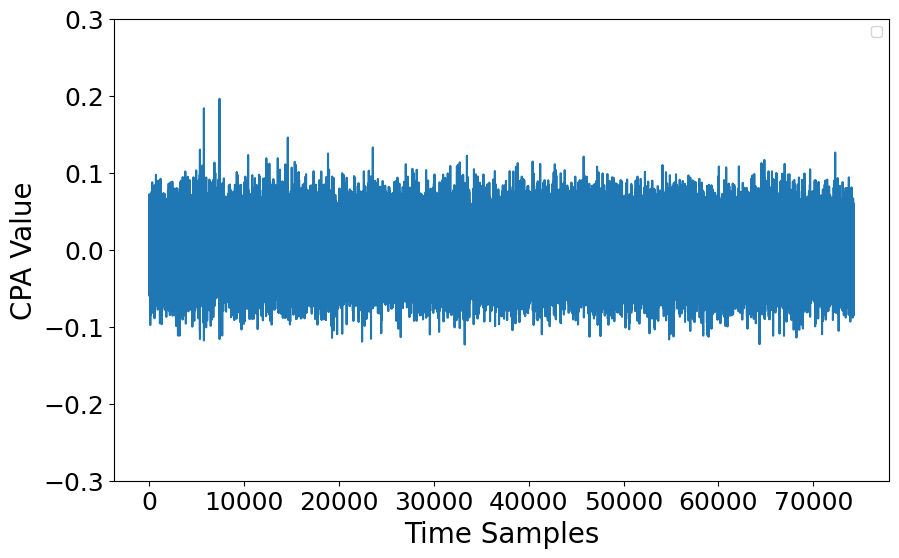

✅ CPA crosses threshold permanently at index 22 (≈ 240 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:09<00:00, 103.99it/s]

3
Shape of maxcpa_matrix: (100, 256)


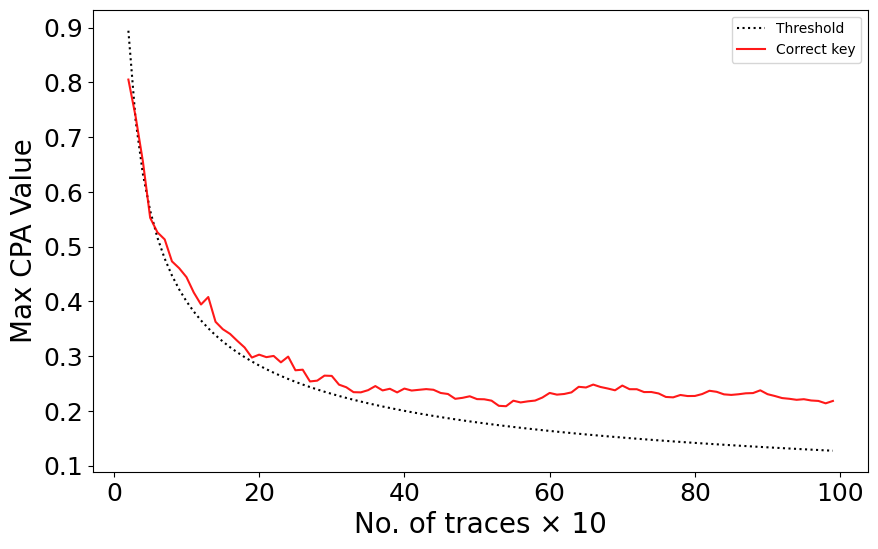

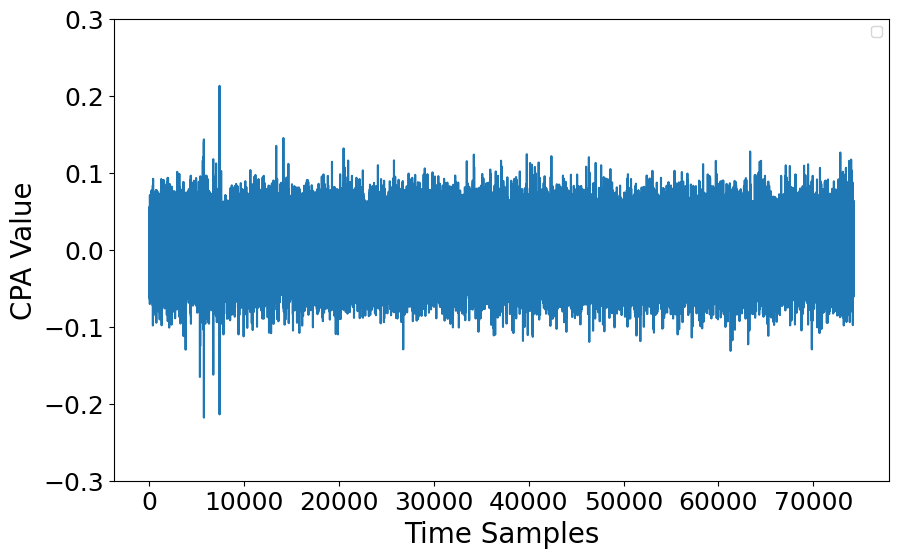

✅ CPA crosses threshold permanently at index 4 (≈ 60 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 99.49it/s] 

4
Shape of maxcpa_matrix: (100, 256)


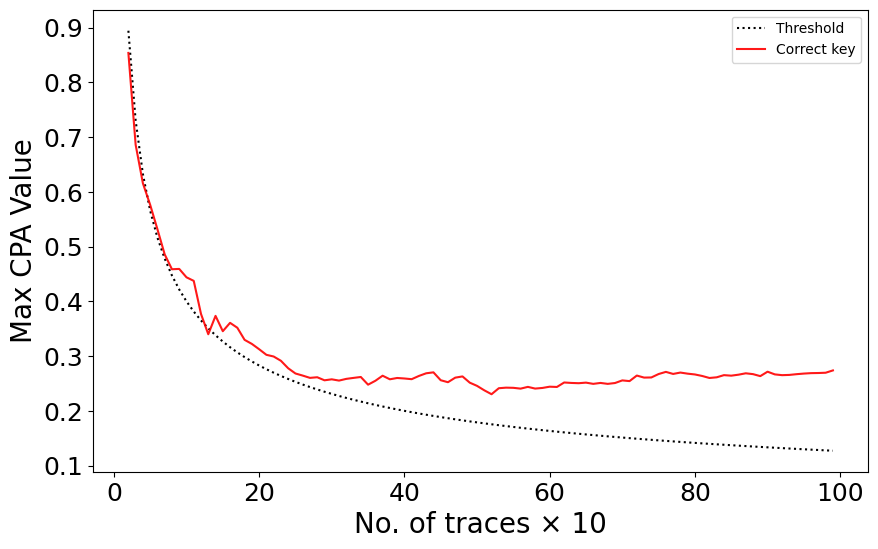

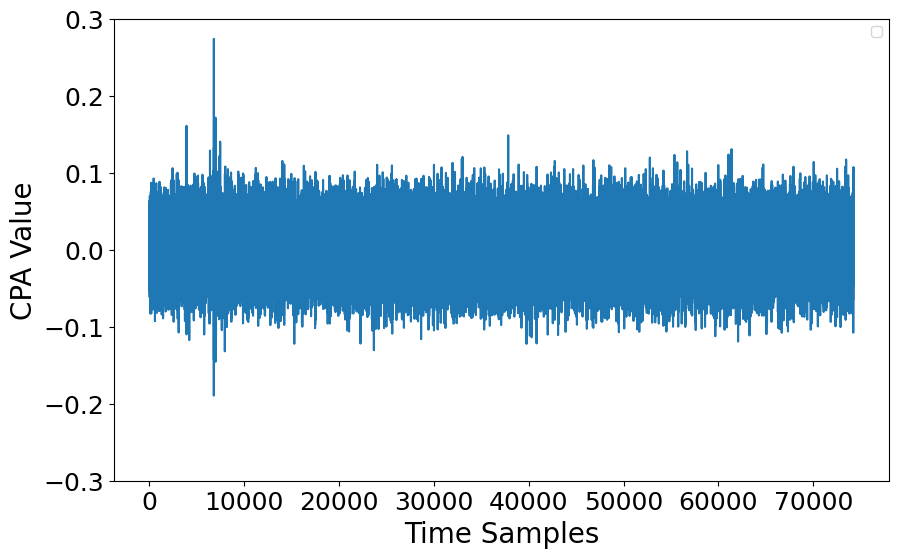

✅ CPA crosses threshold permanently at index 12 (≈ 140 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 103.04it/s]

4
Shape of maxcpa_matrix: (100, 256)


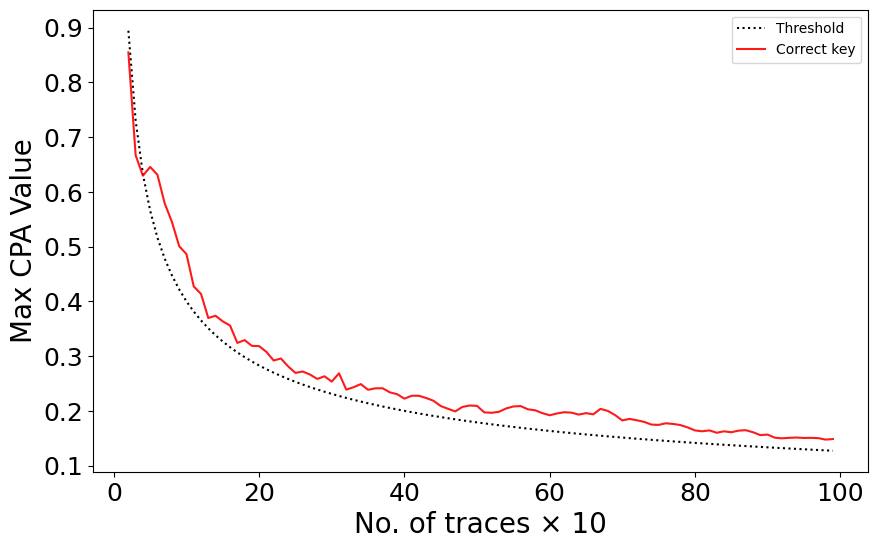

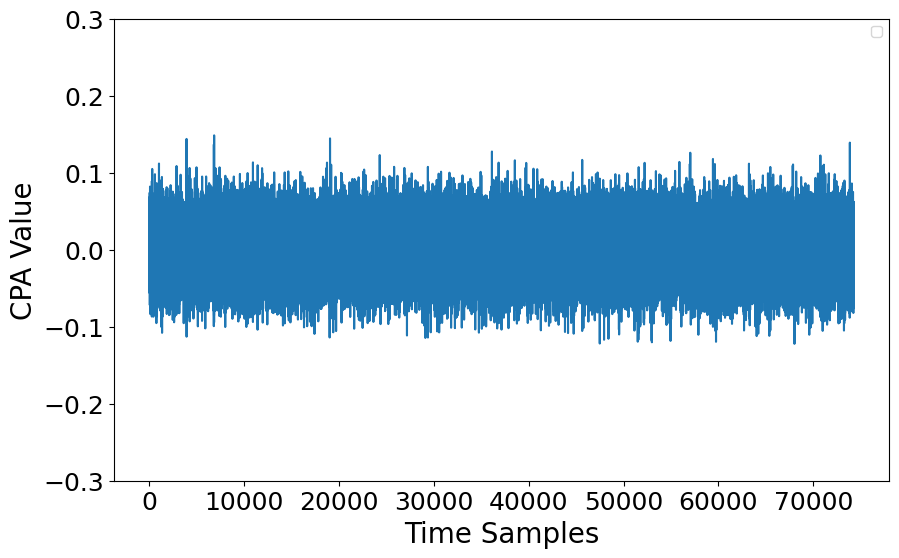

✅ CPA crosses threshold permanently at index 3 (≈ 50 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:09<00:00, 102.38it/s]

4
Shape of maxcpa_matrix: (100, 256)


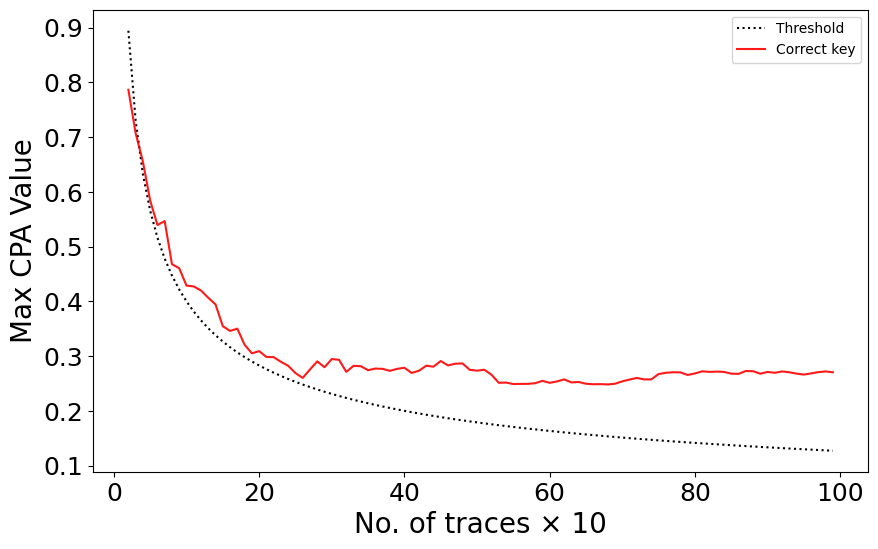

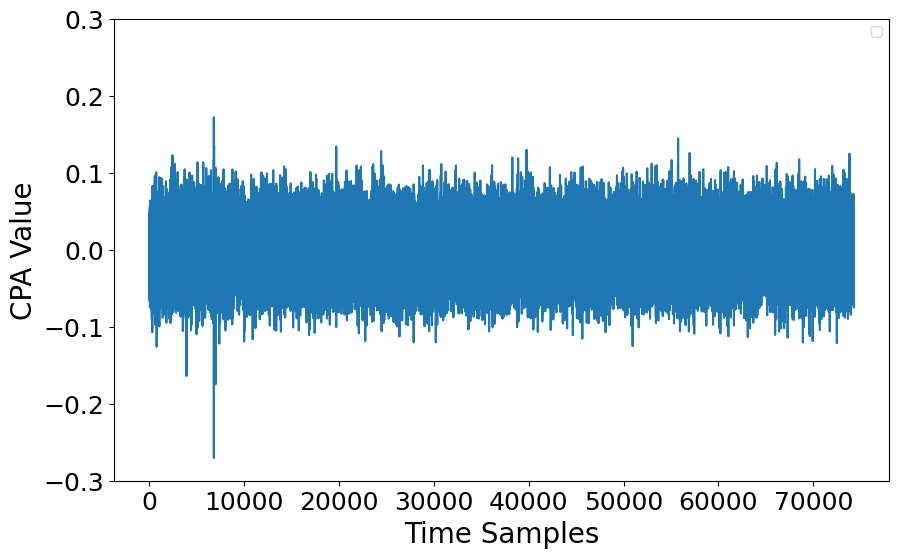

✅ CPA crosses threshold permanently at index 2 (≈ 40 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 95.55it/s] 

5
Shape of maxcpa_matrix: (100, 256)


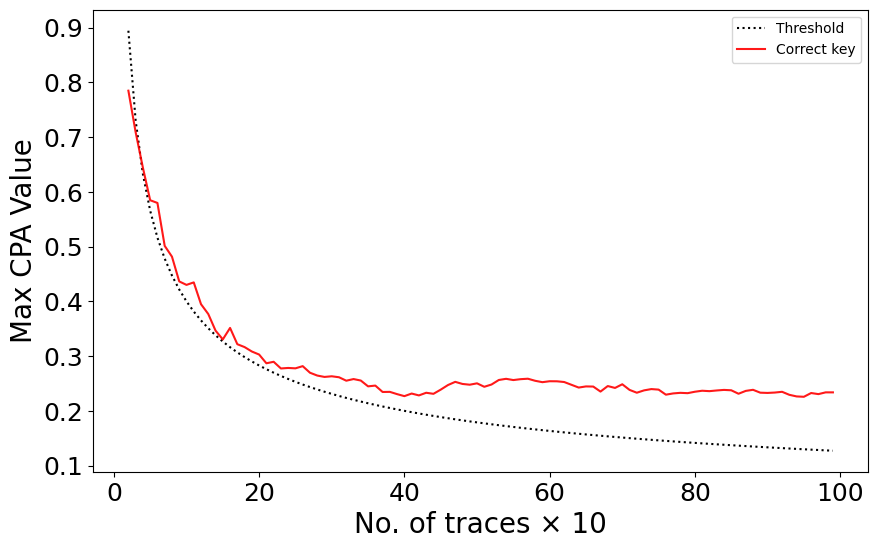

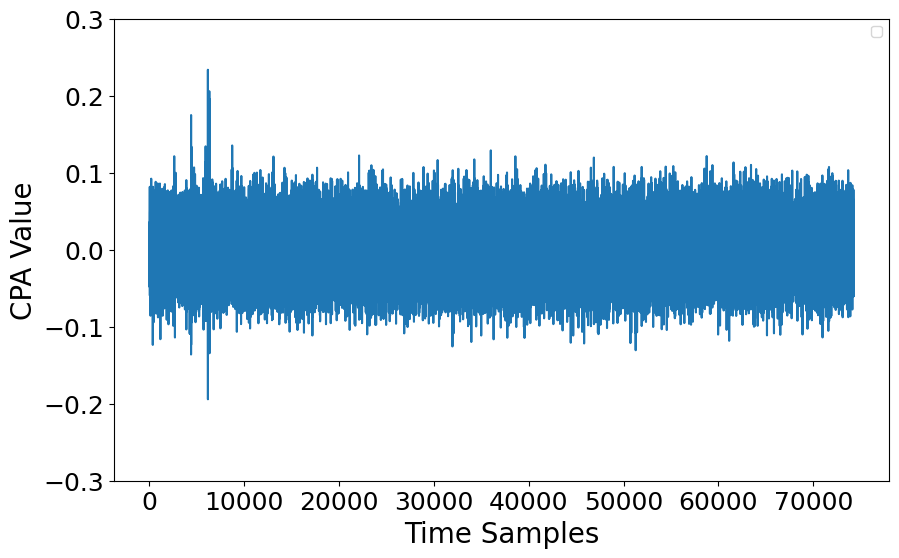

✅ CPA crosses threshold permanently at index 2 (≈ 40 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:10<00:00, 99.04it/s] 

5
Shape of maxcpa_matrix: (100, 256)


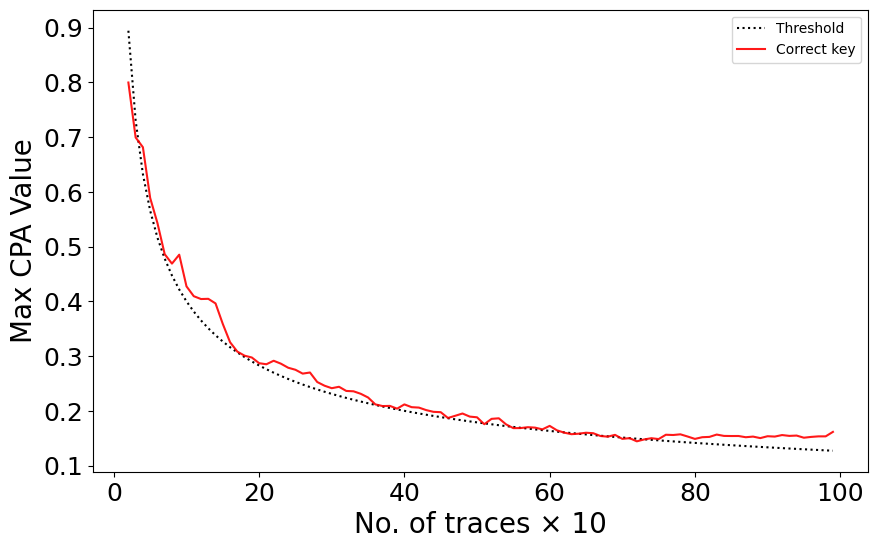

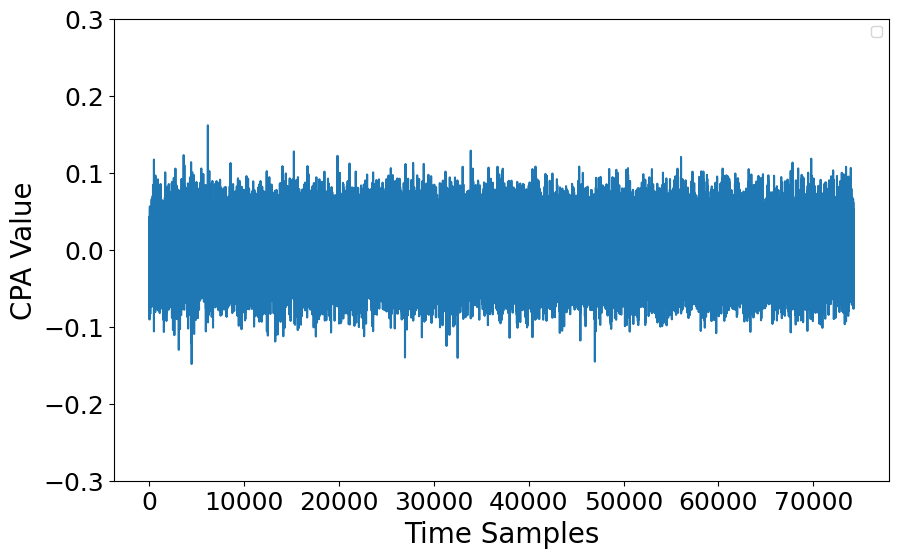

✅ CPA crosses threshold permanently at index 72 (≈ 740 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:09<00:00, 102.80it/s]

5
Shape of maxcpa_matrix: (100, 256)


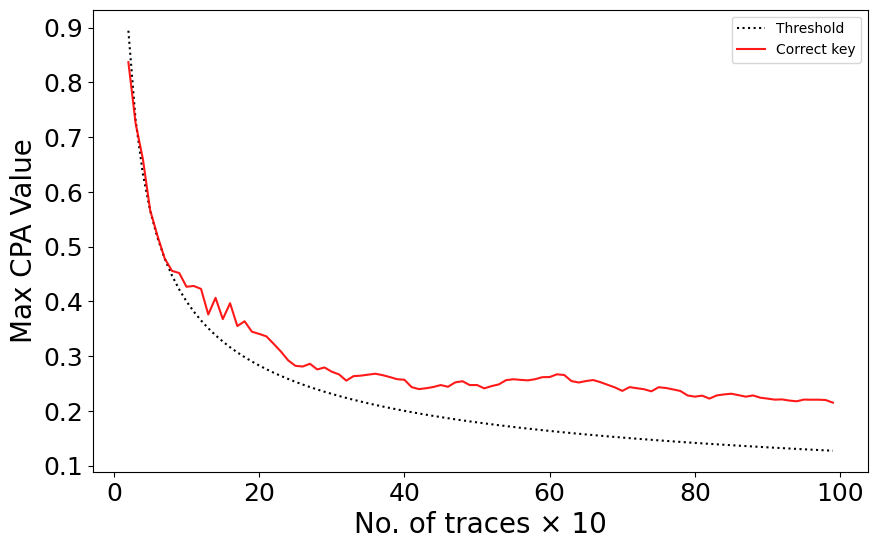

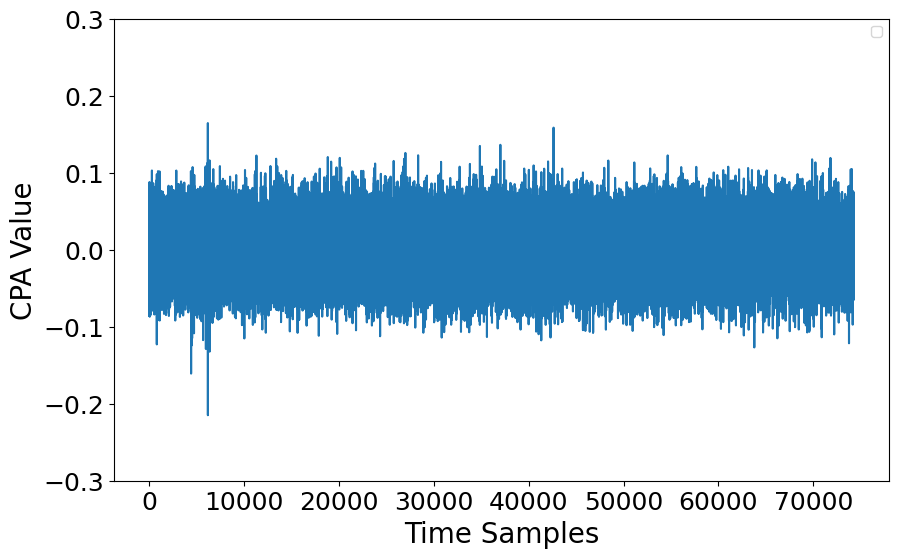

✅ CPA crosses threshold permanently at index 2 (≈ 40 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:09<00:00, 103.81it/s]

6
Shape of maxcpa_matrix: (100, 256)


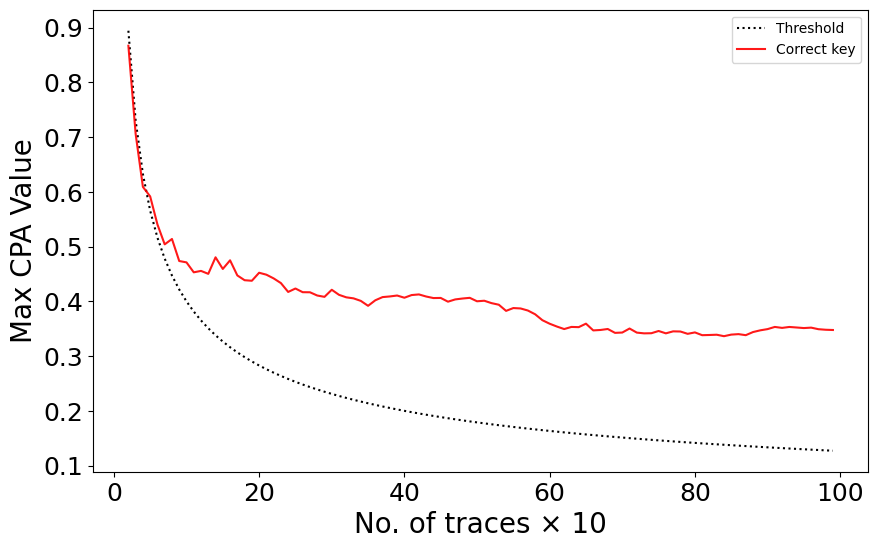

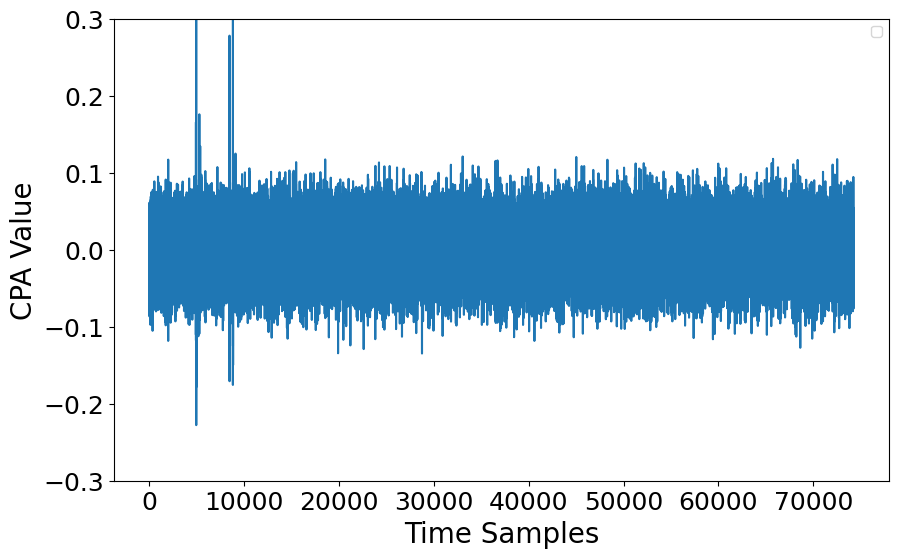

✅ CPA crosses threshold permanently at index 3 (≈ 50 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 101.45it/s]

6
Shape of maxcpa_matrix: (100, 256)


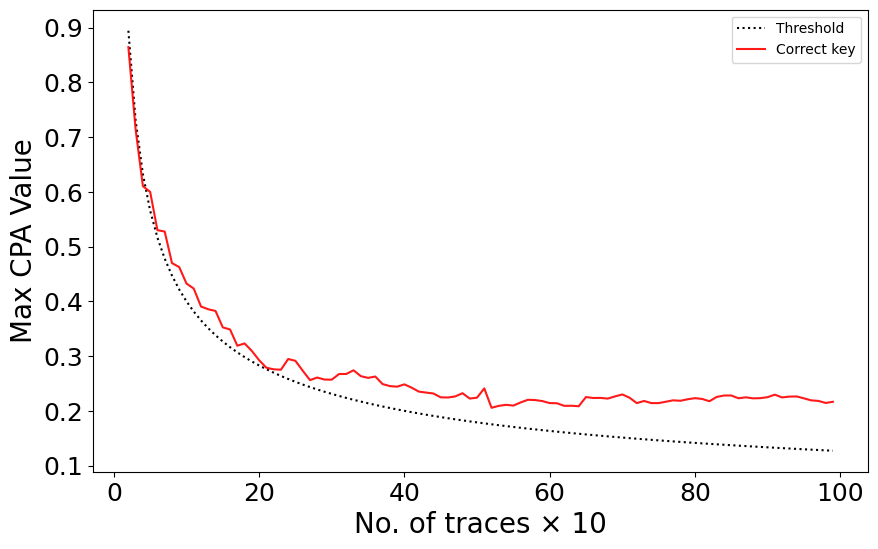

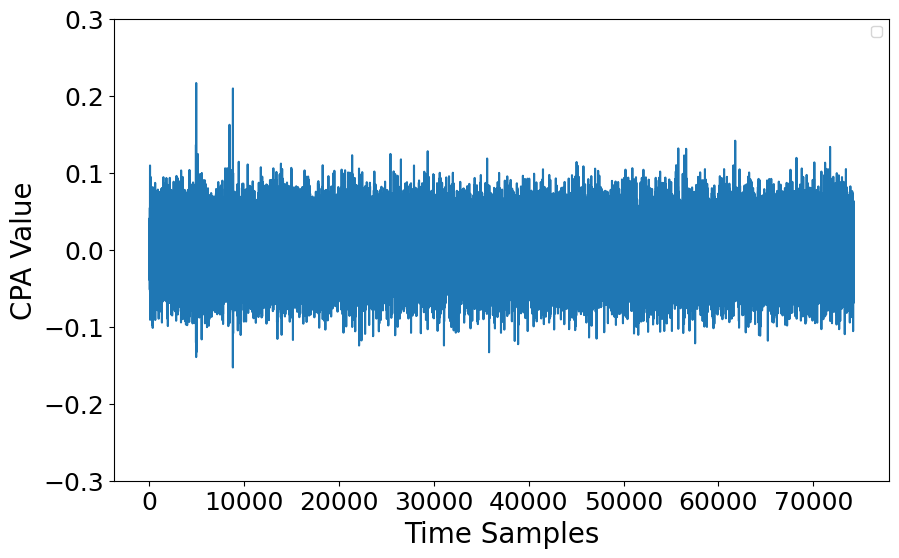

✅ CPA crosses threshold permanently at index 3 (≈ 50 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 99.58it/s] 

6
Shape of maxcpa_matrix: (100, 256)


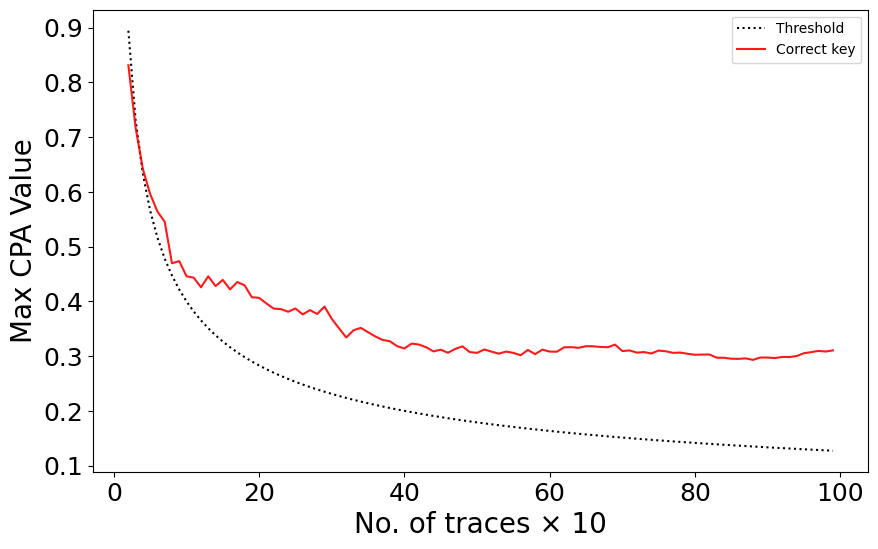

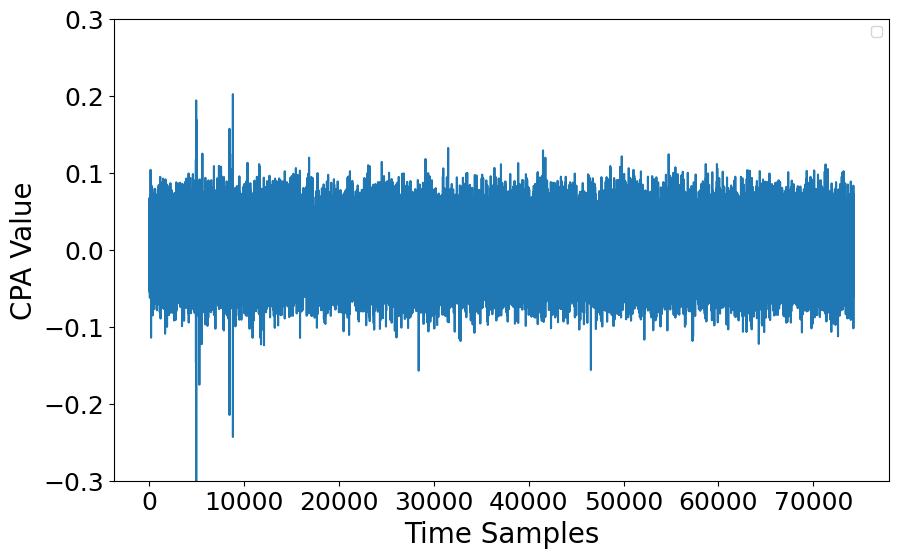

✅ CPA crosses threshold permanently at index 2 (≈ 40 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 98.00it/s] 

7
Shape of maxcpa_matrix: (100, 256)


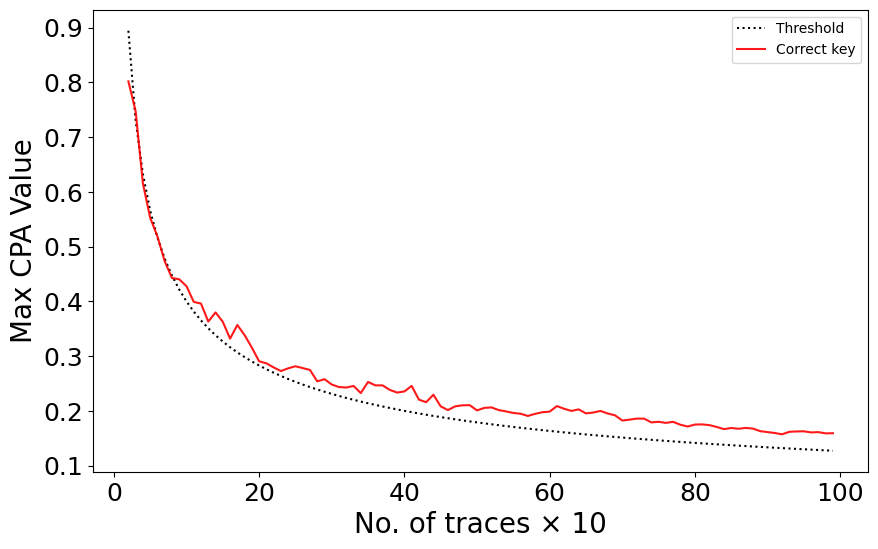

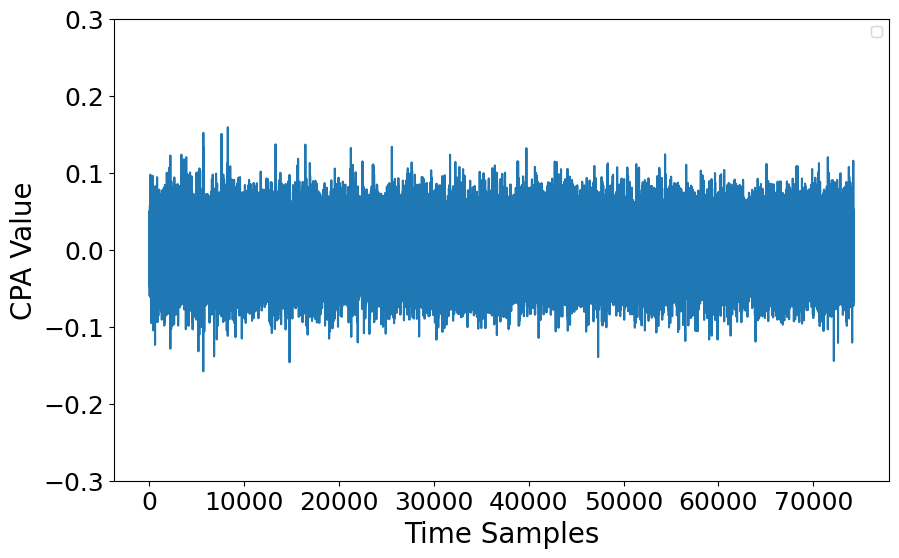

✅ CPA crosses threshold permanently at index 7 (≈ 90 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 101.61it/s]

7
Shape of maxcpa_matrix: (100, 256)


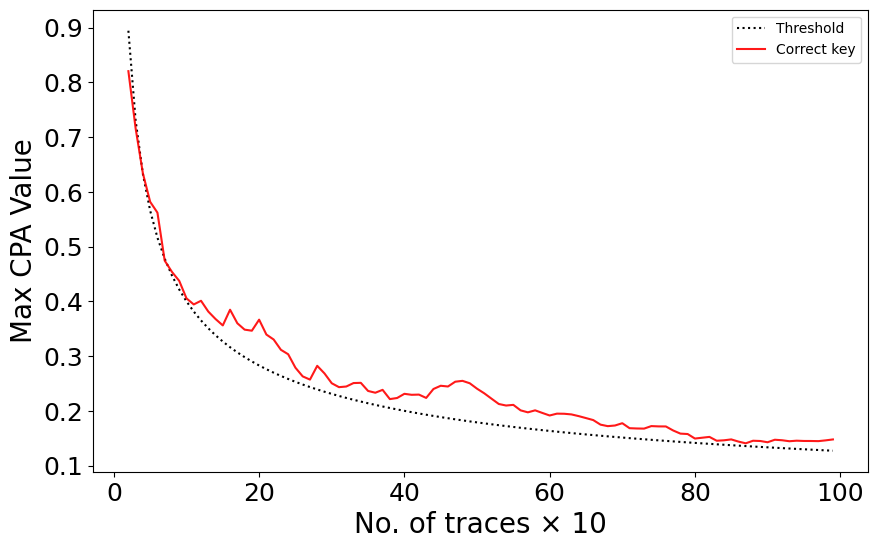

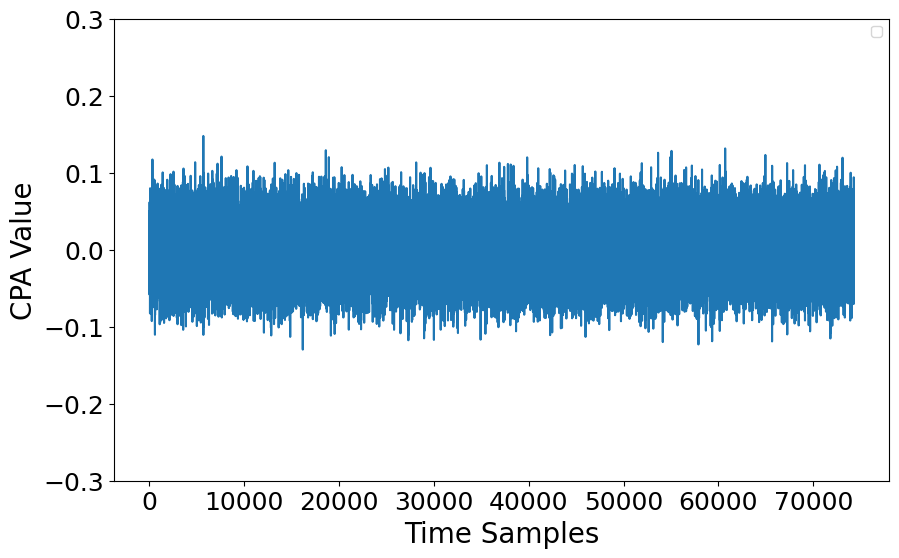

✅ CPA crosses threshold permanently at index 6 (≈ 80 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 98.28it/s] 

7
Shape of maxcpa_matrix: (100, 256)


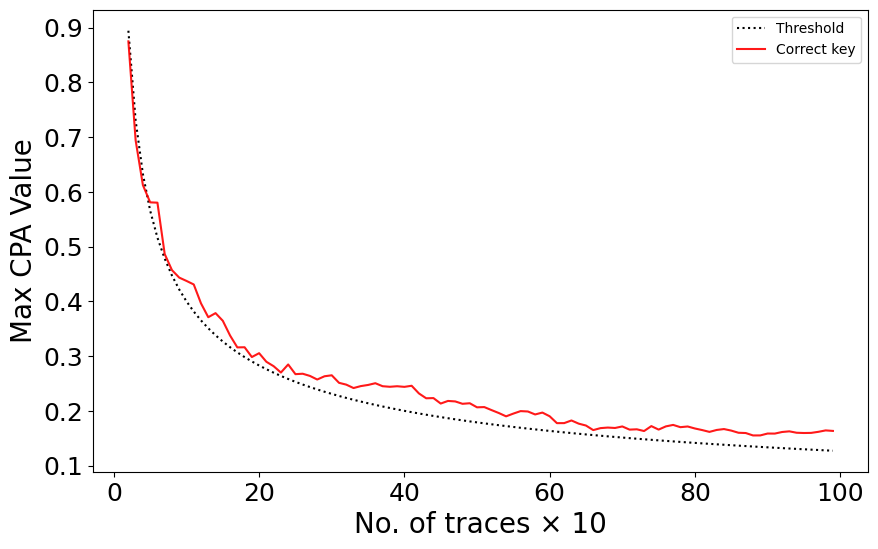

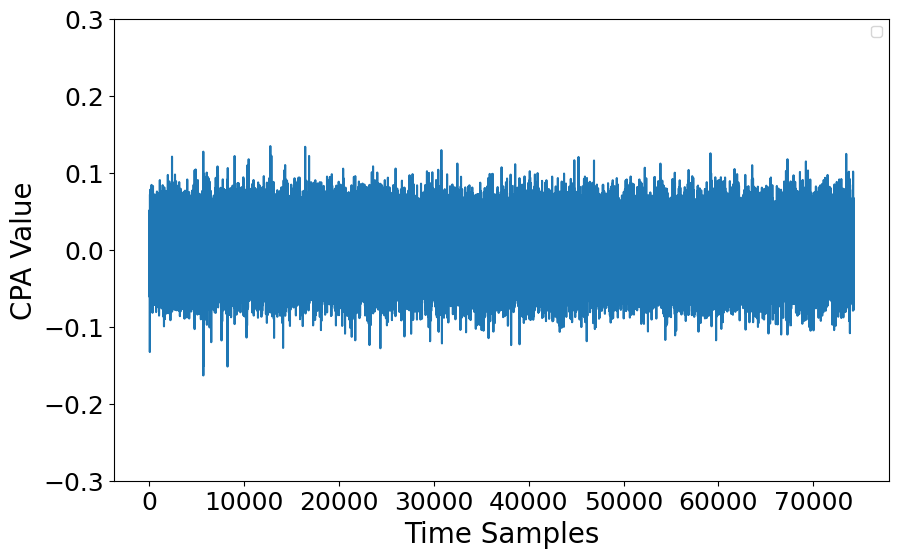

✅ CPA crosses threshold permanently at index 3 (≈ 50 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:09<00:00, 102.01it/s]

8
Shape of maxcpa_matrix: (100, 256)


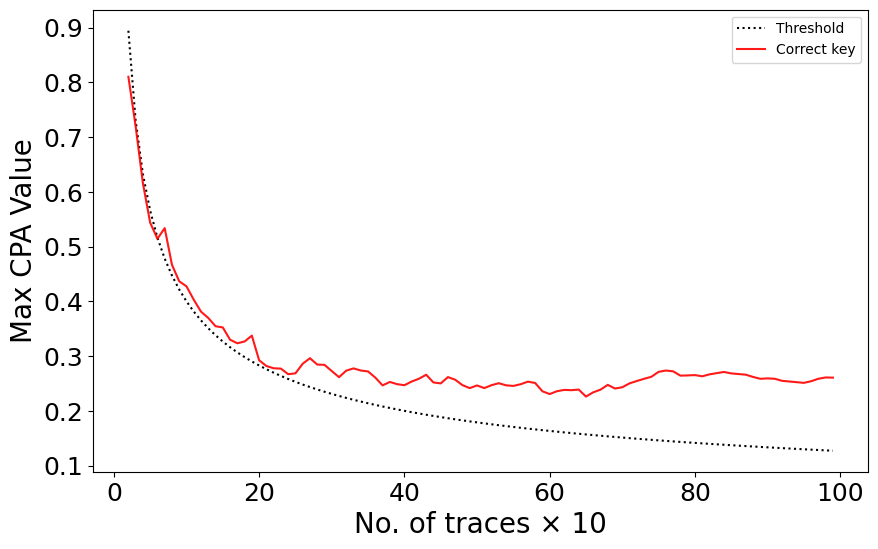

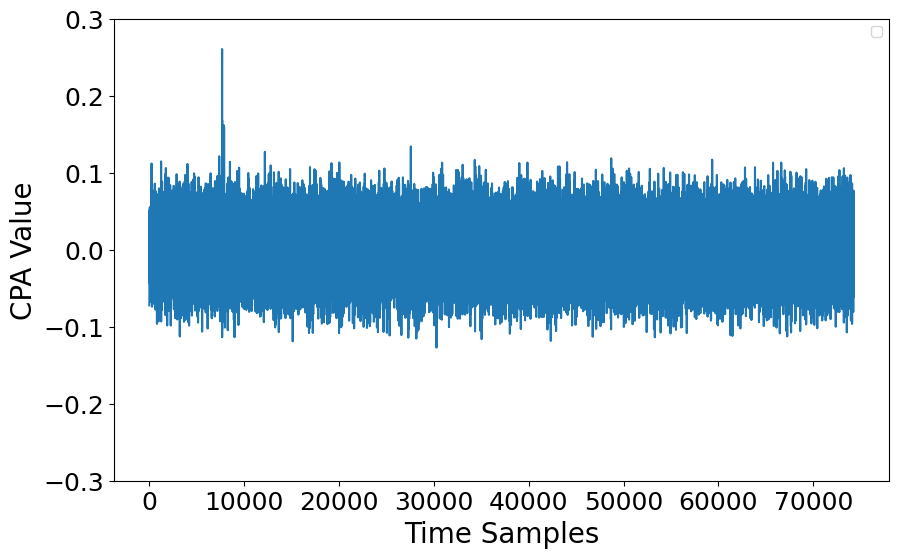

✅ CPA crosses threshold permanently at index 5 (≈ 70 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 100.91it/s]

8
Shape of maxcpa_matrix: (100, 256)


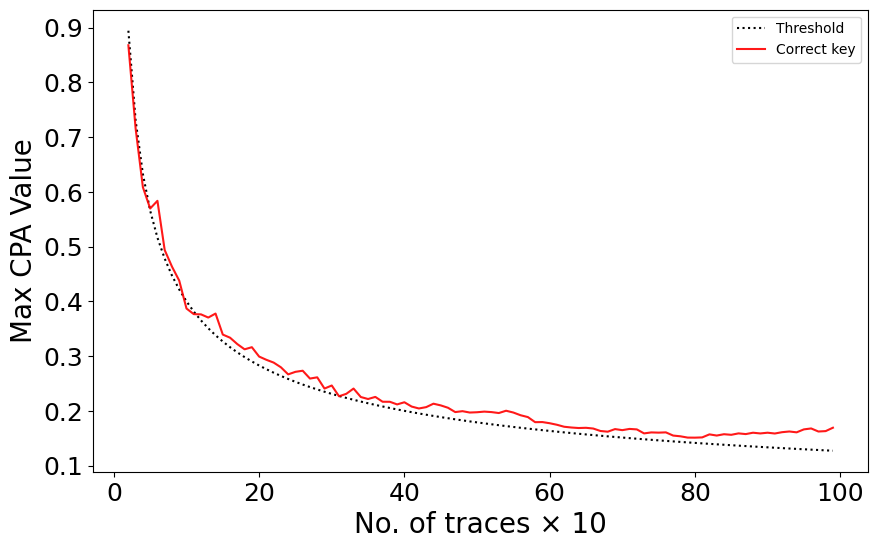

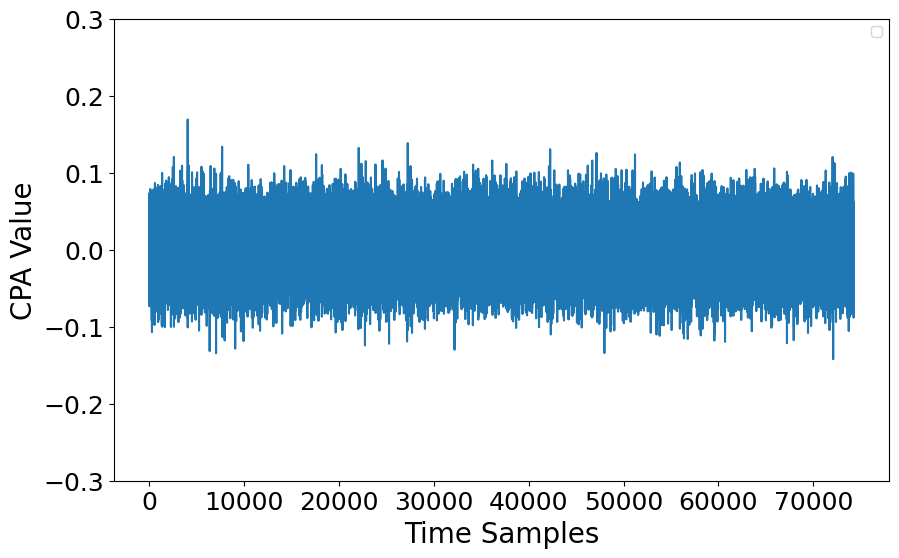

✅ CPA crosses threshold permanently at index 30 (≈ 320 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 97.76it/s] 

8
Shape of maxcpa_matrix: (100, 256)


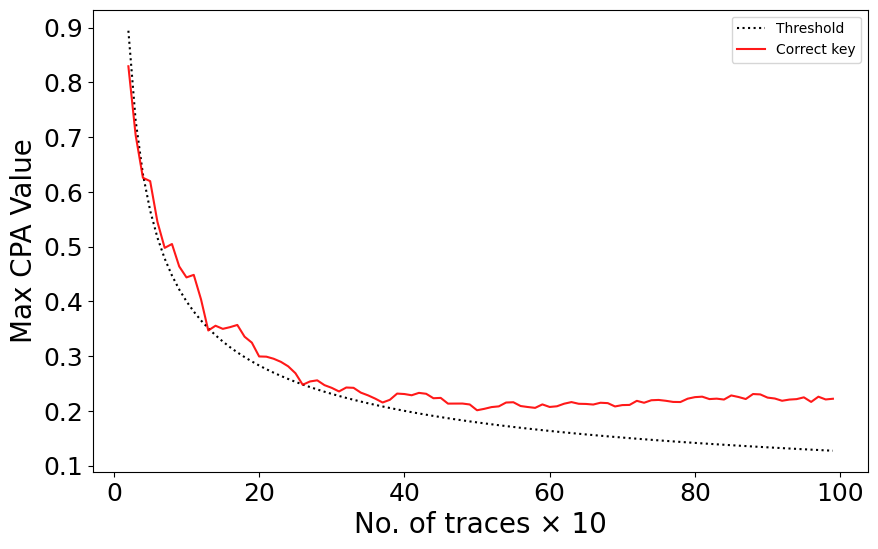

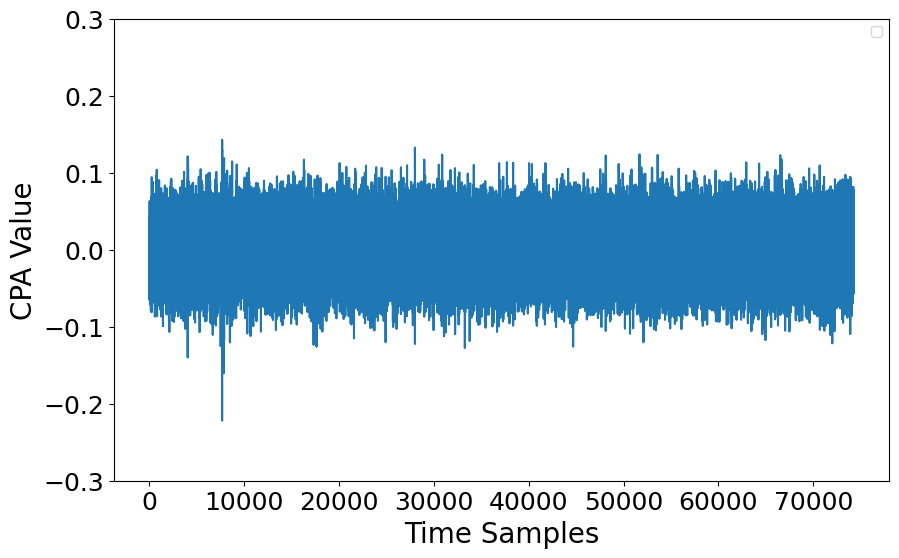

✅ CPA crosses threshold permanently at index 25 (≈ 270 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 99.59it/s] 

9
Shape of maxcpa_matrix: (100, 256)


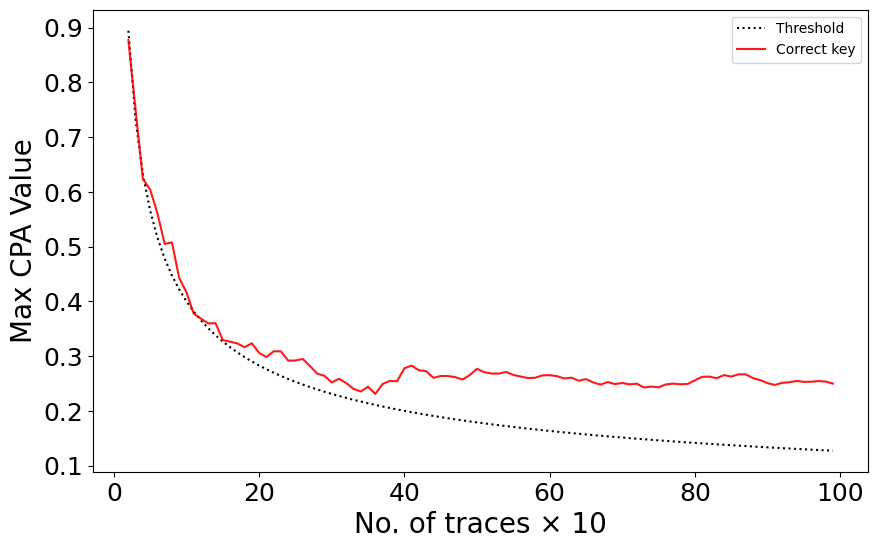

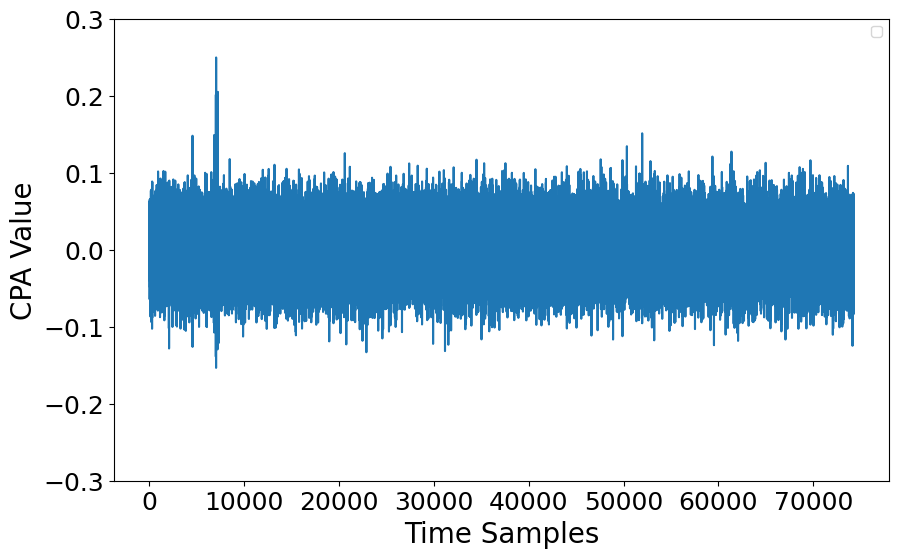

✅ CPA crosses threshold permanently at index 10 (≈ 120 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 104.21it/s]

9
Shape of maxcpa_matrix: (100, 256)


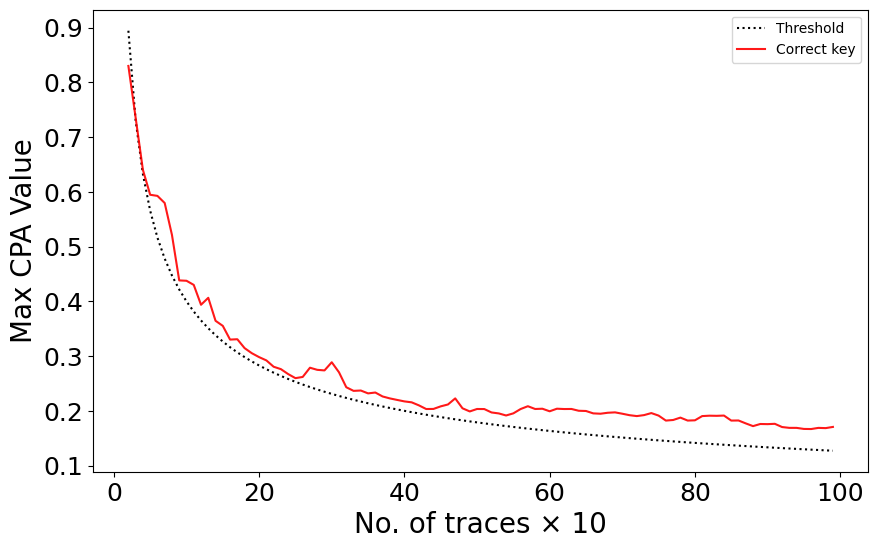

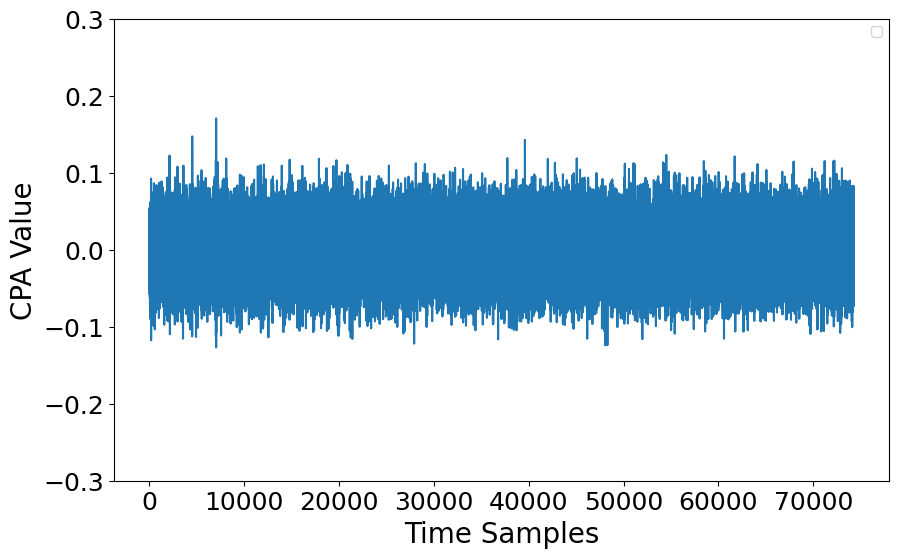

✅ CPA crosses threshold permanently at index 1 (≈ 30 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:09<00:00, 103.41it/s]

9
Shape of maxcpa_matrix: (100, 256)


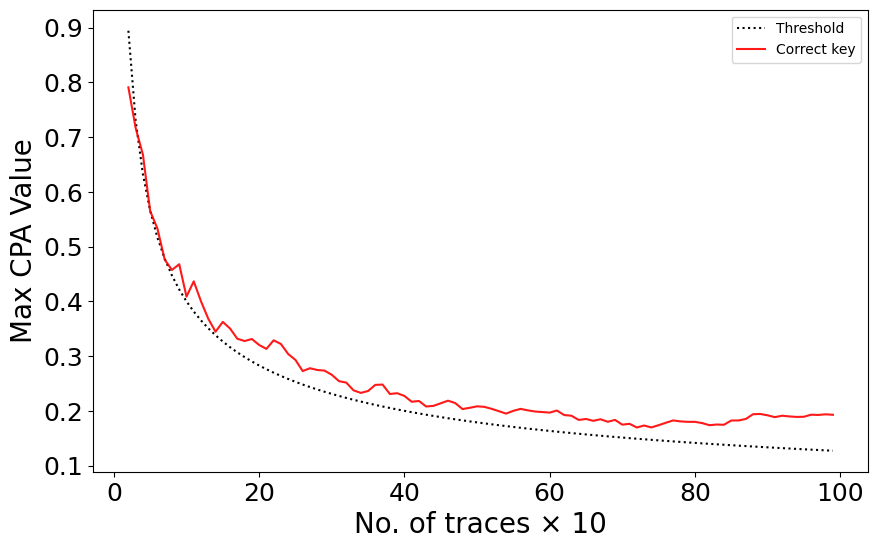

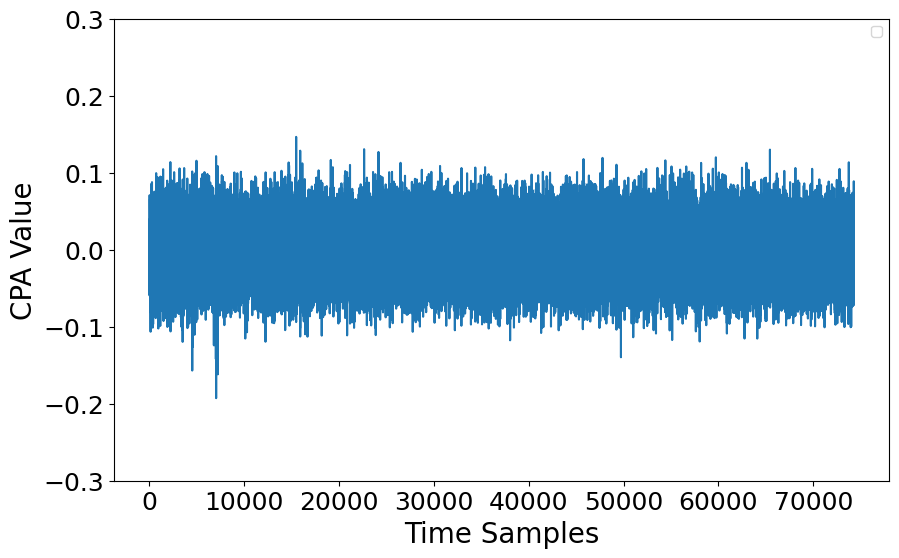

✅ CPA crosses threshold permanently at index 6 (≈ 80 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 97.73it/s] 

10
Shape of maxcpa_matrix: (100, 256)


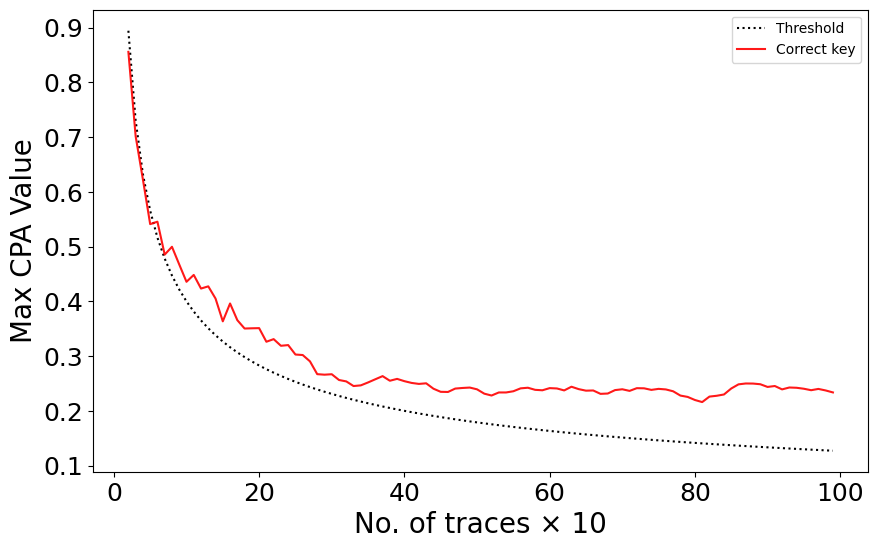

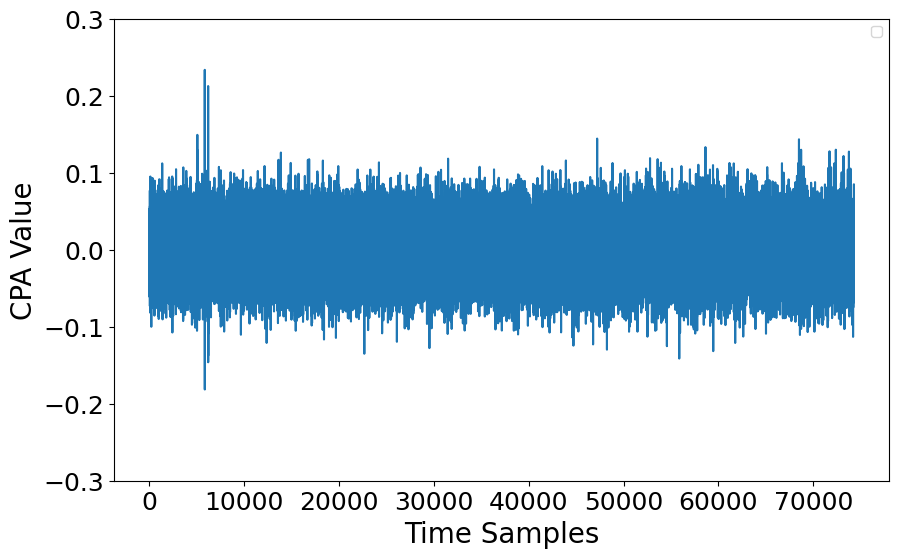

✅ CPA crosses threshold permanently at index 4 (≈ 60 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 101.44it/s]

10
Shape of maxcpa_matrix: (100, 256)


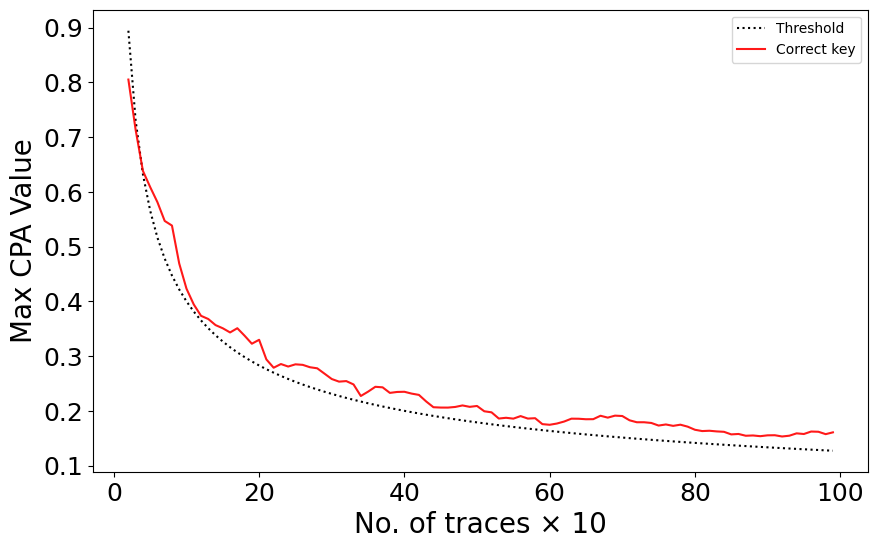

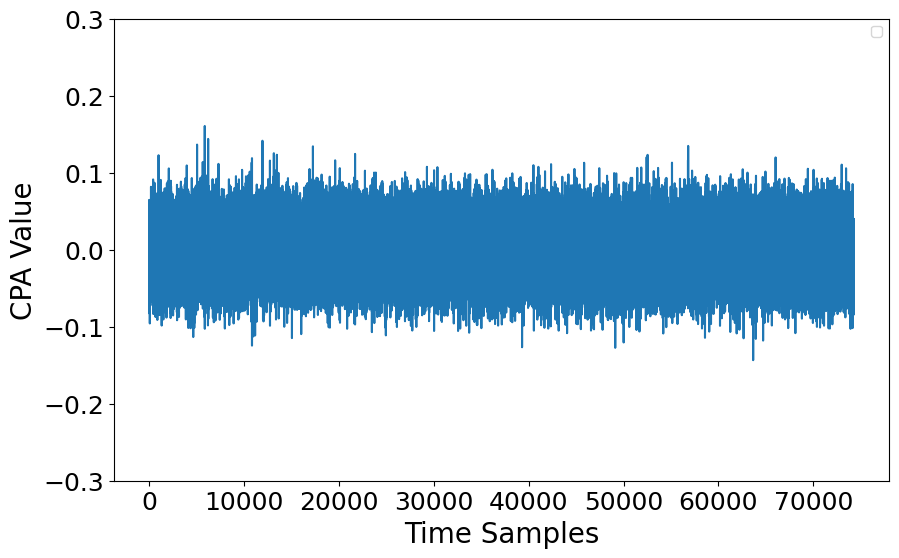

✅ CPA crosses threshold permanently at index 2 (≈ 40 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 96.68it/s] 

10
Shape of maxcpa_matrix: (100, 256)


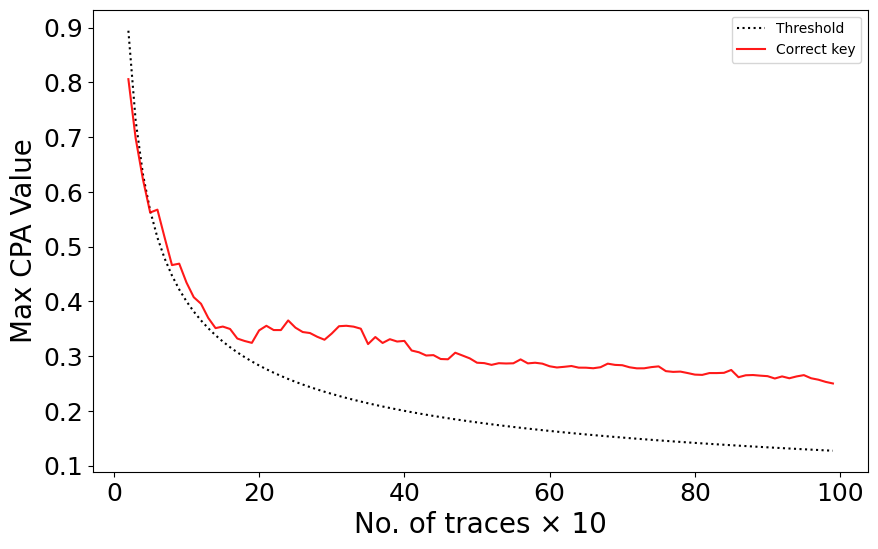

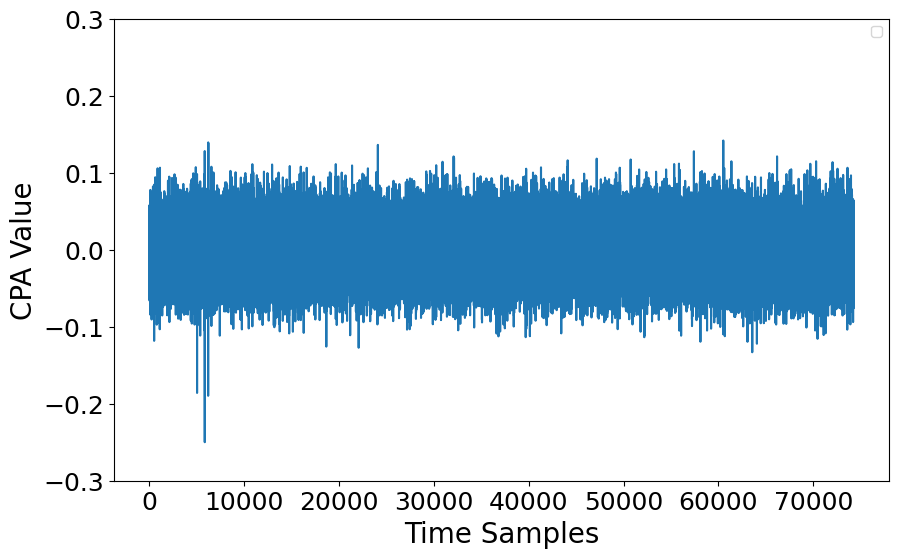

✅ CPA crosses threshold permanently at index 4 (≈ 60 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:09<00:00, 100.12it/s]

11
Shape of maxcpa_matrix: (100, 256)


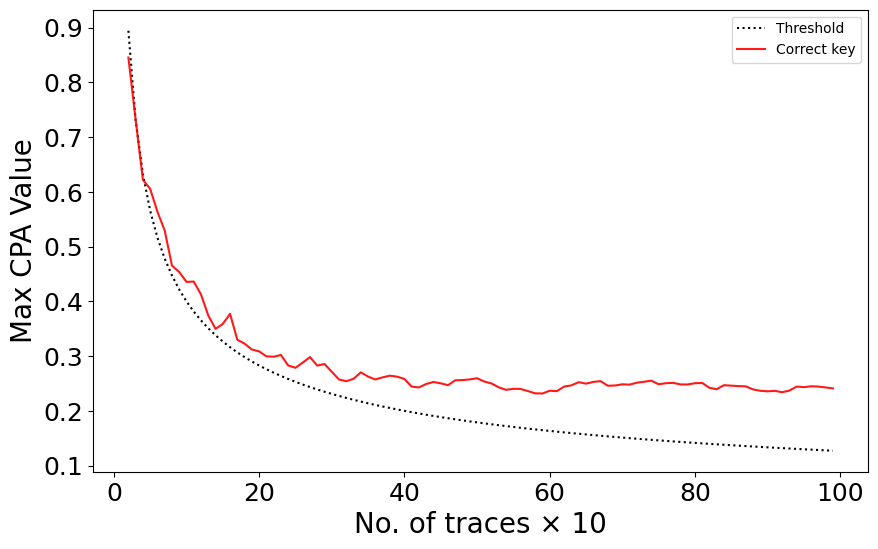

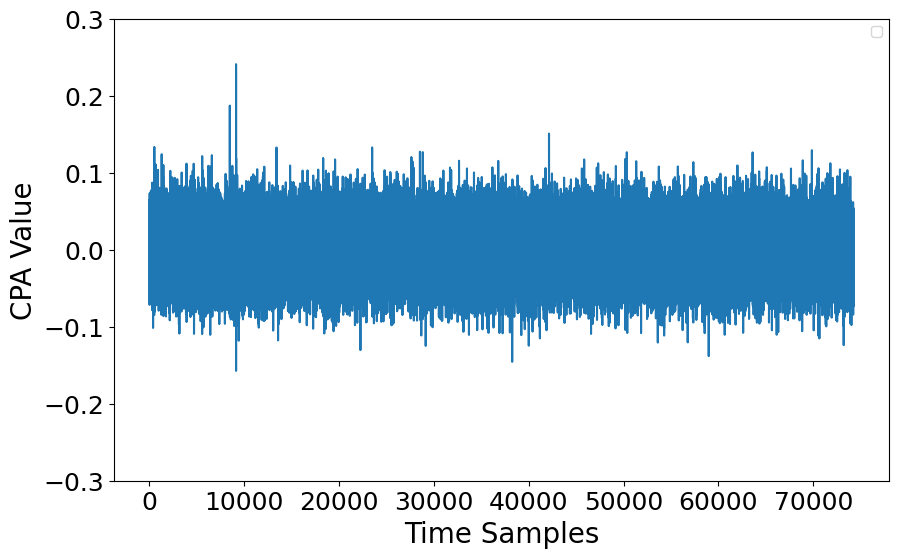

✅ CPA crosses threshold permanently at index 3 (≈ 50 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:09<00:00, 101.00it/s]

11
Shape of maxcpa_matrix: (100, 256)


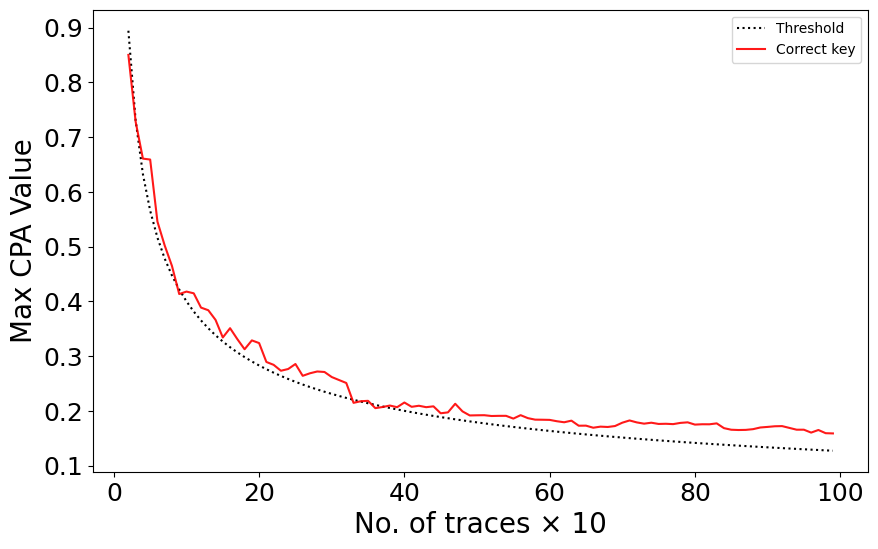

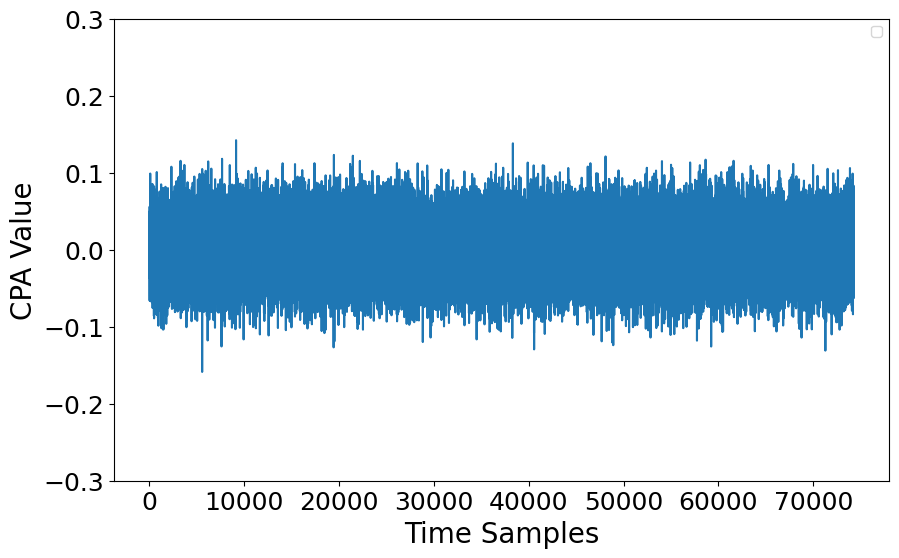

✅ CPA crosses threshold permanently at index 36 (≈ 380 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 97.75it/s] 

11
Shape of maxcpa_matrix: (100, 256)


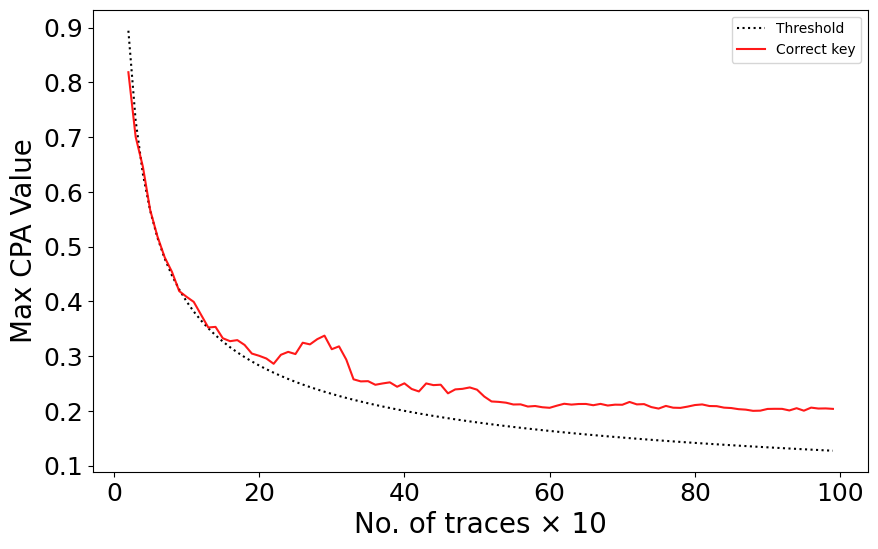

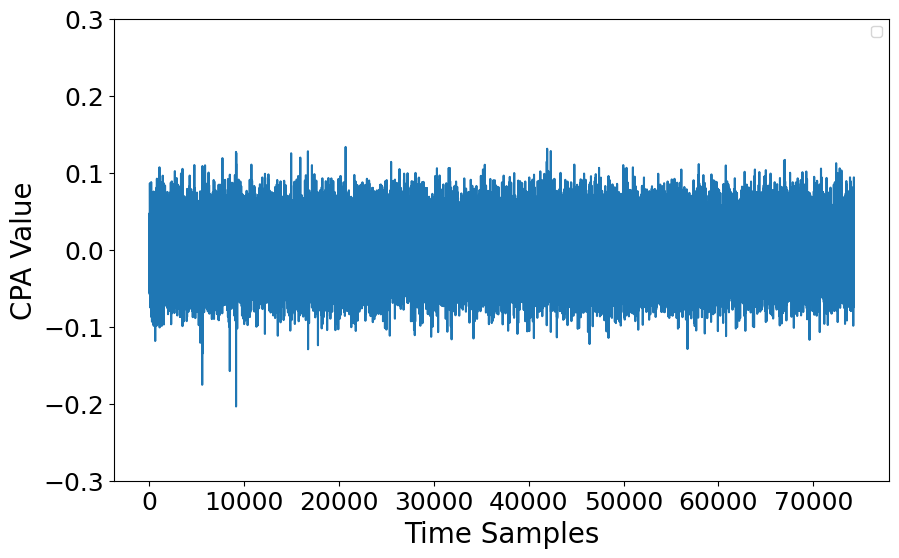

✅ CPA crosses threshold permanently at index 8 (≈ 100 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 98.32it/s] 

12
Shape of maxcpa_matrix: (100, 256)


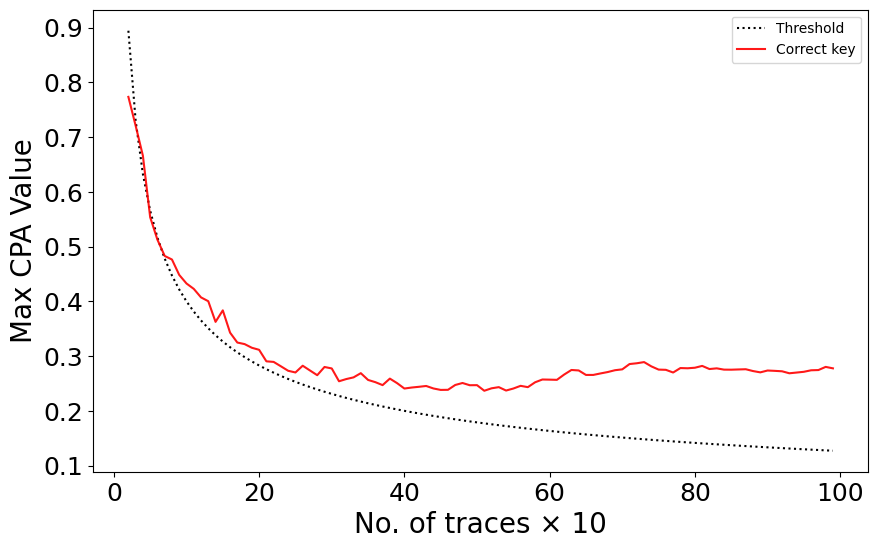

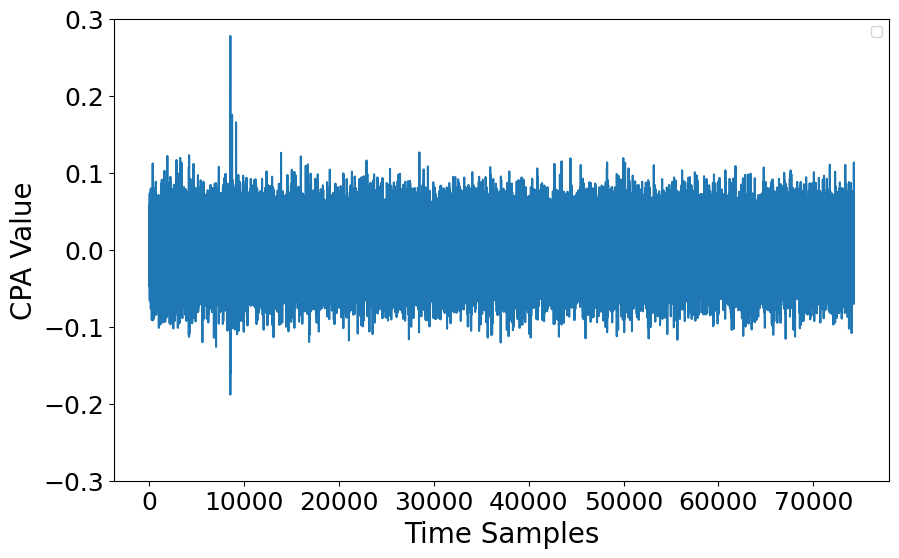

✅ CPA crosses threshold permanently at index 5 (≈ 70 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:10<00:00, 99.00it/s] 

12
Shape of maxcpa_matrix: (100, 256)


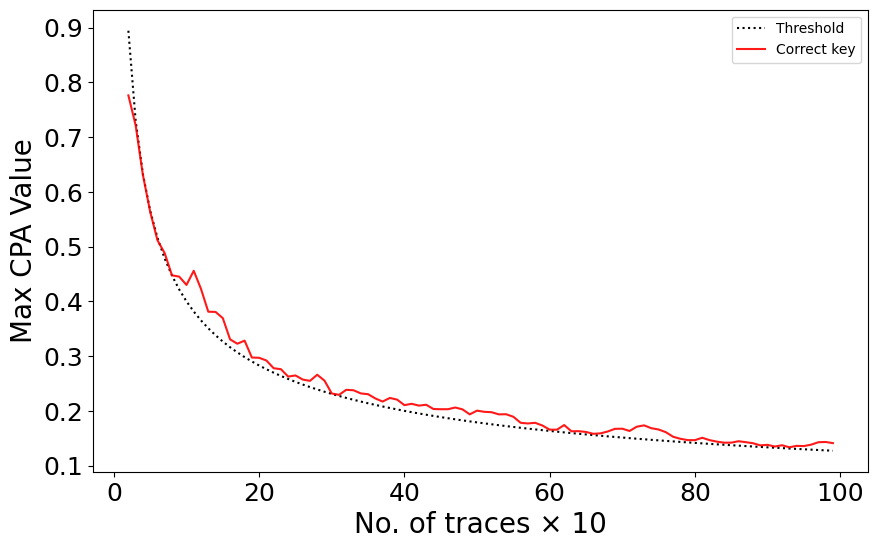

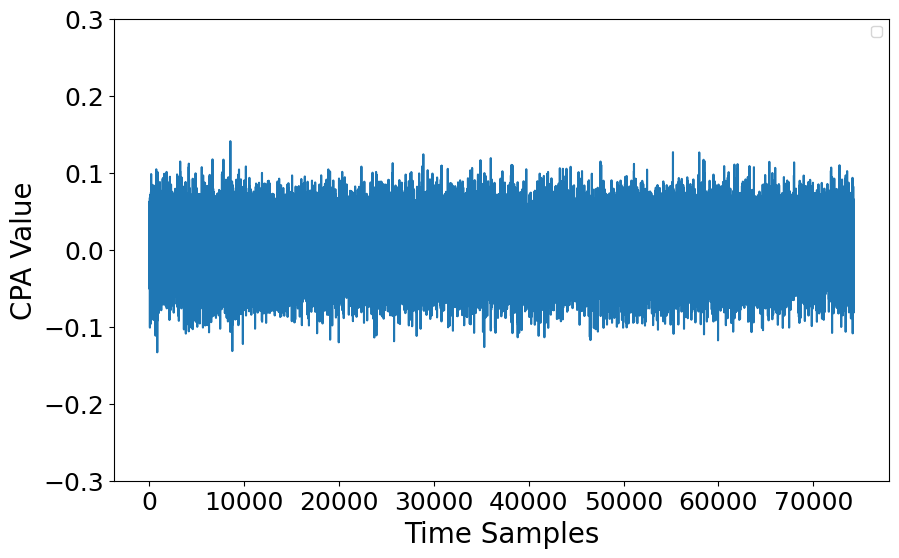

✅ CPA crosses threshold permanently at index 5 (≈ 70 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 95.27it/s] 

12
Shape of maxcpa_matrix: (100, 256)


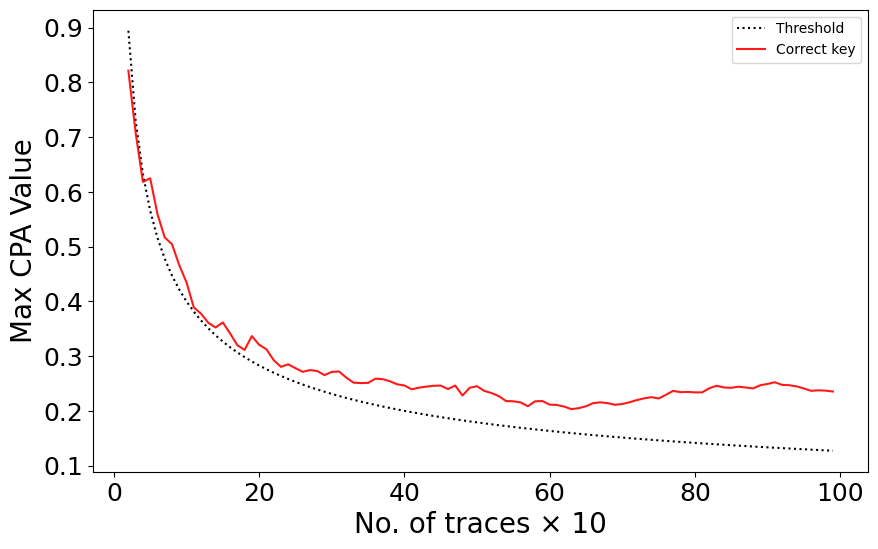

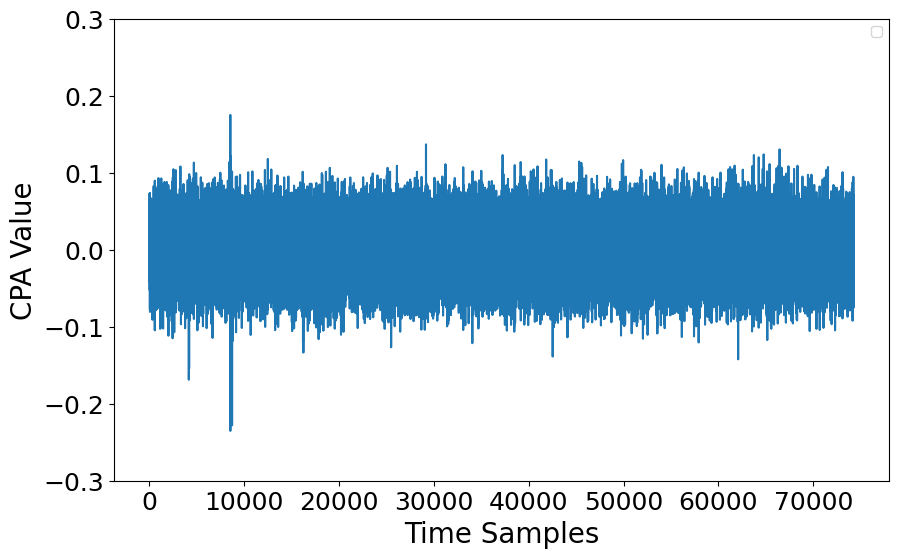

✅ CPA crosses threshold permanently at index 3 (≈ 50 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 99.56it/s] 

13
Shape of maxcpa_matrix: (100, 256)


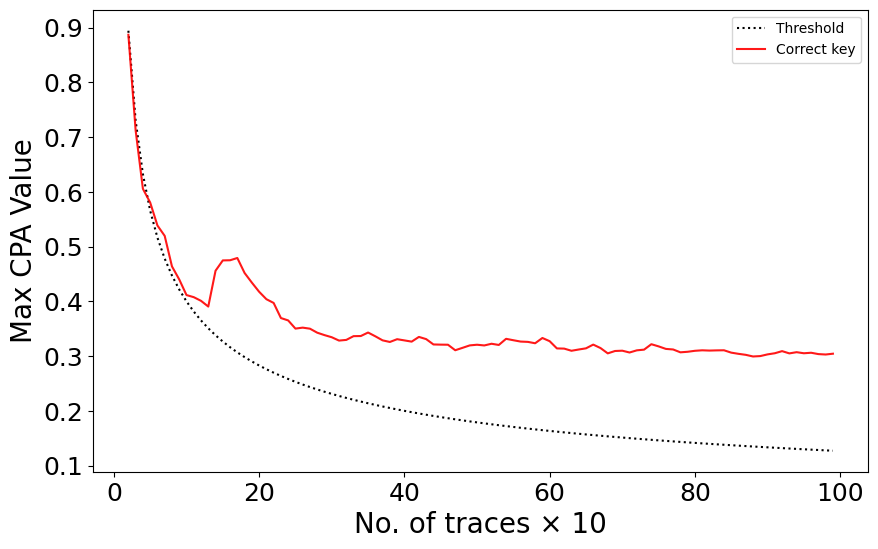

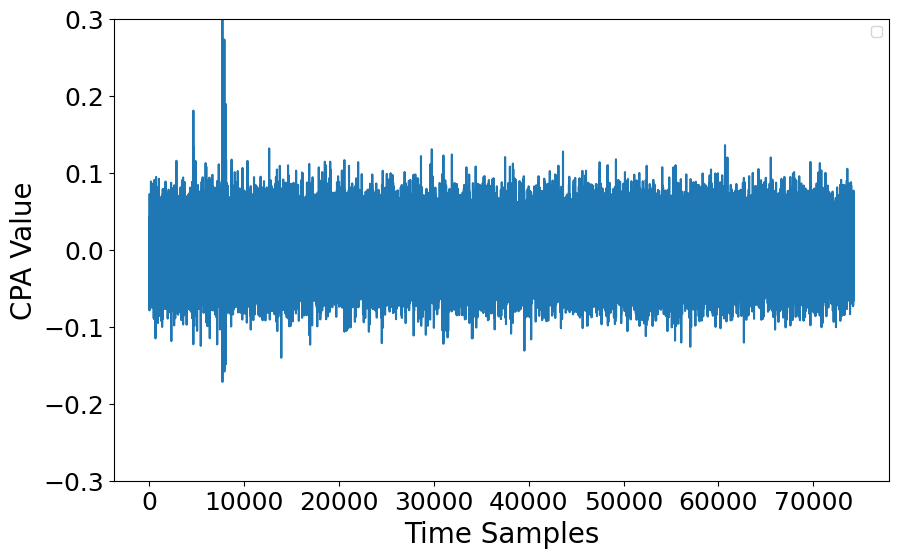

✅ CPA crosses threshold permanently at index 3 (≈ 50 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:10<00:00, 99.73it/s] 

13
Shape of maxcpa_matrix: (100, 256)


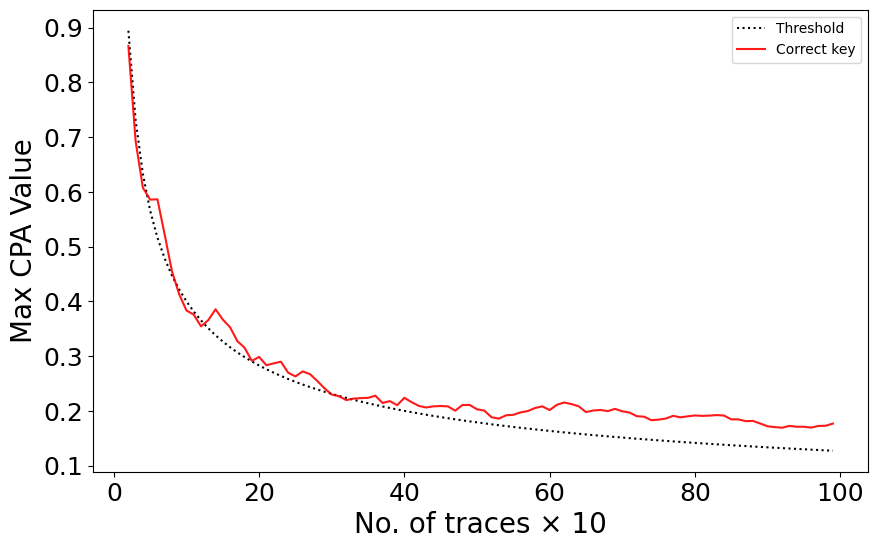

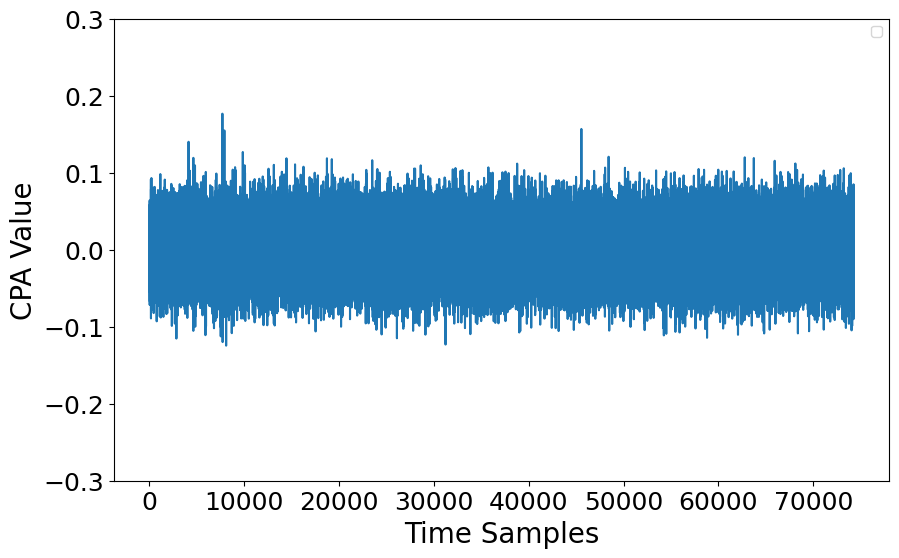

✅ CPA crosses threshold permanently at index 31 (≈ 330 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 94.11it/s] 

13
Shape of maxcpa_matrix: (100, 256)


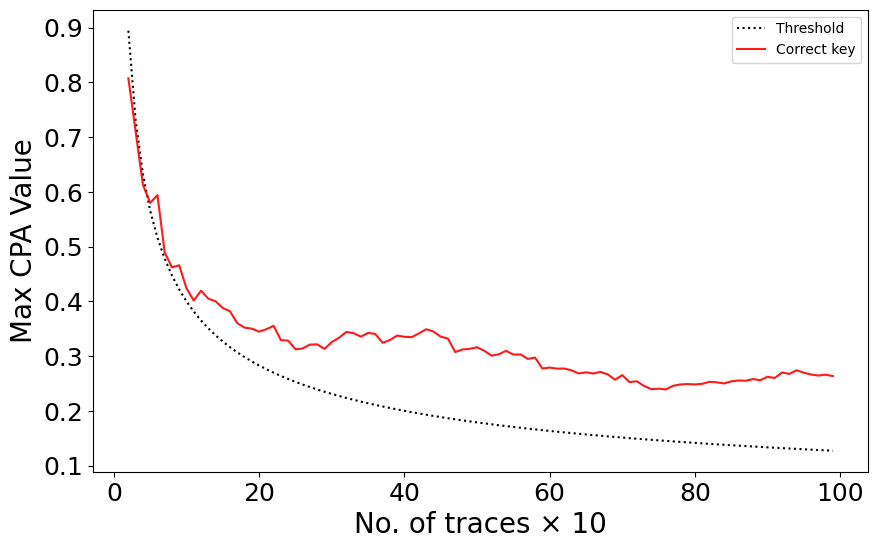

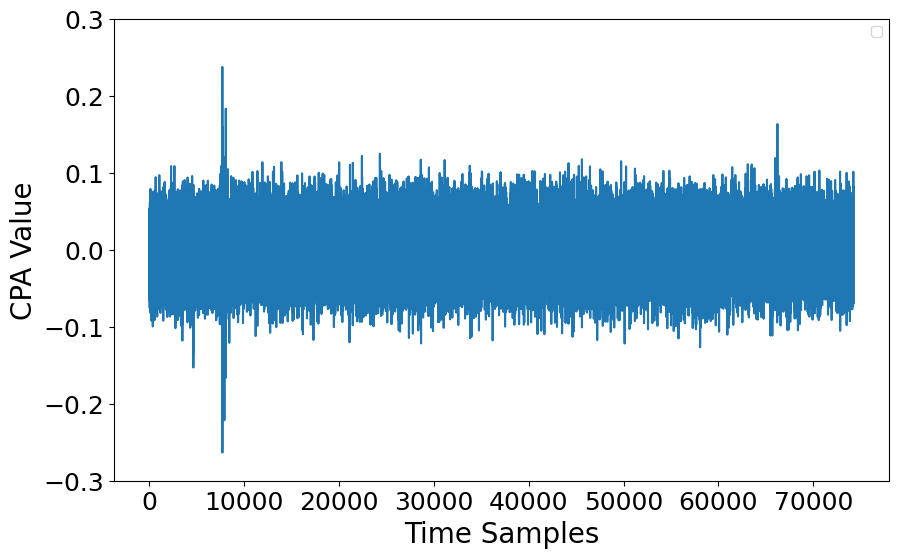

✅ CPA crosses threshold permanently at index 3 (≈ 50 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 97.68it/s] 

14
Shape of maxcpa_matrix: (100, 256)


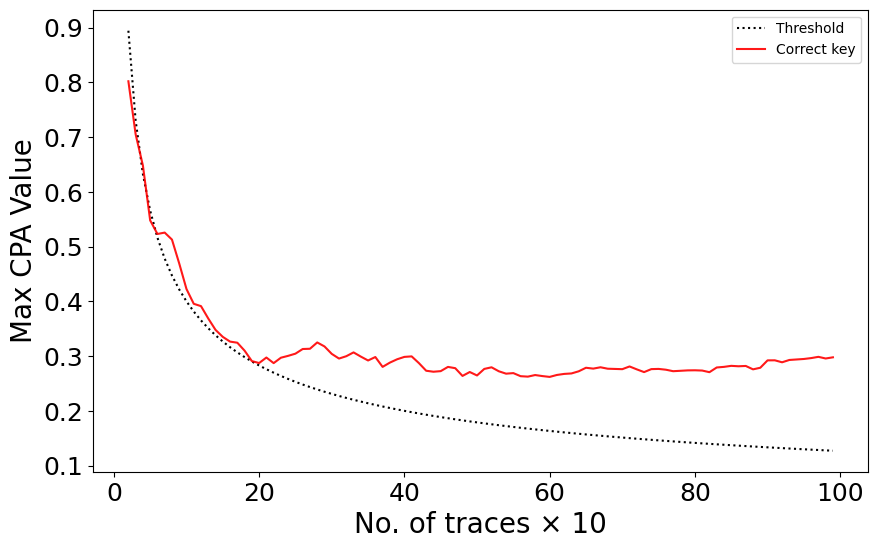

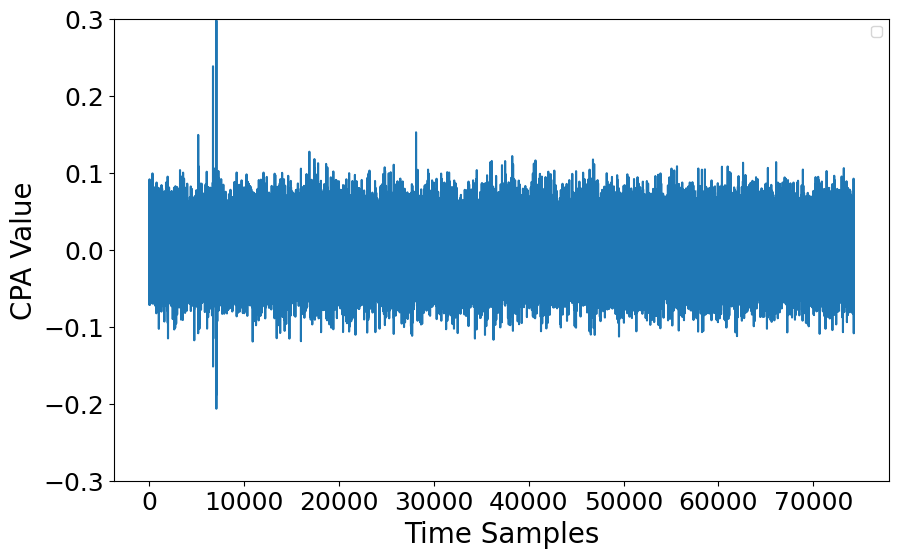

✅ CPA crosses threshold permanently at index 4 (≈ 60 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:10<00:00, 94.84it/s] 

14
Shape of maxcpa_matrix: (100, 256)


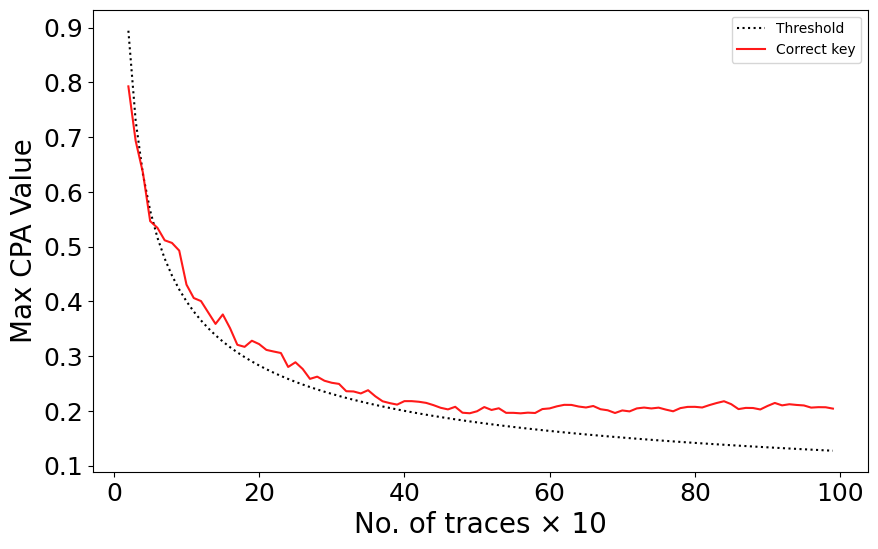

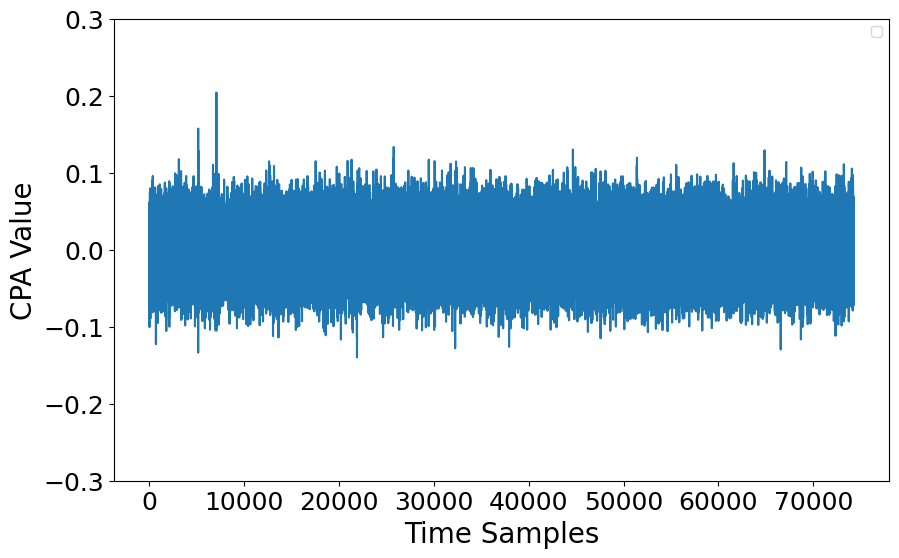

✅ CPA crosses threshold permanently at index 4 (≈ 60 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 99.58it/s] 

14
Shape of maxcpa_matrix: (100, 256)


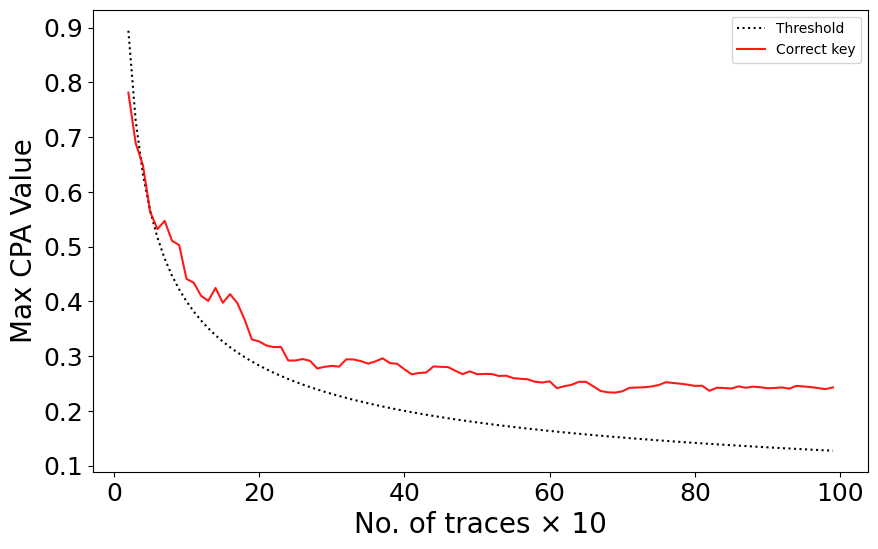

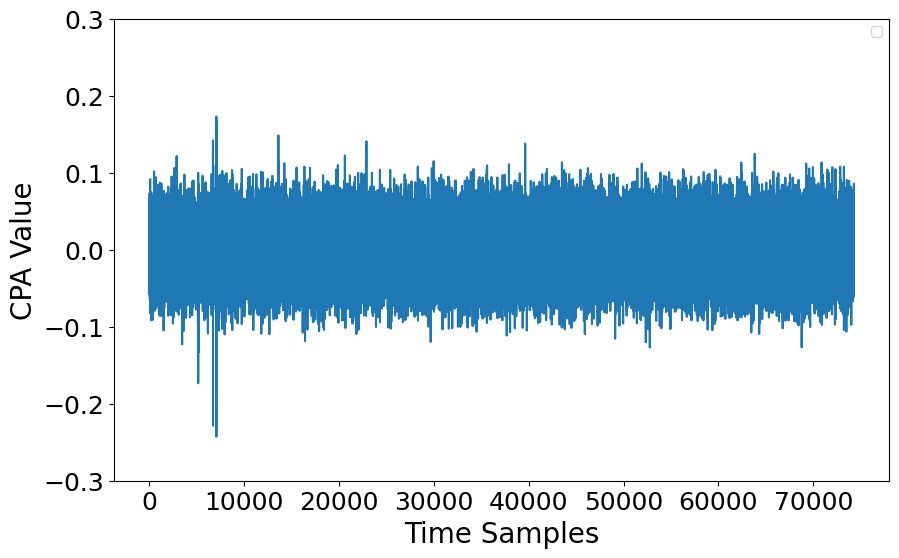

✅ CPA crosses threshold permanently at index 4 (≈ 60 traces)

🔹 Processing coordinate (4, 5) → rotated (5, 4)


100%|██████████| 999/999 [00:10<00:00, 98.87it/s] 

15
Shape of maxcpa_matrix: (100, 256)


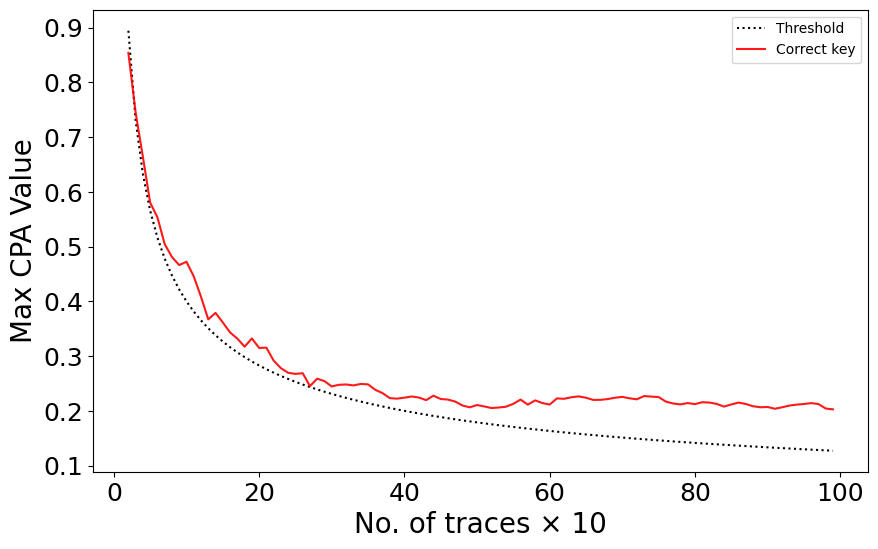

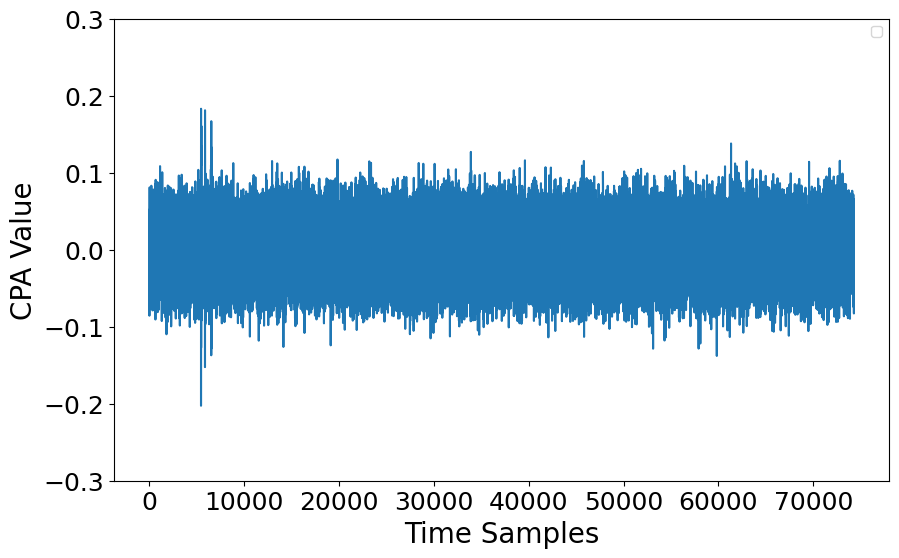

✅ CPA crosses threshold permanently at index 1 (≈ 30 traces)

🔹 Processing coordinate (5, 4) → rotated (6, 5)


100%|██████████| 999/999 [00:10<00:00, 95.40it/s] 

15
Shape of maxcpa_matrix: (100, 256)


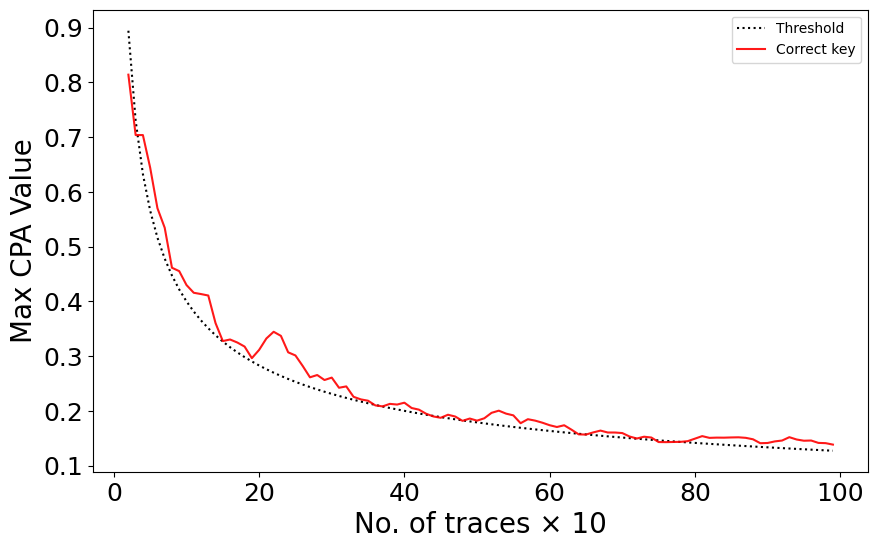

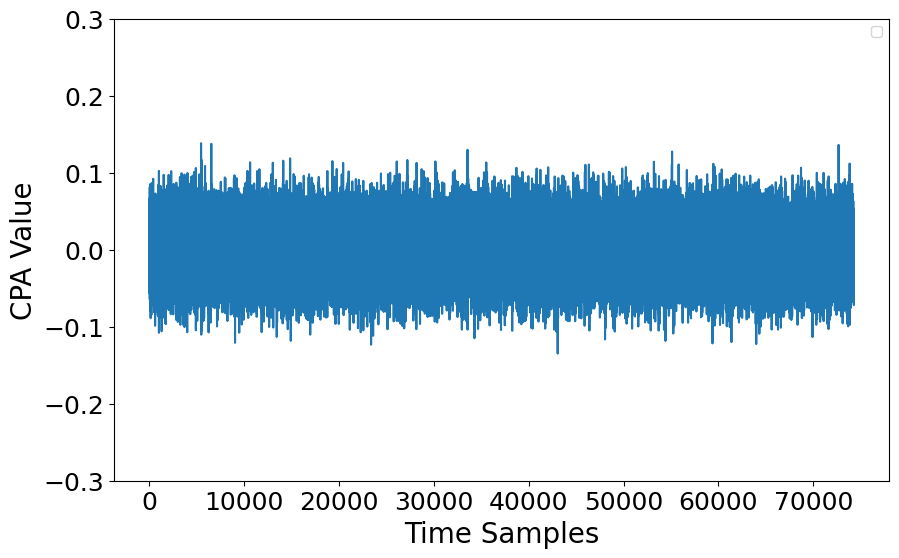

✅ CPA crosses threshold permanently at index 76 (≈ 780 traces)

🔹 Processing coordinate (8, 6) → rotated (4, 8)


100%|██████████| 999/999 [00:10<00:00, 97.94it/s] 

15
Shape of maxcpa_matrix: (100, 256)


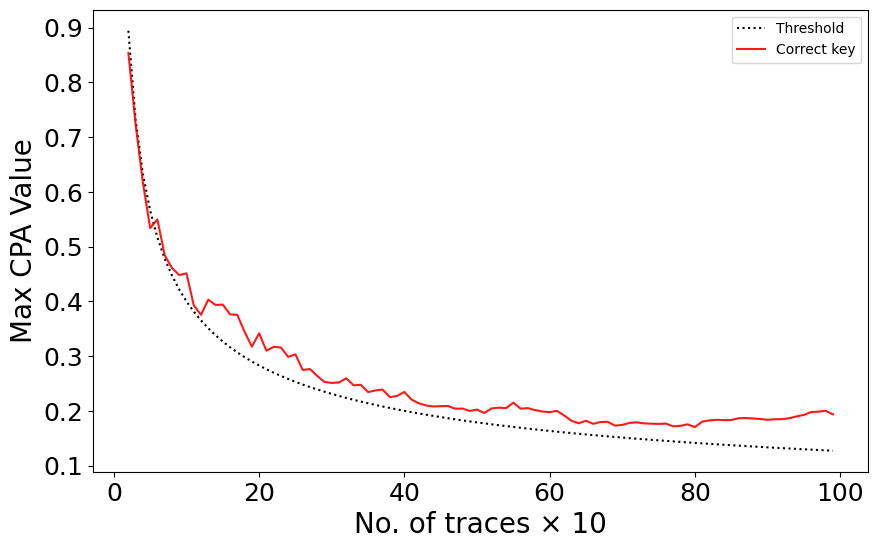

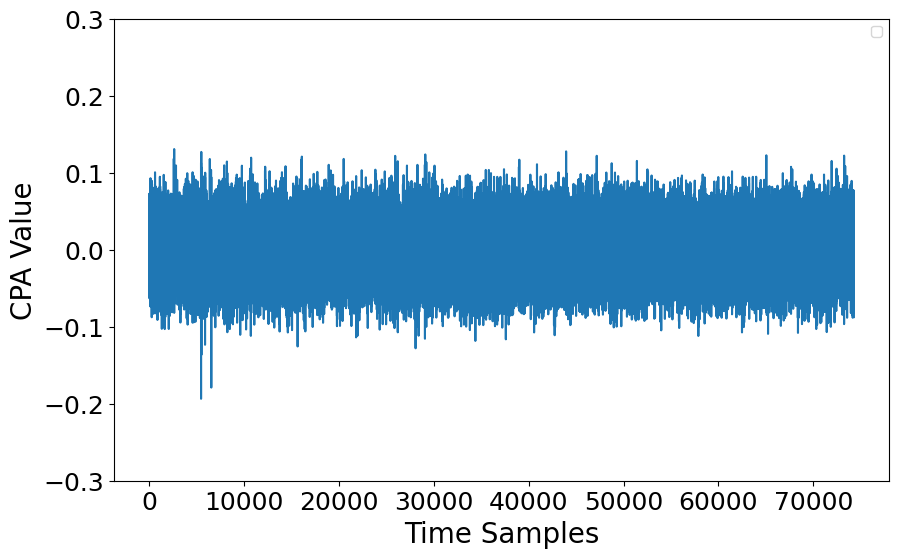

✅ CPA crosses threshold permanently at index 4 (≈ 60 traces)

================ Summary of Minimum Traces per Location ================

X     Y     Rot_i    Rot_j    Min Traces to Cross Byte    
-------------------------------------------------------
4     5     5        4        40                   0       
5     4     6        5        40                   0       
8     6     4        8        90                   0       
4     5     5        4        100                  1       
5     4     6        5        110                  1       
8     6     4        8        90                   1       
4     5     5        4        40                   2       
5     4     6        5        60                   2       
8     6     4        8        140                  2       
4     5     5        4        230                  3       
5     4     6        5        240                  3       
8     6     4        8        60                   3       
4     5     5        4       

In [26]:
grid_size = (11, 11)
n_rot = 3

# List of coordinate pairs to analyze
coords = [(4,5),(5,4),(8,6)]  # example pairs

results = []  # to store summary (x, y, i, j, min_traces)
for byte_i in range(0,16):
    for (x, y) in coords:
        i, j = reverse_coords_ccw(x, y, grid_size, n_rot)
        print(f"\n🔹 Processing coordinate ({x}, {y}) → rotated ({i}, {j})")

        temp_trace = uc_a.get_dataset(f"random_{i}_{j}").read_all()

        m, c, f, min_traces = plot_CEMA_traces_temp(
            temp_trace,
            ptc_5k,
            1000,
            target_byte=byte_i,
            div=10,
            visualize_correct=True,
            model=1,
            r1=6,
            r2=7,
            col_tar='sbb_o'
        )

        results.append((x, y, i, j, min_traces, byte_i))

# --- Print summary table ---
print("\n================ Summary of Minimum Traces per Location ================\n")
print(f"{'X':<5} {'Y':<5} {'Rot_i':<8} {'Rot_j':<8} {'Min Traces to Cross':<20}{'Byte':<8}")
print("-" * 55)
for (x, y, i, j, min_traces,byte_i) in results:
    val = f"{int(min_traces):<20}" if min_traces is not None else "N/A"
    print(f"{x:<5} {y:<5} {i:<8} {j:<8} {val:<20} {byte_i:<8}")
print("\n=======================================================================")



In [465]:
np.save('uc_signal.npy', c)

In [6]:
results_3 = np.load('impl_3_results.npy',allow_pickle=True)

In [13]:
# --- Print summary table ---
print("\n================ Summary of Minimum Traces per Location ================\n")
print(f"{'X':<5} {'Y':<5} {'Rot_i':<8} {'Rot_j':<8} {'Min Traces to Cross':<20}{'Byte':<8}")
print("-" * 55)
for (x, y, i, j, min_traces,byte_i) in results_3:
    if byte_i==13:
        val = f"{int(min_traces):<20}" if min_traces is not None else "N/A"
        print(f"{x:<5} {y:<5} {i:<8} {j:<8} {val:<20} {byte_i:<8}")
print("\n=======================================================================")


================ Summary of Minimum Traces per Location ================

X     Y     Rot_i    Rot_j    Min Traces to Cross Byte    
-------------------------------------------------------
7     1     4        10       320                  13      
8     5     3        6        890                  13      
6     1     5        10       300                  13      
1     3     10       8        860                  13      
2     7     9        4        N/A                  13      
7     4     4        7        950                  13      
6     9     5        2        610                  13      
8     6     3        5        N/A                  13      
7     8     4        3        380                  13      
7     5     4        6        N/A                  13      
11    7     0        4        N/A                  13      



In [71]:
x=4
y=4
grid_size = (11,11)
n_rot=3


i,j = reverse_coords_ccw(x,y,grid_size,n_rot)

In [309]:
keys = ptc_5k.get_dataset("keys").read_data(0, num)
plaintexts = ptc_5k.get_dataset("plaintexts").read_data(0, num)

c = AES(keys[0])

labels = hd_cpa_last_round(plaintext=plaintexts,num_traces=1000,c=c,target_byte=13,r1=6,r2=7)
np.save('labels_13.npy', labels)

## Scapegoat paths

In [3]:

# pt = emsca.get_experiment("pt_keys")
# keys_pt = pt.get_dataset("keys").read_data(0,10000)
# random_pt = pt.get_dataset("plaintexts").read_data(0,10000)
# fixed_pt = pt.get_dataset("fixed_pt").read_data(0,10000)

In [ ]:
# #new experimetns and datasets
# ptc_5x10k = emsca.add_experiment("pt_keys_5kx10_rambus")

# ptc_5x10k.add_dataset("keys",key_5k,datatype="uint8")
# ptc_5x10k.add_dataset("plaintexts",rpt_5k,datatype="uint8")
# ptc_5x10k.add_dataset("fixed_pt",pt_5k,datatype="uint8")

In [4]:
# ptc_5k = emsca.get_experiment('pt_keys_5k_rambus')
# keys_pt = ptc_5k.get_dataset("keys").read_data(0,30000)
# random_pt = ptc_5k.get_dataset("plaintexts").read_data(0,30000)
# fixed_pt = ptc_5k.get_dataset("fixed_pt").read_data(0,30000)

In [483]:
# Retrieve keys and plaintext datasets
num = 1000
keys = ptc_5k.get_dataset("keys").read_data(0, num)
plaintexts = ptc_5k.get_dataset("plaintexts").read_data(0, num)
x=8
y=2
grid_size = (11,11)
n_rot=2


i,j = reverse_coords_ccw(x,y,grid_size,n_rot)
c = AES(keys[0])

labels = hd_cpa_last_round(plaintext=plaintexts,num_traces=num,c=c,target_byte=13,r1=6,r2=7)
traces = uc_t.get_dataset(f"random_{i}_{j}").read_data(0, num)
traces = traces[:100]

snr_result = calculate_MI_EM_percell(traces,labels[:100],alpha=1.01,normalize= False,nystrom=False,m_l=1)        
print(snr_result)

running modified code for experiments
tensor(5.8350)


In [484]:
traces.shape

(100, 74280)

In [ ]:
#with nystrom I, Hx, Hxy
# location 0, 8 - 6.2377577 9.179542 6.108467
# location 5,5 - 6.297878 8.957923 5.8267283



#without nystrom 
# location 0, 8 - 6.1679945 9.179542 6.1814737
# location 5,5 - 7.3162637 8.842049 4.6957126
# location 8,2 - 9.272923 8.982191 2.8791955

In [317]:
variances = np.var(traces, axis=0)

mask = variances >1e-6
traces = traces[:, mask]
observations_at_time = traces
o = traces


h = np.array(labels, dtype=int)

x = torch.tensor(o, dtype=torch.float32)
y = torch.tensor(h, dtype=torch.float32)


sigma_x = get_sigma(traces.shape[1],1000,torch.std(x) )
sigma_y = get_sigma(1,1000,torch.std(y) )
mio = calculate_MI(x , y,1.01, sigma_x,sigma_y,False)

    

In [13]:
variances = np.var(traces, axis=0)
epsilon =1e-2

mask = variances >0.001
traces = traces[:, mask]
observations_at_time = traces
o = traces

# sigma_x = median_heuristic(traces)
sigma_x = 1.9813067


# h = np.array(labels, dtype=int)

x = torch.tensor(o, dtype=torch.float32)
# sigma_x = get_sigma(traces.shape[1],1000,torch.std(x) )


k = calculate_gram_mat(x,sigma_x)
k.add(epsilon)

k = k/torch.trace(k)
eigv, _ = torch.linalg.eigh(k, UPLO='U')  # or 'L' if you want the lower part
eigv = torch.abs(eigv)

In [14]:
def effective_rank_from_eigvals(evals):
    """
    Participation-ratio effective rank:
        r_eff = (sum λ)^2 / sum λ^2
    """
    lam = np.asarray(evals, dtype=float)
    lam = lam[lam > 0]  # ignore non-positives (numerical noise)
    if lam.size == 0:
        return 0.0
    s1 = lam.sum()
    s2 = np.sum(lam*lam)
    return float((s1*s1) / s2)

In [15]:
 effective_rank_from_eigvals(eigv)

45.495656795556606

In [16]:
max_iter = 20
sigma_x = 1.9813067
threshold = 1000

for _ in range(max_iter):
        # Gaussian kernel with the "2*sigma^2" convention
        k = calculate_gram_mat(x,sigma_x)
        k = k/torch.trace(k)
        
        
        eigv, _ = torch.linalg.eigh(k, UPLO='U')  # or 'L' if you want the lower part
        eigv = torch.abs(eigv)
        r_eff = effective_rank_from_eigvals(eigv)
        print(f"{r_eff:.2f}, {sigma_x:.2f}")


        if r_eff >= threshold:
            break
        sigma_x *= 1.5



45.50, 1.98
13.34, 2.97
5.72, 4.46
3.22, 6.69
2.19, 10.03
1.69, 15.05
1.42, 22.57
1.26, 33.85
1.17, 50.78
1.11, 76.17
1.07, 114.25
1.05, 171.38
1.03, 257.07
1.02, 385.60
1.01, 578.40
1.01, 867.60
1.01, 1301.40
1.00, 1952.10
1.00, 2928.16
1.00, 4392.24


In [17]:
sigma_x

6588.353438526905

In [18]:
sigma_x

6588.353438526905

In [19]:
k

tensor([[0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010],
        [0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010],
        [0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010],
        ...,
        [0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010],
        [0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010],
        [0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010]])

In [171]:
k = np.array(k)

In [21]:
sigma_x

6588.353438526905

In [172]:
eigv = np.array(eigv)

In [22]:
import numpy as np

def is_symmetric(A, tol=1e-12):
    A = np.asarray(A)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        return False
    # rtol=0 to use absolute tolerance only; equal_nan=True treats NaNs as equal
    return np.allclose(A, A.T, rtol=0, atol=tol, equal_nan=True)

def is_hermitian(A, tol=1e-12):
    """Use this for complex matrices."""
    A = np.asarray(A)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        return False
    return np.allclose(A, A.conj().T, rtol=0, atol=tol, equal_nan=True)

In [23]:
is_symmetric(k)

True

In [174]:
eigv

array([0.00036257, 0.00037083, 0.00038506, 0.00038839, 0.00038944,
       0.00039223, 0.00039402, 0.00039531, 0.00039633, 0.00039687,
       0.00039771, 0.00039929, 0.00039983, 0.00040047, 0.00040214,
       0.0004029 , 0.00040344, 0.00040441, 0.00040576, 0.00040746,
       0.00040819, 0.00040873, 0.00040969, 0.00041014, 0.00041046,
       0.00041088, 0.00041189, 0.00041337, 0.00041446, 0.00041517,
       0.00041545, 0.00041584, 0.00041683, 0.00041707, 0.0004178 ,
       0.0004187 , 0.00041886, 0.0004197 , 0.00042084, 0.00042136,
       0.00042181, 0.00042299, 0.00042315, 0.00042359, 0.00042413,
       0.00042473, 0.00042505, 0.00042614, 0.00042674, 0.00042732,
       0.00042771, 0.00042831, 0.00042867, 0.00042993, 0.00043064,
       0.00043171, 0.00043206, 0.0004325 , 0.00043295, 0.00043333,
       0.00043382, 0.00043408, 0.00043481, 0.00043536, 0.00043578,
       0.00043592, 0.00043604, 0.00043741, 0.00043798, 0.00043899,
       0.00043925, 0.00043944, 0.00043948, 0.0004402 , 0.00044

In [164]:
np.savetxt("eigv_mh.csv", eigv, delimiter=",", fmt="%.7f")


In [57]:
eigv.shape

(1000,)

In [24]:
def median_heuristic(X):
    """
    Compute sigma using the median heuristic.
    
    Parameters
    ----------
    X : ndarray of shape (n, d)
        Input data, n samples in d dimensions.
    
    Returns
    -------
    sigma : float
        Median heuristic bandwidth parameter.
    """
    X = np.asarray(X)
    n = X.shape[0]

    # Compute pairwise squared distances
    diff = X[:, None, :] - X[None, :, :]
    D2 = np.sum(diff**2, axis=2)

    # Take only the upper triangle (i<j) to avoid duplicates/zeros
    iu = np.triu_indices(n, k=1)
    sigma = np.sqrt(np.median(D2[iu]))
    return sigma

In [152]:
median_heuristic(traces)

1.9813067

In [25]:
# test of the dynamic sigma allocating

import numpy as np
from scipy.spatial.distance import cdist
from numpy.linalg import eigh
import matplotlib.pyplot as plt

def median_heuristic(X):
    """
    Compute sigma using the median heuristic.
    
    Parameters
    ----------
    X : ndarray of shape (n, d)
        Input data, n samples in d dimensions.
    
    Returns
    -------
    sigma : float
        Median heuristic bandwidth parameter.
    """
    X = np.asarray(X)
    n = X.shape[0]

    # Compute pairwise squared distances
    diff = X[:, None, :] - X[None, :, :]
    D2 = np.sum(diff**2, axis=2)

    # Take only the upper triangle (i<j) to avoid duplicates/zeros
    iu = np.triu_indices(n, k=1)
    sigma = np.sqrt(np.median(D2[iu]))
    return sigma

def effective_rank(K):
    """Effective rank = (sum λ)^2 / sum λ^2, using symmetric eigendecomp."""
    # eigh for symmetric matrices; ensure numerical non-negativity
    w = eigh(0.5*(K+K.T), UPLO='L')[0]
    w = np.clip(w, 0.0, None)
    s1 = np.sum(w)
    s2 = np.sum(w**2)
    return (s1**2 / s2) if s2 > 0 else 0.0

def moving_average(x, k=3):
    """Simple centered moving average (odd k). Falls back to same length."""
    if k <= 1 or k % 2 == 0:
        return x
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode='edge')
    kernel = np.ones(k) / k
    return np.convolve(xp, kernel, mode='valid')



X = traces
m = X.shape[0]

# 1) pairwise squared distances
D2 = cdist(X, X, metric='euclidean')**2

# 2) median heuristic for base sigma
upper = D2[np.triu_indices(m, k=1)]
sigma0 = np.sqrt(np.median(upper)) if upper.size > 0 else 1.0

# 3) sweep σ

span_low = 1/3
span_high = 10
n_sigma = 20


sigmas = np.logspace(np.log10(sigma0*span_low),
                     np.log10(sigma0*span_high),
                     num=n_sigma)

eff_ranks = np.zeros_like(sigmas)
MI_vals   = np.zeros_like(sigmas)




#     # 4) loop: build kernels, effective rank, MI via user function
#     for i, sigma in enumerate(sigmas):
#         Kx = rbf_kernel_from_d2(D2, sigma, normalize=True)
#         eff_ranks[i] = effective_rank(Kx)

#         # call user's MI function (no implementation here)
#         MI_vals[i] = float(mi_func(Kx, Ky, alpha))

#     # 5) smooth curves for stability (keeps same length)
#     rank_smooth = moving_average(eff_ranks, k=smooth_k)
#     MI_smooth   = moving_average(MI_vals,   k=smooth_k)

#     # 6) detect elbow in effective rank (2nd derivative of log rank)
#     #    use small epsilon to avoid log(0)
#     eps = 1e-12
#     d1 = np.gradient(np.log(rank_smooth + eps))
#     d2 = np.gradient(d1)
#     elbow_idx = int(np.argmin(d2))  # most negative curvature

#     # 7) pick σ near MI peak but not past the elbow
#     mi_peak_idx = int(np.argmax(MI_smooth))
#     sigma_opt_idx = min(elbow_idx, mi_peak_idx)
#     sigma_opt = float(sigmas[sigma_opt_idx])

#     # 8) final kernel and metrics
#     K_opt = rbf_kernel_from_d2(D2, sigma_opt, normalize=True)
#     eff_rank_opt = effective_rank(K_opt)
#     MI_opt = float(MI_vals[sigma_opt_idx])

#     if make_plots:
#         # plot MI and effective rank vs sigma (log-x)
#         plt.figure(figsize=(10, 6))
#         # MI
#         plt.subplot(2, 1, 1)
#         plt.semilogx(sigmas, MI_vals, marker='o')
#         plt.axvline(sigma_opt, linestyle='--')
#         plt.ylabel("MI")
#         plt.grid(True, which='both', linestyle=':')
#         # Effective rank
#         plt.subplot(2, 1, 2)
#         plt.semilogx(sigmas, eff_ranks, marker='x')
#         plt.axvline(sigma_opt, linestyle='--', label=f"σ* = {sigma_opt:.3g}")
#         plt.ylabel("Effective Rank")
#         plt.xlabel("σ")
#         plt.grid(True, which='both', linestyle=':')
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

#     print(f"Chosen σ = {sigma_opt:.6g} | MI = {MI_opt:.6g} | eff_rank = {eff_rank_opt:.6g}")

#     return {
#         "K_opt": K_opt,
#         "sigma_opt": sigma_opt,
#         "eff_rank_opt": eff_rank_opt,
#         "MI_opt": MI_opt,
#         "sigmas": sigmas,
#         "eff_ranks": eff_ranks,
#         "MI_vals": MI_vals
#     }

# # ---- example usage (you provide mi_func) ----
# # def mi_func(Kx, Ky, alpha):
# #     return my_matrix_based_MI(Kx, Ky, alpha)  # <- your implementation
# #
# # out = auto_sigma_MI_user_py(X, Ky, alpha=1.01, mi_func=mi_func, make_plots=True)
# # K_opt, sigma_opt = out["K_opt"], out["sigma_opt"]




In [26]:
sigmas

array([ 0.66043622,  0.78990362,  0.94475093,  1.12995345,  1.3514618 ,
        1.61639315,  1.93325982,  2.31224286,  2.76551916,  3.30765265,
        3.95606228,  4.7315817 ,  5.65912866,  6.76850558,  8.09535718,
        9.68231571, 11.58037074, 13.85050752, 16.5656664 , 19.81308648])

In [586]:
# Retrieve keys and plaintext datasets
num = 1000
keys = ptc_5k.get_dataset("keys").read_data(0, num)
plaintexts = ptc_5k.get_dataset("plaintexts").read_data(0, num)
x=6
y=8
grid_size = (11,11)
n_rot=2 #for uc change to 3


i,j = reverse_coords_ccw(x,y,grid_size,n_rot)
c = AES(keys[0])

labels = hd_cpa_last_round(plaintext=plaintexts,num_traces=num,c=c,target_byte=13,r1=6,r2=7)
traces = impl_3_t.get_dataset(f"random_{i}_{j}").read_data(0, num)
# traces = np.transpose(traces)



In [587]:
i,j

(4, 2)

In [588]:



h = np.array(labels, dtype=int)

x = torch.tensor(o, dtype=torch.float32)
y = torch.tensor(h, dtype=torch.float32)






In [589]:
variances = np.var(traces, axis=0)

mask = variances >0.00001
traces = traces[:, mask]
observations_at_time = traces
o = traces

#find the range of the sigma

X = traces
m = X.shape[0]

# 1) pairwise squared distances
D2 = cdist(X, X, metric='euclidean')**2

# 2) median heuristic for base sigma
upper = D2[np.triu_indices(m, k=1)]
sigma0 = np.sqrt(np.median(upper)) if upper.size > 0 else 1.0

# 3) sweep σ

span_low = 1/3
span_high = 10
n_sigma = 20


sigmas = np.logspace(np.log10(sigma0*span_low),
                     np.log10(sigma0*span_high),
                     num=n_sigma)

# eff_ranks = np.zeros_like(sigmas)
# MI_vals   = np.zeros_like(sigmas)

eff_ranks = []
MI_vals = []
valid_sigmas =[]


for i in range(n_sigma):


    sigma_x = sigmas[i]


    h = np.array(labels, dtype=int)

    x = torch.tensor(o, dtype=torch.float32)
    y = torch.tensor(h, dtype=torch.float32)




    mio,Hx, Hxy, kx = calculate_MI(x , y,1.01, sigma_x,1,False)   
    Hy = Hxy + mio -Hx
    if (Hxy > max(Hx,Hy) and mio < min(Hx,Hy) and mio>0 ):
        eff_ranks.append(effective_rank(kx))
        MI_vals.append(mio)
        valid_sigmas.append(sigma_x)
        
    
eff_ranks = np.array(eff_ranks)
MI_vals = np.array(MI_vals)
sigmas = np.array(valid_sigmas)
smooth_k = 5

rank_smooth = moving_average(eff_ranks, k=smooth_k)
MI_smooth   = moving_average(MI_vals,   k=smooth_k)
eps = 1e-12
d1 = np.gradient(np.log(rank_smooth + eps))
d2 = np.gradient(d1)
elbow_idx = int(np.argmin(d2))

mi_peak_idx = int(np.argmax(MI_smooth))
sigma_opt_idx = min(elbow_idx, mi_peak_idx)
sigma_opt = float(sigmas[sigma_opt_idx])

MI_vals[sigma_opt_idx]


    
    
    

2.8546972

In [590]:
eff_ranks[sigma_opt_idx]

12.931510777115829

In [591]:
sigma_opt

0.29610577684744516

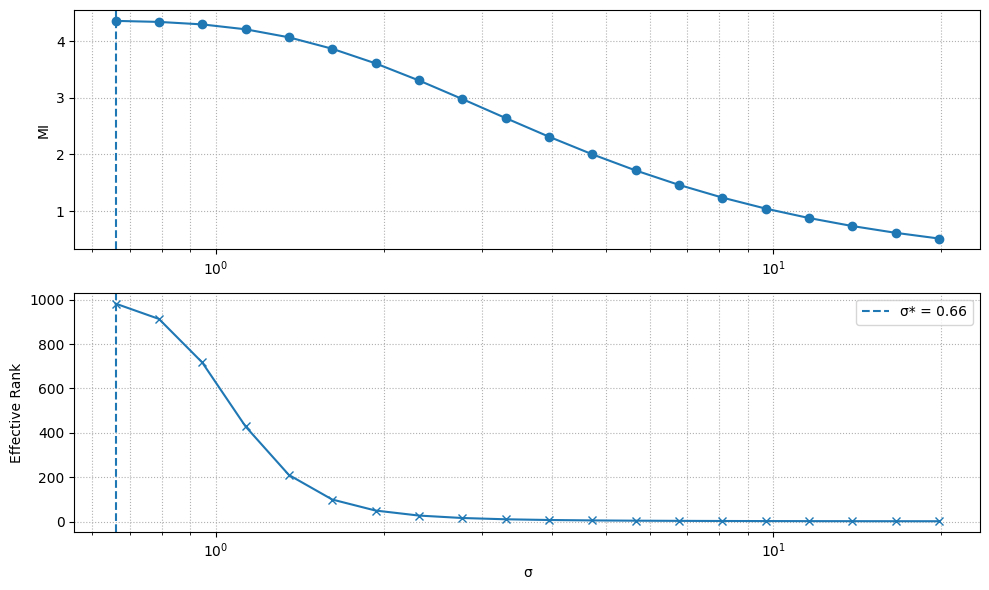

Chosen σ = 0.660436 | MI = 4.35627 | eff_rank = 982.366


In [34]:
    smooth_k = 5
    
    # 5) smooth curves for stability (keeps same length)
    rank_smooth = moving_average(eff_ranks, k=smooth_k)
    MI_smooth   = moving_average(MI_vals,   k=smooth_k)

    # 6) detect elbow in effective rank (2nd derivative of log rank)
    #    use small epsilon to avoid log(0)
    eps = 1e-12
    d1 = np.gradient(np.log(rank_smooth + eps))
    d2 = np.gradient(d1)
    elbow_idx = int(np.argmin(d2))  # most negative curvature

    # 7) pick σ near MI peak but not past the elbow
    mi_peak_idx = int(np.argmax(MI_smooth))
    sigma_opt_idx = min(elbow_idx, mi_peak_idx)
    sigma_opt = float(sigmas[sigma_opt_idx])

#     # 8) final kernel and metrics
#     K_opt = rbf_kernel_from_d2(D2, sigma_opt, normalize=True)
    eff_rank_opt = eff_ranks[sigma_opt_idx]
    mio,Hx, Hxy, kx = calculate_MI(x , y,1.01, sigma_opt,1,False) 
    MI_opt = float(mio)

    if 1:
        # plot MI and effective rank vs sigma (log-x)
        plt.figure(figsize=(10, 6))
        # MI
        plt.subplot(2, 1, 1)
        plt.semilogx(sigmas, MI_vals, marker='o')
        plt.axvline(sigma_opt, linestyle='--')
        plt.ylabel("MI")
        plt.grid(True, which='both', linestyle=':')
        # Effective rank
        plt.subplot(2, 1, 2)
        plt.semilogx(sigmas, eff_ranks, marker='x')
        plt.axvline(sigma_opt, linestyle='--', label=f"σ* = {sigma_opt:.3g}")
        plt.ylabel("Effective Rank")
        plt.xlabel("σ")
        plt.grid(True, which='both', linestyle=':')
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"Chosen σ = {sigma_opt:.6g} | MI = {MI_opt:.6g} | eff_rank = {eff_rank_opt:.6g}")


# ---- example usage (you provide mi_func) ----
# def mi_func(Kx, Ky, alpha):
#     return my_matrix_based_MI(Kx, Ky, alpha)  # <- your implementation
#
# out = auto_sigma_MI_user_py(X, Ky, alpha=1.01, mi_func=mi_func, make_plots=True)
# K_opt, sigma_opt = out["K_opt"], out["sigma_opt"]


In [585]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
from scipy.stats import pearsonr


import numpy as np
from scipy.spatial.distance import cdist
from numpy.linalg import eigh
import matplotlib.pyplot as plt
from sklearn.kernel_approximation import Nystroem  # outside the function, once


def median_heuristic(X):
    """
    Compute sigma using the median heuristic.
    
    Parameters
    ----------
    X : ndarray of shape (n, d)
        Input data, n samples in d dimensions.
    
    Returns
    -------
    sigma : float
        Median heuristic bandwidth parameter.
    """
    X = np.asarray(X)
    n = X.shape[0]

    # Compute pairwise squared distances
    diff = X[:, None, :] - X[None, :, :]
    D2 = np.sum(diff**2, axis=2)

    # Take only the upper triangle (i<j) to avoid duplicates/zeros
    iu = np.triu_indices(n, k=1)
    sigma = np.sqrt(np.median(D2[iu]))
    return sigma

def effective_rank(K):
    """Effective rank = (sum λ)^2 / sum λ^2, using symmetric eigendecomp."""
    # eigh for symmetric matrices; ensure numerical non-negativity
    w = eigh(0.5*(K+K.T), UPLO='L')[0]
    w = np.clip(w, 0.0, None)
    s1 = np.sum(w)
    s2 = np.sum(w**2)
    return (s1**2 / s2) if s2 > 0 else 0.0

def moving_average(x, k=3):
    """Simple centered moving average (odd k). Falls back to same length."""
    if k <= 1 or k % 2 == 0:
        return x
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode='edge')
    kernel = np.ones(k) / k
    return np.convolve(xp, kernel, mode='valid')


def calculate_MI_EM_percell(traces,labels, alpha=1.01, normalize = False,nystrom = False,m_l=500, sigma_value=2.9 ):
    print('running modified code for experiments')
    
    
    variances = np.var(traces, axis=0)

    mask = variances >0.001
    traces = traces[:, mask]
    observations_at_time = traces
    o = traces
    
    sigma_x = sigma_value


    h = np.array(labels, dtype=int)

    x = torch.tensor(o, dtype=torch.float32)
    y = torch.tensor(h, dtype=torch.float32)


#     sigma_x = get_sigma(traces.shape[1],1000,torch.std(x) )
    sigma_y = get_sigma(1,1000,torch.std(y) )
    
    if(nystrom==False):
        mio,Hx, Hxy, kx = calculate_MI(x , y,1.01, sigma_x,sigma_y,False)
        print(kx)
    else:
        mio,Hx, Hxy = calculate_MI_nystrom(x, y, alpha=1.01, sigma_x=sigma_x, m_landmarks=m_l, seed=42, ridge=1e-8, return_intermediates=False)
    
    
    


        
    return np.array(mio),np.array(Hx), np.array(Hxy)



def calculate_gram_mat(x, sigma):
    """calculate gram matrix for variables x
        Args:
        x: random variable with two dimensional (N,d).
        sigma: kernel size of x (Gaussain kernel)
    Returns:
        Gram matrix (N,N)
    """
    x = x.view(x.shape[0],-1)
    instances_norm = torch.sum(x**2,-1).reshape((-1,1))
    dist= -2*torch.mm(x,x.t()) + instances_norm + instances_norm.t()
    return torch.exp(-dist /sigma)
def renyi_entropy(x,sigma,alpha):
    """calculate entropy for single variables x (Eq.(9) in paper)
        Args:
        x: random variable with two dimensional (N,d).
        sigma: kernel size of x (Gaussain kernel)
        alpha:  alpha value of renyi entropy
    Returns:
        renyi alpha entropy of x.
    """
    k = calculate_gram_mat(x,sigma)
    

    
    k = k/torch.trace(k)
    eigv, _ = torch.linalg.eigh(k, UPLO='U')  # or 'L' if you want the lower part
    eigv = torch.abs(eigv)
    eig_pow = eigv**alpha
    entropy = (1/(1-alpha))*torch.log2(torch.sum(eig_pow))
    return entropy, k
def k_cal(x):
    m = x.shape[0]
    classes = torch.unique(x)
    C = len(classes)
    L = torch.zeros((m, C), dtype=torch.float32)
    for c, class_label in enumerate(classes):
        idx = (x == class_label)
        n_c = idx.sum()
        if n_c > 0:
            L[idx, c] = 1.0 / torch.sqrt(n_c.float())
    # Compute Kx = L * L^T
    k = L @ L.T  # Matrix multiplication
    return k
def renyi_entropy_labels(x,sigma,alpha):
    """calculate entropy for single variables x (Eq.(9) in paper)
        Args:
        x: random variable with two dimensional (N,d).
        sigma: kernel size of x (Gaussain kernel)
        alpha:  alpha value of renyi entropy
    Returns:
        renyi alpha entropy of x.
    """
    m = x.shape[0]
    classes = torch.unique(x)
    C = len(classes)
    L = torch.zeros((m, C), dtype=torch.float32)
    for c, class_label in enumerate(classes):
        idx = (x == class_label)
        n_c = idx.sum()
        if n_c > 0:
            L[idx, c] = 1.0 / torch.sqrt(n_c.float())
    # Compute Kx = L * L^T
    k = L @ L.T  # Matrix multiplication
    # Normalize trace to 1
    k = k / torch.trace(k)
    eigv, _ = torch.linalg.eigh(k, UPLO='U')  # or 'L' if you want the lower part
    eigv = torch.abs(eigv)
    eig_pow = eigv**alpha
    entropy = (1/(1-alpha))*torch.log2(torch.sum(eig_pow))
    return entropy
def joint_entropy(x,y,s_x,s_y,alpha):
    """calculate joint entropy for random variable x and y (Eq.(10) in paper)
        Args:
        x: random variable with two dimensional (N,d).
        y: random variable with two dimensional (N,d).
        s_x: kernel size of x
        s_y: kernel size of y
        alpha:  alpha value of renyi entropy
    Returns:
        joint entropy of x and y.
    """
    x = calculate_gram_mat(x,s_x)
    # y = calculate_gram_mat(y,s_y)
    y = k_cal(y)
    k = torch.mul(x,y)
    # eps = 1e-5  # or tune this
    # k += eps * torch.eye(k.shape[0], device=k.device)
    k = k/torch.trace(k)
    eigv, _ = torch.linalg.eigh(k, UPLO='U')  # or 'L' if you want the lower part
    eigv = torch.abs(eigv)
    eig_pow =  eigv**alpha
    entropy = (1/(1-alpha))*torch.log2(torch.sum(eig_pow))
    return entropy
def calculate_MI(x,y,alpha,s_x,s_y,normalize):
    """calculate Mutual information between random variables x and y
    Args:
        x: random variable with two dimensional (N,d).
        y: random variable with two dimensional (N,d).
        s_x: kernel size of x
        s_y: kernel size of y
        normalize: bool True or False, noramlize value between (0,1)
    Returns:
        Mutual information between x and y (scale)
    """
    Hx , kx = renyi_entropy(x,sigma=s_x , alpha=alpha)
    # Hy = renyi_entropy(y,sigma=s_y , alpha=alpha)
    Hy = renyi_entropy_labels(y,sigma=s_y , alpha=alpha)

    Hxy= joint_entropy(x,y,s_x,s_y , alpha=alpha)
    if normalize:
        Ixy = Hx+Hy-Hxy
        Ixy = Ixy/(torch.max(Hx,Hy))
    else:
        Ixy = Hx+Hy-Hxy
    return Ixy,Hx, Hxy, kx



def get_sigma(dim, n, std):
    h = (0.9*std)/(n**1.5)
    return h*n**(-1/(4+dim))





In [181]:
variances = np.var(traces, axis=0)

mask = variances >0.00001
traces = traces[:, mask]
observations_at_time = traces
o = traces

#find the range of the sigma

X = traces
m = X.shape[0]

# 1) pairwise squared distances
D2 = cdist(X, X, metric='euclidean')**2

# 2) median heuristic for base sigma
upper = D2[np.triu_indices(m, k=1)]
sigma0 = np.sqrt(np.median(upper)) if upper.size > 0 else 1.0

# 3) sweep σ

span_low = 1/3
span_high = 10
n_sigma = 20


sigmas = np.logspace(np.log10(sigma0*span_low),
                     np.log10(sigma0*span_high),
                     num=n_sigma)

# eff_ranks = np.zeros_like(sigmas)
# MI_vals   = np.zeros_like(sigmas)

eff_ranks = []
MI_vals = []
valid_sigmas =[]


# for i in range(n_sigma):


#     sigma_x = sigmas[i]


#     h = np.array(labels, dtype=int)

#     x = torch.tensor(o, dtype=torch.float32)
#     y = torch.tensor(h, dtype=torch.float32)




#     mio,Hx, Hxy, kx = calculate_MI(x , y,1.01, sigma_x,1,False)   
#     Hy = Hxy + mio -Hx
#     if (Hxy > max(Hx,Hy) and mio < min(Hx,Hy) and mio>0 ):
#         eff_ranks.append(effective_rank(kx))
#         MI_vals.append(mio)
#         valid_sigmas.append(sigma_x)
        
    
# eff_ranks = np.array(eff_ranks)
# MI_vals = np.array(MI_vals)
# sigmas = np.array(valid_sigmas)
# smooth_k = 5

# rank_smooth = moving_average(eff_ranks, k=smooth_k)
# MI_smooth   = moving_average(MI_vals,   k=smooth_k)
# eps = 1e-12
# d1 = np.gradient(np.log(rank_smooth + eps))
# d2 = np.gradient(d1)
# elbow_idx = int(np.argmin(d2))

# mi_peak_idx = int(np.argmax(MI_smooth))
# sigma_opt_idx = min(elbow_idx, mi_peak_idx)
# sigma_opt = float(sigmas[sigma_opt_idx])

# MI_vals[sigma_opt_idx]

C:\Users\Riscure\AppData\Local\Temp\ipykernel_297480\721206691.py:27: RuntimeWarning: divide by zero encountered in log10
  sigmas = np.logspace(np.log10(sigma0*span_low),
C:\Users\Riscure\AppData\Local\Temp\ipykernel_297480\721206691.py:28: RuntimeWarning: divide by zero encountered in log10
  np.log10(sigma0*span_high),


In [189]:
variances = np.var(traces, axis=0)

In [386]:
## Hx in csv

In [584]:


import torch
import torch.nn as nn
import torch.nn.functional as F


def calculate_gram_mat(x, sigma):
    """calculate gram matrix for variables x
        Args:
        x: random variable with two dimensional (N,d).
        sigma: kernel size of x (Gaussain kernel)
    Returns:
        Gram matrix (N,N)
    """
    x = x.view(x.shape[0],-1)
    instances_norm = torch.sum(x**2,-1).reshape((-1,1))
    dist= -2*torch.mm(x,x.t()) + instances_norm + instances_norm.t()
    return torch.exp(-dist /sigma)

def renyi_entropy(x,sigma,alpha):
    
    """calculate entropy for single variables x (Eq.(9) in paper)
        Args:
        x: random variable with two dimensional (N,d).
        sigma: kernel size of x (Gaussain kernel)
        alpha:  alpha value of renyi entropy
    Returns:
        renyi alpha entropy of x. 
    """
    
    k = calculate_gram_mat(x,sigma)
    eps = 1e-5  # or tune this
    k += eps * torch.eye(k.shape[0], device=k.device)

    


    k = k/torch.trace(k) 
    eigv, _ = torch.linalg.eigh(k, UPLO='U')  # or 'L' if you want the lower part

    eigv = torch.abs(eigv)  
    eig_pow = eigv**alpha
    entropy = (1/(1-alpha))*torch.log2(torch.sum(eig_pow))
    return entropy


def joint_entropy(x,y,s_x,s_y,alpha):
    
    """calculate joint entropy for random variable x and y (Eq.(10) in paper)
        Args:
        x: random variable with two dimensional (N,d).
        y: random variable with two dimensional (N,d).
        s_x: kernel size of x
        s_y: kernel size of y
        alpha:  alpha value of renyi entropy
    Returns:
        joint entropy of x and y. 
    """
    
    x = calculate_gram_mat(x,s_x)
    y = calculate_gram_mat(y,s_y)
    k = torch.mul(x,y)
    
    eps = 1e-5  # or tune this
    k += eps * torch.eye(k.shape[0], device=k.device)

    

    k = k/torch.trace(k)
    eigv, _ = torch.linalg.eigh(k, UPLO='U')  # or 'L' if you want the lower part

    eigv = torch.abs(eigv)
    eig_pow =  eigv**alpha
    entropy = (1/(1-alpha))*torch.log2(torch.sum(eig_pow))
    return entropy

def calculate_MI(x,y,alpha,s_x,s_y,normalize):
    
    """calculate Mutual information between random variables x and y

    Args:
        x: random variable with two dimensional (N,d).
        y: random variable with two dimensional (N,d).
        s_x: kernel size of x
        s_y: kernel size of y
        normalize: bool True or False, noramlize value between (0,1)
    Returns:
        Mutual information between x and y (scale)

    """
    Hx = renyi_entropy(x,sigma=s_x , alpha=alpha)
    Hy = renyi_entropy(y,sigma=s_y , alpha=alpha)
    Hxy = joint_entropy(x,y,s_x,s_y , alpha=alpha)
    if normalize:
        Ixy = Hx+Hy-Hxy
        Ixy = Ixy/(torch.max(Hx,Hy))
    else:
        Ixy = Hx+Hy-Hxy
    return Ixy

def get_sigma(dim, n, std):
    h = (0.9*std)/(n**1.5)
    return h*n**(-1/(4+dim))


def MBRE(X , Y, sig):
    observations_at_time = X


        
    x = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(np.array(Y, dtype=int), dtype=torch.float32)



    # sigma_x = get_sigma(1,100,torch.std(x) )
    # sigma_y = get_sigma(1,000,torch.std(y) )
    # mio = calculate_MI(x , y,1.01, 0.6,1,False)     # alpha was 0.6 for the first dataset impl_1
    mio = calculate_MI(x , y,1.01,sig,1,False)
    
    return mio



def HXX(X , sig , alpha):
    observations_at_time = X


        
    x = torch.tensor(X, dtype=torch.float32)
    
    return renyi_entropy(x,sigma=sig , alpha=alpha)

In [403]:
keys = ptc_5k.get_dataset("keys").read_data(0, num)
plaintexts = ptc_5k.get_dataset("plaintexts").read_data(0, num)
labels = hd_cpa_last_round(plaintext=plaintexts,num_traces=num,c=c,target_byte=13,r1=6,r2=7)
H_X_total = np.zeros((11,11,450))

grid_size = (11,11)
n_rot=2 #for uc change to 3


for i in range(11):
    for j in range(11):
        i_,j_ = reverse_coords_ccw(i,j,grid_size,n_rot)
        num = 200
        
        traces = impl_d_t.get_dataset(f"random_{i_}_{j_}").read_data(0, 200)
            
        for counter in range(450):
                H_X_total[i,j,counter] = HXX(traces , 2.4 , 1.01)
                
                
            
            
        






       

In [407]:
import numpy as np
from scipy.io import savemat

In [639]:
np.save('uc_labels.npy', labels)

In [614]:
savemat("HXcell_impl_3_nyst.mat", {"HXcell_impl_3_nyst": MI})

In [ ]:
MI,snr_r,fig = plot_MI_heatmap(impl_3_t,ptc_5k,1000,grid_size =11,MI_type="BYTE",target_byte=10,multiplier=1,num_columns=440,rotation_n=3,nystrom=False,m_l=1000,r1=6,r2=7 )
def plot_MI_heatmap(test, pt_exp, num,rotation_n = 0, target_byte=0, grid_size=5, MI_type="BYTE",num_columns = 100, sigma_traces=1, sigma_label=1,alpha =1.01, normalize = False,multiplier=100,r1=6,r2=7,nystrom=False,m_l=500,fntsz=20):
uc_t

In [633]:
pt_exp = ptc_5k
import numpy as np
num = 1000
keys = pt_exp.get_dataset("keys").read_data(0, num)
plaintexts = pt_exp.get_dataset("plaintexts").read_data(0, num)
c = AES(keys[0])
print("AES model generated")

labels = sbox_snr(num_traces=num, plaintexts=plaintexts, subkey_guess=keys, target_byte=target_byte)

grid_size = 11
uc_traces = np.zeros((11,11,1000,450))


for i in trange(grid_size):
    for j in trange(grid_size):

        traces = uc_t.get_dataset(f"random_{i}_{j}").read_data(0, num)
        uc_traces[i,j]= traces[:1000, 5613:6063]




AES model generated


100%|██████████| 11/11 [01:33<00:00,  8.46s/it]
